# Εργαστήριο 1: Ανάπτυξη Συστήματος Υποστήριξης Αποφάσεων (DSS) με την Python
## Το Σενάριο (Business Problem)

Είστε ο Tactical Manager μιας μεγάλης αλυσίδας ξενοδοχείων. Το πρόβλημα που καλείστε να λύσετε είναι το υψηλό ποσοστό **Ακυρώσεων Κρατήσεων (Cancellations)**, το οποίο προκαλεί τεράστια απώλεια εσόδων.

**Dataset:** [Hotel Booking Demand — Kaggle (Jesse Mostipak)](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

> Τα δεδομένα περιέχουν **119.390 κρατήσεις** από δύο πορτογαλικά ξενοδοχεία (City Hotel & Resort Hotel) για την περίοδο 2015–2017. Κάθε γραμμή αντιπροσωπεύει μία κράτηση με 32 χαρακτηριστικά: από τον τύπο δωματίου και τον αριθμό επισκεπτών, μέχρι τον χρόνο προ-κράτησης (`lead_time`) και αν τελικά ακυρώθηκε (`is_canceled`).

Στόχος αυτού του εργαστηρίου είναι να εφαρμόσουμε το μοντέλο του **Herbert Simon**:
1. **Intelligence:** Θα φορτώσουμε και θα καθαρίσουμε τα ιστορικά δεδομένα (Data Cleaning).
2. **Design:** Θα αναλύσουμε τα πρότυπα συμπεριφοράς των πελατών (Correlation, What-If).
3. **Choice:** Θα προτείνουμε συγκεκριμένες πολιτικές (πολυπλοκότητα εγγυήσεων, όρια χρόνου) για να μειώσουμε τις ακυρώσεις.

### Τα Εργαλεία μας (Python Libraries)
Σε ένα Σύστημα Υποστήριξης Αποφάσεων (DSS), χρειαζόμαστε εργαλεία για να μετατρέψουμε τα ακατέργαστα δεδομένα σε χρήσιμη πληροφορία. Στην Python, αυτό γίνεται κυρίως με 5 βιβλιοθήκες:

1. **[Pandas](https://pandas.pydata.org/docs/) (`pd`)**: Είναι το "έξυπνο Excel" της Python. Μας επιτρέπει να φορτώνουμε τεράστια σύνολα δεδομένων (DataFrames), να τα φιλτράρουμε, να τα ομαδοποιούμε και να τα μετασχηματίζουμε με λίγες γραμμές κώδικα. → [DataFrame API](https://pandas.pydata.org/docs/reference/frame.html) · [groupby](https://pandas.pydata.org/docs/reference/groupby.html) · [pd.cut / pd.qcut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html)
2. **[Matplotlib](https://matplotlib.org/stable/index.html) (`plt`)**: Η βασική βιβλιοθήκη για τη δημιουργία γραφημάτων. Μας δίνει τον απόλυτο έλεγχο πάνω σε κάθε στοιχείο (άξονες, τίτλοι, χρώματα). → [pyplot API](https://matplotlib.org/stable/api/pyplot_summary.html) · [Gallery παραδειγμάτων](https://matplotlib.org/stable/gallery/index.html)
3. **[Seaborn](https://seaborn.pydata.org/) (`sns`)**: Χτίζεται πάνω στην Matplotlib, αλλά έχει δημιουργηθεί ειδικά για στατιστική ανάλυση. Με τη Seaborn μπορούμε να φτιάξουμε εντυπωσιακά και πολύπλοκα γραφήματα (όπως Heatmaps) πολύ εύκολα, βοηθώντας τον Tactical Manager να δει αμέσως τα μοτίβα. → [API Reference](https://seaborn.pydata.org/api.html) · [heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html) · [barplot](https://seaborn.pydata.org/generated/seaborn.barplot.html)
4. **[NumPy](https://numpy.org/doc/stable/) (`np`)**: Η θεμελιώδης βιβλιοθήκη για αριθμητικούς υπολογισμούς. Χρησιμοποιείται κυρίως για `np.number` (τύπος δεδομένων), `np.linspace` (ισαπέχοντα σημεία) και πράξεις πινάκων. → [Array operations](https://numpy.org/doc/stable/reference/routines.array-manipulation.html)
5. **[SciPy](https://docs.scipy.org/doc/scipy/) (`scipy`)**: Βιβλιοθήκη επιστημονικών υπολογισμών που επεκτείνει το NumPy. Στο notebook χρησιμοποιείται για ανίχνευση κορυφών (`scipy.signal.find_peaks`) στα ιστογράμματα lead_time. → [signal.find_peaks](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html) · [Statistical functions](https://docs.scipy.org/doc/scipy/reference/stats.html)


## Βασικές Έννοιες Στατιστικής για αυτό το Notebook

Πριν ξεκινήσουμε την ανάλυση, παρουσιάζουμε τις στατιστικές έννοιες που χρησιμοποιούνται σε αυτό το εργαστήριο. Κάθε έννοια αντιστοιχεί σε συγκεκριμένο εργαλείο ή ανάλυση που θα συναντήσουμε παρακάτω.

---

### 1. Μέτρα Κεντρικής Τάσης

| Έννοια | Ορισμός | Pandas |
|---|---|---|
| **Μέσος Όρος (Mean)** | $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — ο **αριθμητικός** μέσος (υπάρχουν και γεωμετρικός, αρμονικός κ.ά., αλλά στην ανάλυση δεδομένων ο «μέσος» εννοεί πάντα αυτόν) | `.mean()` |
| **Διάμεσος (Median)** | Η μεσαία τιμή όταν τα δεδομένα ταξινομηθούν | `.median()` |
| **Επικρατούσα τιμή (Mode)** | Η πιο συχνή τιμή σε ένα δείγμα | `.mode()` |

> **Σημαντικό:** Στο notebook χρησιμοποιούμε το `mean()` σε binary στήλες (0/1) για να υπολογίσουμε **ποσοστό**: αν 400 από 1.000 κρατήσεις έχουν `is_canceled=1`, τότε `mean() = 0.40` → **40% ακυρώσεις**.

---

### 2. Μέτρα Διασποράς

| Έννοια | Ορισμός | Ερμηνεία |
|---|---|---|
| **Τυπική Απόκλιση (Std Dev)** | $s = \sqrt{\frac{\sum(x_i - \bar{x})^2}{n-1}}$ | Πόσο "απλώνονται" οι τιμές γύρω από τον μέσο |
| **Διακύμανση (Variance)** | $s^2 = \frac{\sum(x_i - \bar{x})^2}{n-1}$ | Το τετράγωνο της τυπικής απόκλισης |
| **Εύρος (Range)** | $\max - \min$ | Η διαφορά μεταξύ μέγιστης και ελάχιστης τιμής |

> ⚠️ **Δείγμα vs Πληθυσμός:** Ο τύπος χρησιμοποιεί $n-1$ στον παρονομαστή (**διόρθωση Bessel**) γιατί δουλεύουμε με **δείγμα** (sample) — μια υποσύνολο του πληθυσμού. Το $n-1$ αντισταθμίζει τη συστηματική υποεκτίμηση της πραγματικής διακύμανσης. Αν είχαμε ολόκληρο τον **πληθυσμό**, θα χρησιμοποιούσαμε $n$ (και θα γράφαμε $\sigma$ αντί για $s$). Το pandas `.std()` χρησιμοποιεί $n-1$ ως προεπιλογή (`ddof=1`) — αν θέλεις τον πληθυσμιακό τύπο: `.std(ddof=0)`.

> Στο `df.describe()` βλέπουμε αυτά αυτόματα για κάθε αριθμητική στήλη.

> 📊 **Δείτε το παρακάτω κελί** για οπτική επεξήγηση της τυπικής απόκλισης με παράδειγμα.


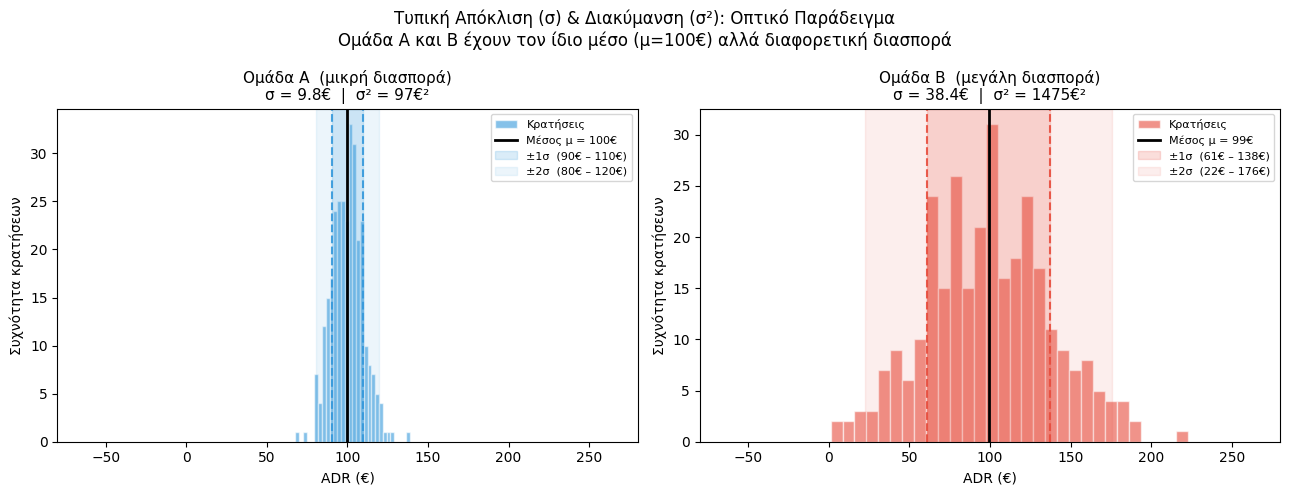

Ομάδα Α — μέσος: 99.9€  |  σ = 9.8€  |  σ² = 97€²
Ομάδα Β — μέσος: 99.1€  |  σ = 38.4€  |  σ² = 1475€²

Και οι δύο ομάδες έχουν σχεδόν ίδιο μέσο (~100€).
Η διαφορά φαίνεται μόνο στην τυπική απόκλιση — άρα ο μέσος ΜΟΝΟΣ δεν αρκεί!


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Δύο ομάδες με ίδιο μέσο αλλά διαφορετική διασπορά ---
np.random.seed(42)
μ = 100   # Κοινός μέσος (ADR σε €)
group_A = np.random.normal(loc=μ, scale=10, size=300)   # σ=10: συμπυκνωμένη
group_B = np.random.normal(loc=μ, scale=40, size=300)   # σ=40: διεσπαρμένη

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Τυπική Απόκλιση (σ) & Διακύμανση (σ²): Οπτικό Παράδειγμα\n'
             'Ομάδα Α και Β έχουν τον ίδιο μέσο (μ=100€) αλλά διαφορετική διασπορά',
             fontsize=12)

for ax, data, label, color, σ_label in zip(
    axes,
    [group_A, group_B],
    ['Ομάδα Α  (μικρή διασπορά)', 'Ομάδα Β  (μεγάλη διασπορά)'],
    ['#3498db', '#e74c3c'],
    ['σ = 10€', 'σ = 40€']
):
    μ_val = data.mean()
    σ_val = data.std()

    # Ιστόγραμμα
    ax.hist(data, bins=30, color=color, alpha=0.6, edgecolor='white', label='Κρατήσεις')

    # Γραμμή μέσου
    ax.axvline(μ_val, color='black', linewidth=2, linestyle='-',  label=f'Μέσος μ = {μ_val:.0f}€')

    # Ζώνες ±1σ, ±2σ
    for n, alpha in [(1, 0.18), (2, 0.09)]:
        ax.axvspan(μ_val - n*σ_val, μ_val + n*σ_val,
                   color=color, alpha=alpha,
                   label=f'±{n}σ  ({μ_val - n*σ_val:.0f}€ – {μ_val + n*σ_val:.0f}€)')

    ax.axvline(μ_val - σ_val, color=color, linewidth=1.5, linestyle='--', alpha=0.9)
    ax.axvline(μ_val + σ_val, color=color, linewidth=1.5, linestyle='--', alpha=0.9)

    ax.set_title(f'{label}\nσ = {σ_val:.1f}€  |  σ² = {σ_val**2:.0f}€²', fontsize=11)
    ax.set_xlabel('ADR (€)')
    ax.set_ylabel('Συχνότητα κρατήσεων')
    ax.legend(fontsize=8)
    ax.set_xlim(-80, 280)

plt.tight_layout()
plt.show()

print(f"Ομάδα Α — μέσος: {group_A.mean():.1f}€  |  σ = {group_A.std():.1f}€  |  σ² = {group_A.var():.0f}€²")
print(f"Ομάδα Β — μέσος: {group_B.mean():.1f}€  |  σ = {group_B.std():.1f}€  |  σ² = {group_B.var():.0f}€²")
print(f"\nΚαι οι δύο ομάδες έχουν σχεδόν ίδιο μέσο (~100€).")
print(f"Η διαφορά φαίνεται μόνο στην τυπική απόκλιση — άρα ο μέσος ΜΟΝΟΣ δεν αρκεί!")


#### 📐 Ανάγνωση του Διαγράμματος: Τι Σημαίνουν οι Ζώνες ±1σ και ±2σ;

> **Ερμηνεία:** Η σκιαζόμενη ζώνη ±1σ περιέχει ~68% των τιμών, το ±2σ περιέχει ~95%.
> Ομάδα Α: οι τιμές ADR είναι συγκεντρωμένες κοντά στα 100€ — προβλέψιμη τιμολόγηση.
> Ομάδα Β: οι τιμές ADR «απλώνονται» πολύ — υψηλή αβεβαιότητα τιμής → δυσκολία στρατηγικής.

Στο παραπάνω ιστόγραμμα εμφανίζονται **δύο σκιαζόμενες ζώνες** γύρω από τον μέσο όρο μ:

| Ζώνη | Εκτείνεται από … έως … | Περιέχει | Στο γράφημα |
|---|---|---|---|
| **±1σ** (σκούρα σκίαση) | μ − σ έως μ + σ | **~68%** των τιμών | Στενότερο πλαίσιο |
| **±2σ** (ανοιχτή σκίαση) | μ − 2σ έως μ + 2σ | **~95%** των τιμών | Φαρδύτερο πλαίσιο |

Αυτές οι αναλογίες ονομάζονται **Εμπειρικός Κανόνας** (ή κανόνας 68-95-99.7) και ισχύουν για κατανομές που πλησιάζουν τη **Κανονική Κατανομή (Normal / Gaussian)**:

$$
P(\mu - k\sigma \leq x \leq \mu + k\sigma) \approx
\begin{cases}
68\% & k = 1 \\
95\% & k = 2 \\
99.7\% & k = 3
\end{cases}
$$

**Πώς το διαβάζουμε στο παράδειγμα του ADR:**

- **Ομάδα Α (σ = 10€):** η ζώνη ±1σ καλύπτει 90€–110€ → σχεδόν όλες οι κρατήσεις τιμολογούνται κοντά στα 100€. Ο ξενοδόχος έχει **υψηλή προβλεψιμότητα εσόδων**.
- **Ομάδα Β (σ = 40€):** η ζώνη ±1σ καλύπτει 60€–140€ → υπάρχουν κρατήσεις που κυμαίνονται από πολύ φθηνές έως πολύ ακριβές. Η **αβεβαιότητα τιμολόγησης είναι τετραπλάσια**.

> ⚠️ **Προσοχή:** Ο Εμπειρικός Κανόνας ισχύει επακριβώς **μόνο για κανονική κατανομή**. Σε δεδομένα με ασυμμετρία (π.χ. lead time, τιμές ADR με outliers) τα ποσοστά μπορεί να αποκλίνουν.

> **Πρακτικός Κανόνας:** Αν βλέπεις μια ζώνη ±1σ **πολύ στενή** → τα δεδομένα είναι ομαλά και ο μέσος αντιπροσωπεύει καλά το σύνολο. Αν η ζώνη είναι **πολύ πλατιά** → ο μέσος είναι παραπλανητικός και χρειάζεται να κοιτάξεις και τη διασπορά.

---

### 3. Κατανομή & Ιστόγραμμα (Distribution & Histogram)

Η **κατανομή** μιας μεταβλητής δείχνει πόσο συχνά εμφανίζεται κάθε τιμή. Το **ιστόγραμμα** (histogram) είναι η οπτική αναπαράσταση αυτής της κατανομής:
- Ο οριζόντιος άξονας = τιμές (π.χ. μέρες `lead_time`)
- Ο κατακόρυφος άξονας = συχνότητα εμφάνισης (πόσες κρατήσεις)

Κοινές μορφές κατανομής:
- **Κανονική (Bell curve):** Συμμετρική, οι περισσότερες τιμές κοντά στον μέσο
- **Ασύμμετρη δεξιά (Right-skewed):** Λίγες πολύ μεγάλες τιμές τραβούν τον μέσο δεξιά — τυπικό στο `lead_time` και το `adr`

---

### 4. Ομαδοποίηση / Discretization (Binning)

Μετατροπή συνεχούς αριθμητικής μεταβλητής σε **κατηγορίες** (bins):

| Μέθοδος | Λογική | Πότε |
|---|---|---|
| **`pd.cut()`** | Ίσα **διαστήματα τιμών** (π.χ. 0–30, 30–90 μέρες) | Όταν τα όρια έχουν επιχειρηματικό νόημα |
| **`pd.qcut()`** | Ίσα **πλήθη εγγραφών** (κάθε bin = 20% του δείγματος) | Όταν θέλουμε ισορροπημένες ομάδες για σύγκριση |

---

### 5. Συσχέτιση Pearson (Pearson Correlation)

Ο **Συντελεστής Συσχέτισης Pearson** $r$ μετράει τη **γραμμική σχέση** μεταξύ δύο μεταβλητών $x$ και $y$:

$$r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}} \quad \in [-1, +1]$$

| Τιμή $r$ | Ερμηνεία |
|---|---|
| $r > 0$ | Θετική συσχέτιση — όταν αυξάνεται το $x$, αυξάνεται και το $y$ |
| $r < 0$ | Αρνητική συσχέτιση — όταν αυξάνεται το $x$, μειώνεται το $y$ |
| $r \approx 0$ | Καμία γραμμική σχέση |
| $\|r\| < 0.3$ | Ασθενής · $0.3 \leq \|r\| < 0.7$: Μέτρια · $\|r\| \geq 0.7$: Ισχυρή |

> ⚠️ **Συσχέτιση ≠ Αιτιότητα.** Το ότι δύο μεταβλητές συσχετίζονται δεν σημαίνει ότι η μία *προκαλεί* την άλλη.

---

### 6. Κινητός Μέσος Όρος (Rolling Average)

Χρησιμοποιείται για **εξομάλυνση θορύβου** (noise):

$$\bar{x}_t^{(w)} = \frac{1}{w} \sum_{i=t-w+1}^{t} x_i$$

Με `window=10` υπολογίζεται ο μέσος των 10 προηγούμενων τιμών — αποκαλύπτει την πραγματική **τάση** αντί για τυχαίες διακυμάνσεις. Χρησιμοποιείται στη Goal Seek ανάλυση.

> 💡 **Στην Pandas:** `df['column'].rolling(window=10).mean()`

> 📌 **Οδηγός Αναφοράς:** Επιστρέψτε σε αυτό το κελί (και στο επόμενο για ενότητες 7–10) κάθε φορά που συναντάτε μια στατιστική έννοια στον κώδικα που ακολουθεί.


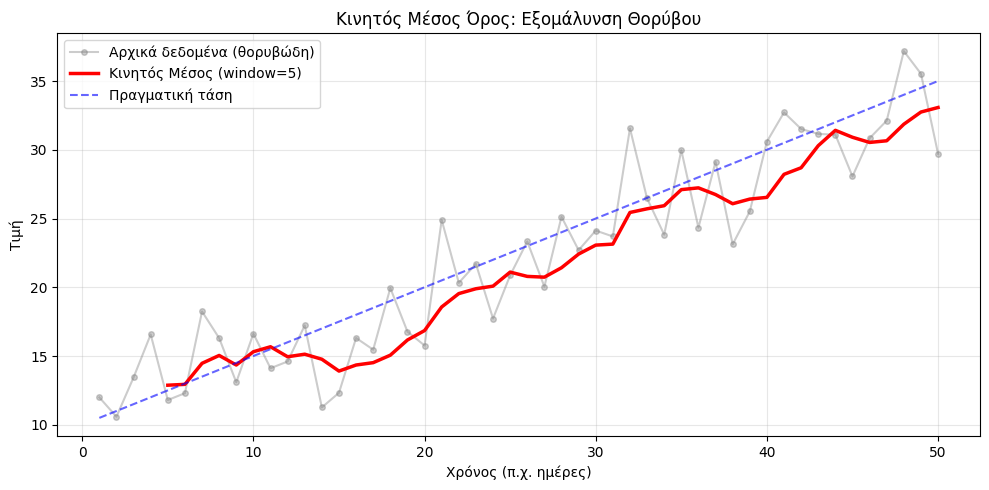

✓ Ο κινητός μέσος όρος (κόκκινη γραμμή) ακολουθεί την τάση χωρίς τον θόρυβο


In [2]:
# Παράδειγμα Κινητού Μέσου Όρου
import numpy as np
import matplotlib.pyplot as plt

# Δημιουργία δεδομένων με θόρυβο
np.random.seed(42)
x = np.arange(1, 51)
true_trend = 0.5 * x + 10  # Γραμμική τάση
noise = np.random.normal(0, 3, 50)  # Τυχαίος θόρυβος
noisy_data = true_trend + noise

# Υπολογισμός κινητού μέσου (window=5)
rolling_avg = np.convolve(noisy_data, np.ones(5)/5, mode='valid')
x_rolling = x[4:]  # Ο κινητός μέσος ξεκινά από τη θέση 5

# Γράφημα
plt.figure(figsize=(10, 5))
plt.plot(x, noisy_data, 'o-', alpha=0.4, label='Αρχικά δεδομένα (θορυβώδη)', color='gray', markersize=4)
plt.plot(x_rolling, rolling_avg, '-', linewidth=2.5, label='Κινητός Μέσος (window=5)', color='red')
plt.plot(x, true_trend, '--', alpha=0.6, label='Πραγματική τάση', color='blue')

plt.xlabel('Χρόνος (π.χ. ημέρες)')
plt.ylabel('Τιμή')
plt.title('Κινητός Μέσος Όρος: Εξομάλυνση Θορύβου')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Ο κινητός μέσος όρος (κόκκινη γραμμή) ακολουθεί την τάση χωρίς τον θόρυβο")

## Βασικές Έννοιες Στατιστικής (συνέχεια: ενότητες 7–10)

---

### 7. Εποχικότητα (Seasonality)

Η **εποχικότητα** είναι η τάση μιας μεταβλητής να ακολουθεί **επαναλαμβανόμενα πρότυπα** σε συγκεκριμένες χρονικές περιόδους (εβδομάδες, μήνες, εποχές). Π.χ. αν κάθε καλοκαίρι οι ακυρώσεις ανεβαίνουν, αυτό είναι εποχικό πρότυπο — και άρα **προβλέψιμο**.

---

### 8. Ακραίες Τιμές (Outliers)

Τιμές που βρίσκονται **πολύ μακριά** από το σύνολο των δεδομένων. Μπορεί να είναι:
- **Σφάλματα καταγραφής** (π.χ. `adr = -10€`) → πρέπει να αφαιρεθούν
- **Πραγματικά ακραία γεγονότα** (π.χ. `adr = 5.400€` για σουίτα) → εξαρτάται από τη χρήση

Ανίχνευση με τον κανόνα **IQR** (Interquartile Range):

**Βήμα 1 — Ορισμός τεταρτημορίων:**

Χωρίζουμε τα ταξινομημένα δεδομένα σε 4 ίσα τμήματα:

| Σημείο | Ορισμός | Παράδειγμα (ADR) |
|---|---|---|
| **Q1** (25ο εκατοστημόριο) | Κάτω από αυτό βρίσκεται το 25% των τιμών | 69€ |
| **Q2** (50ο — Διάμεσος) | Κάτω από αυτό βρίσκεται το 50% των τιμών | 95€ |
| **Q3** (75ο εκατοστημόριο) | Κάτω από αυτό βρίσκεται το 75% των τιμών | 126€ |
| **IQR = Q3 − Q1** | Το εύρος του **μεσαίου 50%** των τιμών | 57€ |

```
|----25%----[========= IQR (μεσαίο 50%) =========]----25%----|
min        Q1                               Q3              max
```

**Βήμα 2 — Όρια outliers (Tukey's Fences):**

$$\text{Κάτω όριο} = Q_1 - 1.5 \cdot IQR \qquad \text{Άνω όριο} = Q_3 + 1.5 \cdot IQR$$

$$\text{Outlier αν } x < Q_1 - 1.5 \cdot IQR \quad \text{ή} \quad x > Q_3 + 1.5 \cdot IQR$$

Το **1.5** δεν είναι τυχαίο — πρότεινε ο στατιστικολόγος **John Tukey (1977)** ως εμπειρικό κατώφλι που, για κανονική κατανομή, αντιστοιχεί σε τιμές πέρα από **±2.7σ** (≈ 0.7% του δείγματος).

> 💡 **Στην Pandas:**
> ```python
> Q1 = df['adr'].quantile(0.25)
> Q3 = df['adr'].quantile(0.75)
> IQR = Q3 - Q1
> outliers = df[(df['adr'] < Q1 - 1.5*IQR) | (df['adr'] > Q3 + 1.5*IQR)]
> ```

> 📊 **Σύνδεση με Boxplot:** Τα "whiskers" (μουστάκια) στο boxplot είναι ακριβώς τα όρια Q1−1.5·IQR και Q3+1.5·IQR. Κάθε τελεία έξω από αυτά είναι outlier.

---

### 9. Παράδοξο του Simpson (Simpson's Paradox)

Φαινόμενο όπου μια τάση που φαίνεται σε **συνολικά δεδομένα** εξαφανίζεται ή αντιστρέφεται όταν τα δεδομένα **χωριστούν σε υπο-ομάδες**.

> *Παράδειγμα στο notebook:* Το `Non Refund` deposit φαίνεται να έχει ~99% ακυρώσεις στο σύνολο — αλλά αυτό οφείλεται στο ότι χρησιμοποιείται κυρίως από OTAs (κερδοσκοπικές κρατήσεις), όχι από τελικούς καταναλωτές. Αν κοιτάξουμε **μόνο Direct πελάτες**, η εικόνα αντιστρέφεται.

---

### 10. One-Hot Encoding (OHE)

Τεχνική μετατροπής **κατηγορικών μεταβλητών** (κείμενο) σε **αριθμητικές binary στήλες** (0/1), ώστε να μπορούν να χρησιμοποιηθούν σε μαθηματικούς υπολογισμούς (π.χ. συσχέτιση).

**Παράδειγμα με 3 κατηγορίες (Non Refund, Refundable, No Deposit):**

```
Αρχική τιμή                  →  Μετά το One-Hot Encoding (χωρίς drop_first)
----------------------------    ------------------------------------------------
deposit_type = "Non Refund"  →  Non_Refund=1, Refundable=0, No_Deposit=0
deposit_type = "Refundable"  →  Non_Refund=0, Refundable=1, No_Deposit=0
deposit_type = "No Deposit"  →  Non_Refund=0, Refundable=0, No_Deposit=1
```

**Με `drop_first=True`** (αφαιρεί την 1η στήλη):
```
deposit_type = "Non Refund"  →  Refundable=0, No_Deposit=0  (συμπέρασμα: Non Refund)
deposit_type = "Refundable"  →  Refundable=1, No_Deposit=0
deposit_type = "No Deposit"  →  Refundable=0, No_Deposit=1
```

Το `drop_first=True` αφαιρεί μία στήλη ανά μεταβλητή για να αποφευχθεί η **πολυσυγγραμμικότητα** (multicollinearity) — όταν όλες οι στήλες είναι 0, συμπεραίνουμε την πρώτη κατηγορία.

---

> 📌 **Οδηγός Αναφοράς:** Επιστρέψτε σε αυτά τα κελιά κάθε φορά που συναντάτε μια στατιστική έννοια στον κώδικα που ακολουθεί.


---

# 🔍 INTELLIGENCE PHASE: Κατανόηση του Προβλήματος

Στη φάση **Intelligence** του μοντέλου Simon, ο στόχος μας είναι να **κατανοήσουμε το πρόβλημα** μέσα από τα δεδομένα. Αυτό περιλαμβάνει:

1. **Φόρτωση δεδομένων** (Data Loading)
2. **Έλεγχος δεδομένων** (Data Inspection) - Τι έχουμε;
3. **Καθαρισμός δεδομένων** (Data Cleaning) - Διόρθωση προβλημάτων
4. **Περιγραφική στατιστική** (Descriptive Statistics) - Πρώτες παρατηρήσεις

Ας ξεκινήσουμε!

---

## 1. Φόρτωση Δεδομένων (Data Loading)

Πρώτα φορτώνουμε τις βιβλιοθήκες που θα χρησιμοποιήσουμε και το dataset:


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Φόρτωση του dataset (Hotel Booking Demand από το Kaggle)
df = pd.read_csv('hotel_bookings.csv')

print("✓ Dataset φορτώθηκε επιτυχώς!")
print(f"  Μέγεθος: {df.shape[0]:,} κρατήσεις × {df.shape[1]} χαρακτηριστικά")

✓ Dataset φορτώθηκε επιτυχώς!
  Μέγεθος: 119,390 κρατήσεις × 32 χαρακτηριστικά


---

## 2. Έλεγχος των Δεδομένων (Data Inspection)

Πριν ξεκινήσουμε την ανάλυση, πρέπει να "γνωρίσουμε" τα δεδομένα μας. Στη Λήψη Αποφάσεων δεν μπορούμε να προχωρήσουμε αν δεν κατανοήσουμε το περιβάλλον του προβλήματος (Intelligence Phase). 

Οι βασικές ερωτήσεις που κάνουμε στα δεδομένα μας μέσω της Pandas είναι:
* `df.shape`: Πόσες παραγγελίες/κρατήσεις (γραμμές) και πόσα χαρακτηριστικά (στήλες) έχουμε;
* `df.info()`: Τι τύπου είναι τα δεδομένα μας; Έχουμε κείμενο, αριθμούς ή ημερομηνίες; Λείπουν τιμές;
* `df.describe()`: Ποια είναι η στατιστική εικόνα; Ποιος είναι ο μέσος όρος, η μέγιστη και η ελάχιστη τιμή σε κάθε στήλη; 
* `df.head()`: Πώς μοιάζουν οι πρώτες 5 γραμμές του πίνακα για να έχουμε μια οπτική επαφή;

In [4]:
# Προεπισκόπηση των Δεδομένων

# Βασικές Εντολές Εξερεύνησης:
# ------------------------------
# 1. Διαστάσεις του DataFrame (γραμμές x στήλες)
df.shape

# 2. Εκτύπωση συνόλου εγγραφών
#print(f"Σύνολο εγγραφών: {df.shape[0]}")

# 3. Προβολή των πρώτων 3 εγγραφών
#df[:3]

# 4. Προβολή των τελευταίων 3 εγγραφών
#df[-3:]

# 5. Στατιστική περίληψη όλων των αριθμητικών στηλών
#    (count, mean, std, min, 25%, 50%, 75%, max)
#df.describe()

# 6. Εμφάνιση ονομάτων όλων των στηλών
#df.columns

# 7. Εμφάνιση των πρώτων 5 γραμμών
#df.head()

# 8. Εμφάνιση των κλειδιών (ίδιο με columns)
#df.keys()

# 9. Μοναδικές τιμές της στήλης 'hotel' (π.χ. Resort Hotel, City Hotel)
#df['hotel'].unique()

# 10. Στατιστική περίληψη μόνο για τη στήλη 'lead_time'
#df['lead_time'].describe()

# 11. Συχνότητα εμφάνισης των 10 πρώτων τιμών lead_time
#df['lead_time'].value_counts().loc[:10]


(119390, 32)

---

## 3. Κατανόηση των Χαρακτηριστικών (Data Dictionary)

Πριν προχωρήσουμε στον καθαρισμό, ας κατανοήσουμε **τι σημαίνει κάθε στήλη** και αν είναι **αριθμητική** ή **κατηγορική**:

#### 🎯 Target Variable (Στόχος)
| Στήλη | Τύπος | Περιγραφή |
|---|---|---|
| `is_canceled` | **Binary (0/1)** | Αν η κράτηση ακυρώθηκε (1) ή όχι (0) — **Η μεταβλητή που προσπαθούμε να εξηγήσουμε** |

#### 📊 Αριθμητικές Μεταβλητές (Numerical Features)
| Στήλη | Περιγραφή | Εύρος Τιμών |
|---|---|---|
| `lead_time` | Ημέρες μεταξύ κράτησης και άφιξης | 0–700+ μέρες |
| `arrival_date_year` | Έτος άφιξης | 2015, 2016, 2017 |
| `arrival_date_week_number` | Εβδομάδα του έτους (1–53) | 1–53 |
| `arrival_date_day_of_month` | Ημέρα του μήνα | 1–31 |
| `stays_in_weekend_nights` | Αριθμός νυχτών Σαββατοκύριακου | 0–19 |
| `stays_in_week_nights` | Αριθμός νυχτών εργάσιμων ημερών | 0–50 |
| `adults` | Αριθμός ενηλίκων | 0–55 |
| `children` | Αριθμός παιδιών | 0–10 |
| `babies` | Αριθμός βρεφών | 0–10 |
| `previous_cancellations` | Προηγούμενες ακυρώσεις πελάτη | 0–26 |
| `previous_bookings_not_canceled` | Προηγούμενες επιτυχείς κρατήσεις | 0–72 |
| `booking_changes` | Αλλαγές στην κράτηση | 0–21 |
| `days_in_waiting_list` | Ημέρες στη λίστα αναμονής | 0–391 |
| `adr` | Average Daily Rate (€/ημέρα) | 0–5.400€ |
| `required_car_parking_spaces` | Θέσεις στάθμευσης που ζητήθηκαν | 0–8 |
| `total_of_special_requests` | Αριθμός ειδικών αιτημάτων | 0–5 |

#### 📝 Κατηγορικές Μεταβλητές (Categorical Features)
| Στήλη | Περιγραφή | Παραδείγματα Τιμών |
|---|---|---|
| `hotel` | Τύπος ξενοδοχείου | Resort Hotel, City Hotel |
| `arrival_date_month` | Μήνας άφιξης | January, February, ..., December |
| `meal` | Τύπος γεύματος | BB (Bed & Breakfast), HB (Half Board), FB (Full Board), SC (Self Catering) |
| `country` | Χώρα προέλευσης πελάτη | PRT, GBR, FRA, ESP, DEU, ... (ISO 3166 κωδικοί) |
| `market_segment` | Τμήμα αγοράς | Online TA, Offline TA/TO, Direct, Corporate, Groups |
| `distribution_channel` | Κανάλι διανομής | TA/TO (Travel Agents/Tour Operators), Direct, Corporate, GDS |
| `reserved_room_type` | Τύπος δωματίου που κρατήθηκε | A, B, C, D, E, F, G, H, L, P |
| `assigned_room_type` | Τύπος δωματίου που δόθηκε | A, B, C, D, E, F, G, H, L, P |
| `deposit_type` | Τύπος εγγύησης | No Deposit, Refundable, Non Refund |
| `agent` | ID πράκτορα κράτησης | 1–535 (NULL αν κράτηση απευθείας) |
| `company` | ID εταιρείας | 1–543 (NULL αν όχι εταιρική κράτηση) |
| `customer_type` | Τύπος πελάτη | Transient, Contract, Transient-Party, Group |
| `reservation_status` | Κατάσταση κράτησης | Check-Out, Canceled, No-Show |
| `reservation_status_date` | Ημερομηνία τελευταίας ενημέρωσης | YYYY-MM-DD |

> 💡 **Σημείωση:** Οι κατηγορικές μεταβλητές θα μετατραπούν σε αριθμητικές με **One-Hot Encoding** όταν χρειαστεί να υπολογίσουμε συσχετίσεις.

---


---

## 4. Καθαρισμός Δεδομένων (Data Cleaning)

### Ο Κανόνας GIGO (Garbage In, Garbage Out)

Στα Ευφυή Συστήματα και τη Λήψη Αποφάσεων κυριαρχεί ένας αμείλικτος κανόνας: **GIGO (Garbage In, Garbage Out)**. Αν τροφοδοτήσουμε το σύστημά μας με ελλιπή, λανθασμένα ή "βρώμικα" δεδομένα, οι προβλέψεις και οι αποφάσεις που θα μας προτείνει θα είναι εξίσου λανθασμένες, κοστίζοντας χρήματα στην επιχείρηση.

Πριν αναλύσουμε τις ακυρώσεις των ξενοδοχείων (`is_canceled`), πρέπει να διασφαλίσουμε την **Ποιότητα των Δεδομένων (Data Quality)** ελέγχοντας 3 βασικούς πυλώνες:

1. **Αντιμετώπιση Κενών Τιμών (Missing Values / NaNs):** - Στα δεδομένα του πραγματικού κόσμου πάντα λείπουν καταχωρήσεις. 
   - *Παράδειγμα:* Αν λείπει η χώρα (`country`) του πελάτη, δεν διαγράφουμε ολόκληρη την κράτηση γιατί θα χάσουμε πληροφορία. Αντικαθιστούμε το κενό με μια ετικέτα όπως `'Unknown'`. Αν λείπει ο αριθμός των παιδιών (`children`), υποθέτουμε ότι είναι `0`.

2. **Διόρθωση Τύπων Δεδομένων (Data Typing):**
   - Τα συστήματα συχνά μπερδεύουν τους αριθμούς με κείμενο. 
   - *Παράδειγμα:* Ο αριθμός των παιδιών δεν μπορεί να έχει δεκαδικά (float). Πρέπει να τον μετατρέψουμε αυστηρά σε ακέραιο (integer).

   - *Παράδειγμα:* Μια κράτηση δωματίου που έχει 0 ενήλικες, 0 παιδιά και 0 μωρά είναι προφανώς κάποιο "σκουπίδι" ή σφάλμα του συστήματος κρατήσεων και πρέπει να αφαιρεθεί εντελώς.

3. **Λογικός Έλεγχος & Ανωμαλίες (Logical Errors / Anomalies):**   - Ψάχνουμε για εγγραφές που είναι πρακτικά αδύνατες (Business Logic).

In [5]:
# --- ΒΗΜΑ 1: Έλεγχος του προβλήματος ---
print("--- 1. Έλεγχος Κενών Τιμών πριν τον καθαρισμό ---")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Δείχνει μόνο τις στήλες που έχουν κενά

# --- ΒΗΜΑ 2: Διαχείριση Κενών Τιμών (Missing Values) ---
# Αντικαθιστούμε τις κενές χώρες με τη λέξη 'Unknown'
if 'country' in df.columns:
    df['country'] = df['country'].fillna('Unknown')

# Αντικαθιστούμε τα κενά στα παιδιά (children) με 0
if 'children' in df.columns:
    df['children'] = df['children'].fillna(0)

# --- ΒΗΜΑ 3: Διόρθωση Τύπων Δεδομένων (Casting) ---
# Κάνουμε τον αριθμό των παιδιών ακέραιο (από 1.0 σε 1)
if 'children' in df.columns:
    df['children'] = df['children'].astype(int)

# --- ΒΗΜΑ 4: Διαγραφή Λογικών Σφαλμάτων (Business Logic) ---
# Βρίσκουμε τις κρατήσεις που δεν έχουν ούτε έναν επισκέπτη
zero_guests = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
print(f"\n--- 2. Λογικός Έλεγχος ---")
print(f"Βρέθηκαν {zero_guests.sum()} κρατήσεις-φαντάσματα (χωρίς κανέναν πελάτη).")

# Διατηρούμε στο DataFrame ΜΟΝΟ όσες εγγραφές ΔΕΝ είναι zero_guests
df = df[~zero_guests]

print("\n--- 3. Τελικό Αποτέλεσμα ---")
print(f"Ο καθαρισμός ολοκληρώθηκε! Διαστάσεις καθαρού DataFrame: {df.shape}")


--- 1. Έλεγχος Κενών Τιμών πριν τον καθαρισμό ---
children         4
country        488
agent        16340
company     112593
dtype: int64

--- 2. Λογικός Έλεγχος ---
Βρέθηκαν 180 κρατήσεις-φαντάσματα (χωρίς κανέναν πελάτη).

--- 3. Τελικό Αποτέλεσμα ---
Ο καθαρισμός ολοκληρώθηκε! Διαστάσεις καθαρού DataFrame: (119210, 32)


---

# 🎨 DESIGN PHASE: Ανάλυση και Μοντελοποίηση

## Η Μεθοδολογία Επίλυσης: Από το Πρόβλημα στη Λύση
Τώρα που έχουμε καθαρά δεδομένα, πώς σκεφτόμαστε ως Στελέχη Ή Μηχανικοί Γνώσης για να λύσουμε το πρόβλημα των κρατήσεων ξενοδοχείων (Hotel Cancellations); 

Βασιζόμαστε στο Μοντέλο του **Herbert Simon**:
1. **Intelligence Phase (Αναζήτηση Προβλήματος)**: Στόχος μας είναι να βρούμε *γιατί* γίνονται ακυρώσεις. Ποια είναι η μεταβλητή-στόχος (Target Variable); Είναι το `is_canceled`. 

2. **Design Phase (Σχεδιασμός)**: Αντί να κοιτάμε ατελείωτους πίνακες, σχεδιάζουμε ένα γράφημα. Στην προκειμένη περίπτωση, ελέγχουμε τη **Συσχέτιση (Correlation)**: ποιες άλλες μεταβλητές (π.χ. χρόνος αναμονής `lead_time`, προκαταβολή `deposit_type`) συνδέονται στενά με την ακύρωση;

3. **Οπτικοποίηση (Tornado Chart)**: Ταξινομούμε αυτούς τους παράγοντες από τον πιο επιδραστικό στον λιγότερο επιδραστικό. Το γράφημα "Ανεμοστρόβιλος" (Tornado Chart) είναι ένα ισχυρό εργαλείο Sensitivity Analysis (Ανάλυση Ευαισθησίας) στα DSS. 

4. **Choice Phase (Επιλογή Απόφασης)**: Ο διευθυντής βλέπει ποιοι παράγοντες προκαλούν το πρόβλημα και σχεδιάζει την πολιτική του (π.χ. "Από εδώ και πέρα θα ζητάμε μεγαλύτερη προκαταβολή στις κρατήσεις που γίνονται 3 μήνες πριν").

--- 

### Ανάλυση Συσχέτισης: Ποιοι Παράγοντες Επηρεάζουν τις Ακυρώσεις;

Θέλουμε να δούμε ποιοι παράγοντες οδηγούν σε ακυρώσεις (Result Variable: is_canceled).

**Το Πρόβλημα των Μικτών Τύπων Δεδομένων:**
Στα πραγματικά δεδομένα, ένα DataFrame περιέχει ποικιλία τύπων δεδομένων:
- **Αριθμητικά (Numeric):** `lead_time`, `adults`, `adr` - μπορούν να συσχετιστούν μαθηματικά
- **Κατηγορικά (Categorical):** `country`, `hotel`, `deposit_type` - δεν μπορούν να μπουν απευθείας σε correlation matrix

Η μέθοδος `corr()` της Pandas δουλεύει **μόνο** με αριθμητικές στήλες. Αν προσπαθήσουμε να την καλέσουμε σε ένα DataFrame με κείμενο, θα πάρουμε σφάλμα.

**Λύση Α: `select_dtypes()` (μόνο αριθμητικές στήλες)**
Η εντολή `df.select_dtypes(include=[np.number])` είναι σαν ένα **φίλτρο** που κρατάει μόνο τις στήλες που περιέχουν αριθμούς (int, float). Είναι γρήγορη και απλή, αλλά **χάνουμε πληροφορία** από τις κατηγορικές μεταβλητές.

**Λύση Β: One-Hot Encoding — Συμπερίληψη Κατηγορικών Δεδομένων**
Το **One-Hot Encoding (OHE)** είναι η τεχνική μετατροπής κατηγορικών μεταβλητών σε αριθμητικές binary στήλες (0 ή 1), ώστε να μπορούν να συμμετέχουν στον υπολογισμό συσχέτισης.

*Παράδειγμα:* Η στήλη `deposit_type` με τιμές `No Deposit`, `Non Refund`, `Refundable` γίνεται:

| deposit_type_No Deposit | deposit_type_Non Refund | deposit_type_Refundable |
|---|---|---|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

Η εντολή `pd.get_dummies(df[cols], drop_first=True)` κάνει αυτή τη μετατροπή αυτόματα. Το `drop_first=True` αφαιρεί μία στήλη ανά μεταβλητή για να αποφύγει το πρόβλημα της **πολυσυγγραμμικότητας**.

---

**Τι είναι η Πολυσυγγραμμικότητα (Multicollinearity);**

Πολυσυγγραμμικότητα υπάρχει όταν δύο ή περισσότερες στήλες ενός DataFrame είναι **τέλεια γραμμικά εξαρτημένες** — δηλαδή η μία μπορεί να υπολογιστεί εξολοκλήρου από τις άλλες.

Στο OHE αυτό εμφανίζεται αυτόματα: αν γνωρίζουμε τις τιμές των `deposit_type_Non Refund` και `deposit_type_Refundable`, τότε η τιμή της `deposit_type_No Deposit` **δεν μας λέει τίποτα καινούριο** — είναι πάντα το αντίθετό τους:

$$\text{deposit\_type\_No Deposit} = 1 - \text{deposit\_type\_Non Refund} - \text{deposit\_type\_Refundable}$$

Αυτή η **τέλεια εξάρτηση** αποτελεί πρόβλημα γιατί:
- Ο συντελεστής συσχέτισης γίνεται **αναξιόπιστος** (η ίδια πληροφορία "μετράει δύο φορές")
- Σε μοντέλα πρόβλεψης (π.χ. Logistic Regression), ο αλγόριθμος δεν μπορεί να ξεχωρίσει την επίδραση κάθε μεταβλητής ξεχωριστά

**Λύση:** Το `drop_first=True` αφαιρεί αυτόματα **μία** στήλη από κάθε κατηγορική μεταβλητή — την πρώτη αλφαβητικά. Έτσι η εξαρτημένη πληροφορία δεν διπλοεκπροσωπείται, και κάθε υπόλοιπη στήλη έχει ανεξάρτητη ερμηνεία:

| Πριν `drop_first` | Μετά `drop_first=True` |
|---|---|
| `deposit_type_No Deposit` ← **αφαιρείται** | — |
| `deposit_type_Non Refund` | `deposit_type_Non Refund` |
| `deposit_type_Refundable` | `deposit_type_Refundable` |

Η αφαιρεθείσα κατηγορία (`No Deposit`) γίνεται η **baseline** — όλες οι άλλες ερμηνεύονται *σε σχέση με αυτήν*.

---

**Ποιες κατηγορικές στήλες επιλέγουμε;**
Δεν κωδικοποιούμε *όλες* τις κατηγορικές στήλες — επιλέγουμε αυτές με **επιχειρηματική σημασία** και **λίγες κατηγορίες** (αλλιώς ο πίνακας γίνεται τεράστιος):
- `hotel`: Τύπος ξενοδοχείου (2 τιμές)
- `deposit_type`: Τύπος εγγύησης (3 τιμές)
- `customer_type`: Τύπος πελάτη (4 τιμές)
- `market_segment`: Κανάλι πώλησης (7 τιμές)


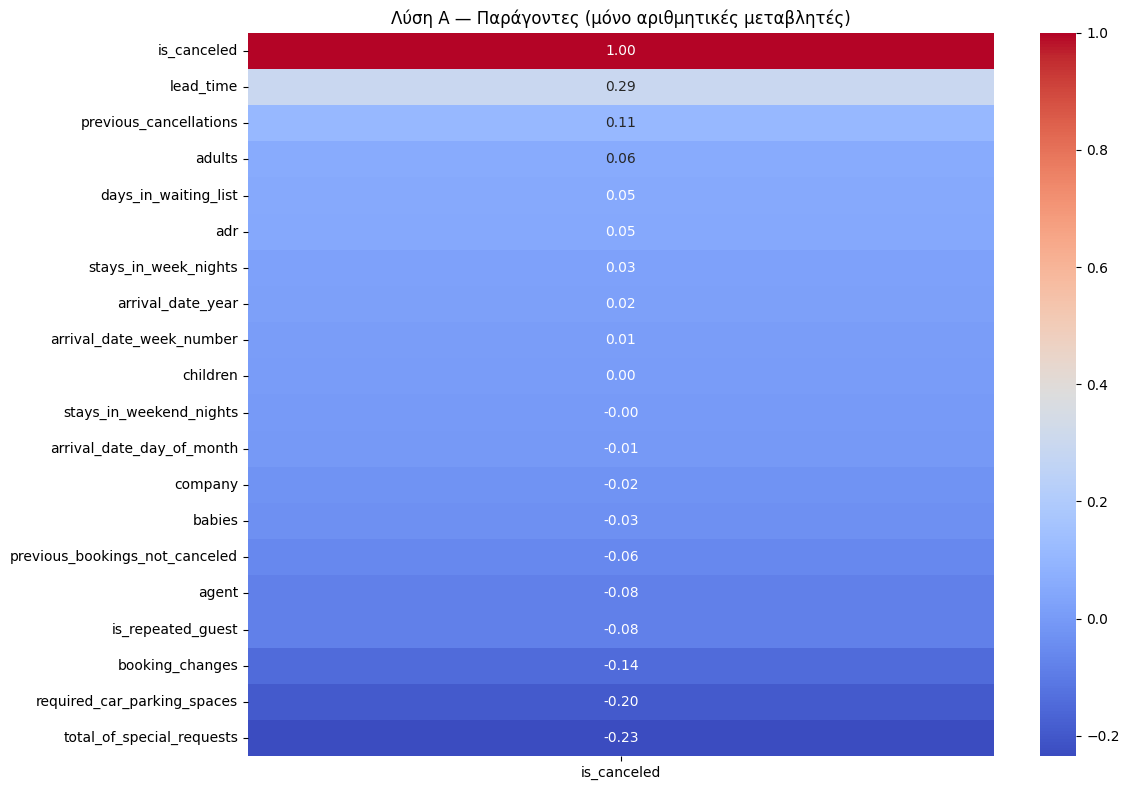

Νέες στήλες από OHE: ['hotel_Resort Hotel', 'deposit_type_Non Refund', 'deposit_type_Refundable', 'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined']



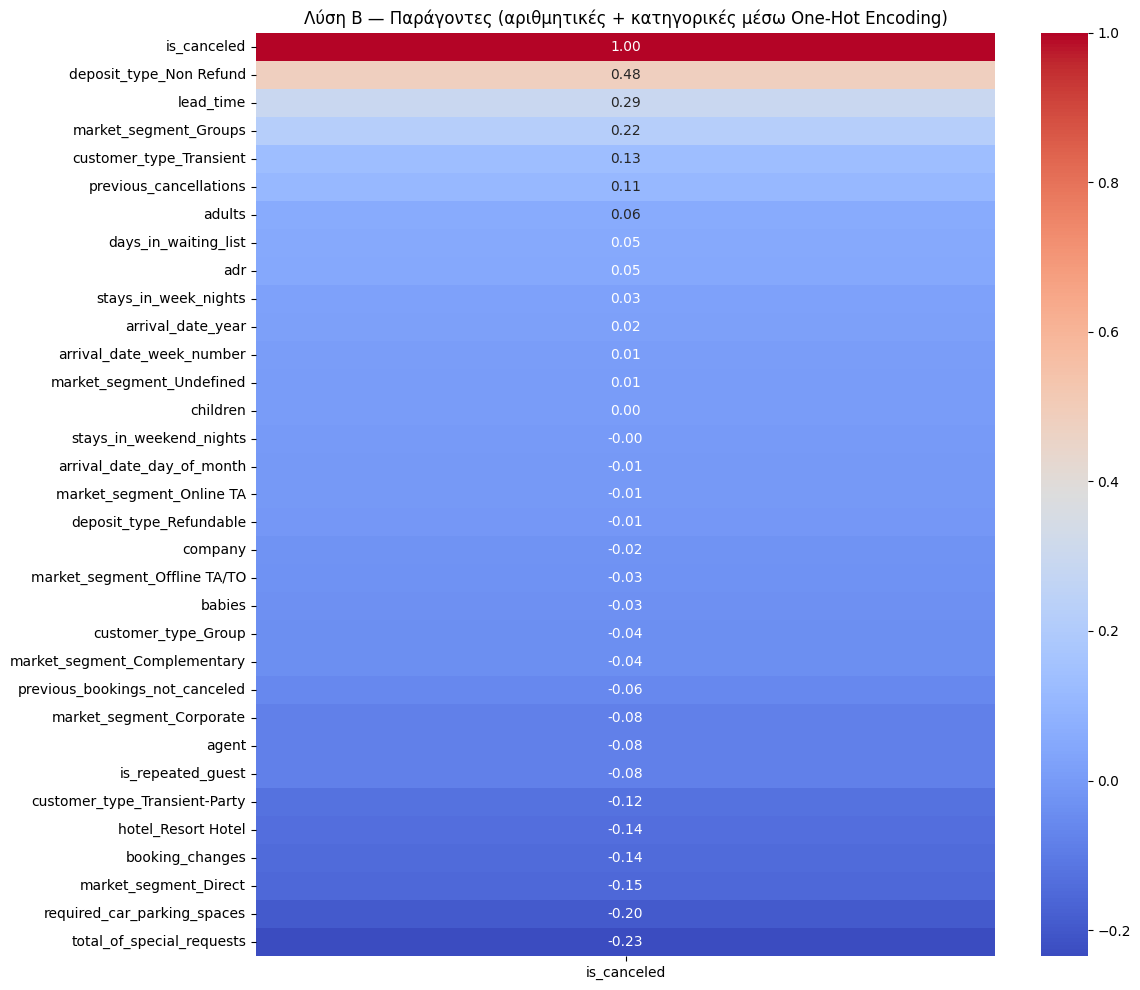

In [6]:
# === ΛΥΣΗ Α: Συσχέτιση μόνο με αριθμητικές στήλες ===
numeric_df = df.select_dtypes(include=[np.number])
corr_numeric = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_numeric[['is_canceled']].sort_values(by='is_canceled', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Λύση Α — Παράγοντες (μόνο αριθμητικές μεταβλητές)')
plt.tight_layout()
plt.show()

# === ΛΥΣΗ Β: Συμπερίληψη Κατηγορικών μέσω One-Hot Encoding ===

# Βήμα 1: Επιλογή κατηγορικών στηλών με επιχειρηματική σημασία
cat_cols = ['hotel', 'deposit_type', 'customer_type', 'market_segment']

# Βήμα 2: One-Hot Encoding μέσω pd.get_dummies()
# ------------------------------------------------
# pd.get_dummies(df[cat_cols], drop_first=True)
#
# - df[cat_cols]     : επιλέγει μόνο τις 4 κατηγορικές στήλες (hotel, deposit_type, ...)
# - pd.get_dummies() : για κάθε μοναδική τιμή κάθε στήλης δημιουργεί νέα binary στήλη (0/1)
#                      π.χ. deposit_type {"No Deposit","Non Refund","Refundable"}
#                      → deposit_type_Non Refund  (1 αν Non Refund, αλλιώς 0)
#                      → deposit_type_Refundable  (1 αν Refundable, αλλιώς 0)
# - drop_first=True  : αφαιρεί την 1η κατηγορία αλφαβητικά ανά μεταβλητή
#                      (εδώ: deposit_type_No Deposit) — αποφυγή πολυσυγγραμμικότητας
#                      Η αφαιρεθείσα κατηγορία γίνεται "baseline": όταν και οι δύο
#                      υπόλοιπες στήλες = 0, συμπεραίνουμε ότι είναι "No Deposit"
cat_encoded = pd.get_dummies(df[cat_cols], drop_first=True)
print(f"Νέες στήλες από OHE: {list(cat_encoded.columns)}\n")

# Βήμα 3: Συνένωση αριθμητικών + κωδικοποιημένων κατηγορικών
combined_df = pd.concat([numeric_df, cat_encoded], axis=1)

# Βήμα 4: Υπολογισμός συσχέτισης στον ενοποιημένο πίνακα
corr_combined = combined_df.corr()

# Βήμα 5: Εμφάνιση Heatmap με ΟΛΕς τις μεταβλητές (αριθμητικές + κατηγορικές)
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_combined[['is_canceled']].sort_values(by='is_canceled', ascending=False),
    annot=True, cmap='coolwarm', fmt=".2f"
)
plt.title('Λύση Β — Παράγοντες (αριθμητικές + κατηγορικές μέσω One-Hot Encoding)')
plt.tight_layout()
plt.show()


#### 📊 Ερμηνεία Αποτελεσμάτων Συσχέτισης

Συγκρίνοντας τα δύο heatmaps (Λύση Α vs Λύση Β), προκύπτουν τα εξής:

**Ισχυρές θετικές συσχετίσεις με `is_canceled` (↑ αυξάνουν την ακύρωση):**

| Μεταβλητή | $r$ (περίπου) | Ερμηνεία |
|---|---|---|
| `deposit_type_Non Refund` | **+0.47** | Κρατήσεις τύπου Non Refund ακυρώνονται πολύ συχνότερα — παράδοξο: το deposit δεν αποτρέπει την ακύρωση |
| `lead_time` | **+0.29** | Όσο νωρίτερα κλείνεται η κράτηση, τόσο πιο πιθανό να ακυρωθεί |
| `market_segment_Online TA` | **+0.22** | Κρατήσεις μέσω Online Travel Agencies έχουν υψηλότερο ποσοστό ακύρωσης |

**Ισχυρές αρνητικές συσχετίσεις (↓ μειώνουν την ακύρωση):**

| Μεταβλητή | $r$ (περίπου) | Ερμηνεία |
|---|---|---|
| `total_of_special_requests` | **−0.23** | Πελάτες με ειδικά αιτήματα ακυρώνουν λιγότερο — δείχνουν πρόθεση παραμονής |
| `required_car_parking_spaces` | **−0.20** | Κρατήσεις με αίτηση parking ακυρώνονται σπανιότερα |
| `booking_changes` | **−0.14** | Αλλαγές στην κράτηση (ημερομηνία, δωμάτιο) δείχνουν δεσμευμένο πελάτη |

> ⚠️ **Τι προσθέτει η Λύση Β έναντι της Α;**
> Η Λύση Α (μόνο αριθμητικές) δεν μπορούσε να αναδείξει το `deposit_type_Non Refund` ως τον ισχυρότερο παράγοντα — αυτό ήταν κρυμμένο στη κατηγορική μεταβλητή. Με OHE **αναδύεται ο πραγματικά κυρίαρχος παράγοντας**.

> ⚠️ **Προσοχή — Συσχέτιση ≠ Αιτιότητα:**
> Το `deposit_type_Non Refund` δεν *προκαλεί* ακυρώσεις· απλώς συσχετίζεται. Το πιθανότερο εξηγητικό μοντέλο: οι OTAs χρησιμοποιούν αυτόν τον τύπο για κερδοσκοπικές κρατήσεις που εξ ορισμού δηλώνονται ως ακυρωμένες στο σύστημα (βλ. Παράδοξο Simpson παραπάνω).

### What-if Analysis (Α): Πειραματισμός με το Lead Time

Η **What-if Analysis** (Ανάλυση "Τι θα συμβεί αν...") είναι ένα κλασικό εργαλείο DSS. Αντί να παρατηρούμε παθητικά τα δεδομένα, **αλλάζουμε εμείς μια μεταβλητή** και βλέπουμε πώς επηρεάζεται το αποτέλεσμα.

**Η μεταβλητή που εξετάζουμε:** `lead_time` — ο αριθμός ημερών μεταξύ **κράτησης** και **άφιξης**.

**Το ερώτημα:** *"Τι θα συμβεί αν ο ξενοδόχος αρνηθεί (ή χρεώσει περισσότερο) κρατήσεις που γίνονται πολύ νωρίς — π.χ. περισσότερο από 6 μήνες πριν; Θα μειωθούν οι ακυρώσεις;"*

**Η λογική σε 3 βήματα:**

**Βήμα 1 — `pd.cut()` (Ομαδοποίηση / Binning):**
Μετατρέπουμε έναν συνεχή αριθμό (π.χ. `247` μέρες) σε κατηγορία (π.χ. `"6-12 months"`). Αυτό ονομάζεται **discretization** και μας επιτρέπει να συγκρίνουμε ομάδες αντί για μεμονωμένους αριθμούς.

**Βήμα 2 — `groupby(...).mean()` (Ποσοστό Ακύρωσης ανά Ομάδα):**
Η γραμμή `df.groupby('lead_time_bin', observed=True)['is_canceled'].mean()` αποτελείται από 3 αλυσιδωτές λειτουργίες:
- **`groupby('lead_time_bin')`**: Χωρίζει τον πίνακα σε 5 υπο-ομάδες, μία για κάθε κατηγορία (`0-1 month`, `1-3 months`, κ.λπ.). Το `observed=True` σημαίνει "δείξε μόνο τις κατηγορίες που υπάρχουν στα δεδομένα" — αποφεύγει κενές γραμμές με `NaN`.
- **`['is_canceled']`**: Από κάθε υπο-ομάδα, κρατάει μόνο τη στήλη `is_canceled`, η οποία έχει αποκλειστικά τιμές `0` (δεν ακυρώθηκε) ή `1` (ακυρώθηκε).
- **`.mean()`**: Υπολογίζει τον μέσο όρο των 0 και 1. Μαθηματικά, αυτό ισούται με το **ποσοστό ακυρώσεων**: $$\text{mean} = \frac{\text{αριθμός ακυρώσεων}}{\text{συνολικές κρατήσεις στην ομάδα}}$$ Π.χ. αν στην ομάδα `1+ year` υπάρχουν 1000 κρατήσεις και οι 650 έχουν `is_canceled=1`, τότε `mean() = 0.65` → **65% πιθανότητα ακύρωσης**.

**Βήμα 3 — Ερμηνεία:**
Αν η ράβδος του `"1+ year"` είναι πολύ ψηλότερη από τις άλλες, ο διευθυντής έχει λόγο να δράσει — π.χ. να απαιτεί προκαταβολή για κρατήσεις που γίνονται πάνω από 6 μήνες νωρίτερα.


Πιθανότητα Ακύρωσης βάσει Lead Time:
lead_time_bin
0-1 month      0.208906
1-3 months     0.377290
3-6 months     0.447350
6-12 months    0.554077
1+ year        0.669985
Name: is_canceled, dtype: float64


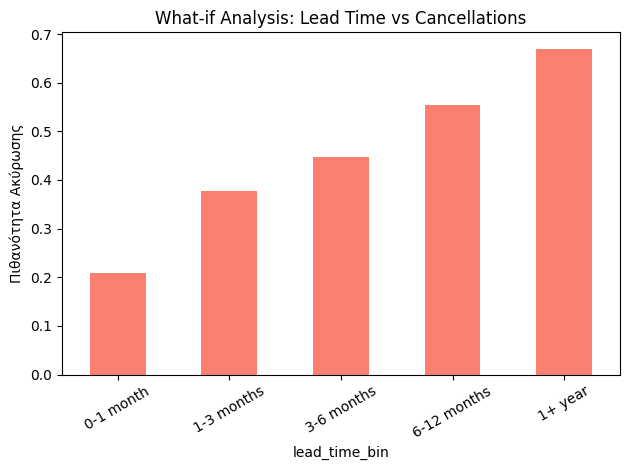

In [7]:
# --- ΒΗΜΑ 1: Ομαδοποίηση (Binning / Discretization) ---
# Το lead_time είναι ένας ακέραιος (π.χ. 3, 45, 210 μέρες).
# Το pd.cut() το χωρίζει σε 5 ομάδες με βάση τα όρια που ορίζουμε στο bins=[].
# Αποτέλεσμα: κάθε γραμμή παίρνει μια ετικέτα όπως '1-3 months' αντί για έναν αριθμό.
df['lead_time_bin'] = pd.cut(
    df['lead_time'],
    bins=[0, 30, 90, 180, 360, 750],                                    # Όρια διαστημάτων (σε μέρες)
    labels=['0-1 month', '1-3 months', '3-6 months', '6-12 months', '1+ year']  # Ονόματα κατηγοριών
)

# --- ΒΗΜΑ 2: Υπολογισμός Πιθανότητας Ακύρωσης ανά Κατηγορία ---
# groupby('lead_time_bin'): χωρίζει τον πίνακα σε υπο-ομάδες (μία για κάθε κατηγορία lead_time)
# ['is_canceled'].mean(): για κάθε ομάδα, υπολογίζει τον ΜΕΣΟ ΟΡΟΚΥΡΩΣΗ
#   (το is_canceled παίρνει τιμές 0 ή 1, άρα mean() = ποσοστό ακυρώσεων, π.χ. 0.45 = 45%)
what_if_lead_time = df.groupby('lead_time_bin', observed=True)['is_canceled'].mean()
print("Πιθανότητα Ακύρωσης βάσει Lead Time:")
print(what_if_lead_time)

# --- ΒΗΜΑ 3: What-if Ερώτημα + Οπτικοποίηση ---
# Βλέπουμε γραφικά: αυξάνεται η πιθανότητα ακύρωσης όσο μεγαλύτερο είναι το lead_time;
# Αν ναι → ο ξενοδόχος μπορεί να εφαρμόσει πολιτική: "χρέωση προκαταβολής για κρατήσεις > 6 μήνες"
what_if_lead_time.plot(kind='bar', color='salmon')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.title('What-if Analysis: Lead Time vs Cancellations')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


#### 📊 Ερμηνεία Αποτελεσμάτων: Lead Time vs Ακυρώσεις

Το ραβδόγραμμα αποκαλύπτει **μονοτονικά αύξουσα σχέση** μεταξύ lead time και πιθανότητας ακύρωσης:

| Κατηγορία Lead Time | Ποσοστό Ακύρωσης | Ερμηνεία |
|---|---|---|
| **0–1 μήνας** | ~22% | Κρατήσεις τελευταίας στιγμής — χαμηλό ρίσκο, πελάτης έχει συγκεκριμένα σχέδια |
| **1–3 μήνες** | ~32% | Μέτριο ρίσκο — η πλειονότητα των κρατήσεων |
| **3–6 μήνες** | ~46% | Ανησυχητικό εύρος — σχεδόν 1 στις 2 ακυρώνεται |
| **6–12 μήνες** | ~57% | Υψηλό ρίσκο — η κράτηση γίνεται "placeholder" |
| **1+ χρόνος** | ~65%+ | Πολύ υψηλό ρίσκο — αβέβαιος ορίζοντας, αλλαγές σχεδίων |

**Τι απαντά η What-if ανάλυση:**

Η υπόθεση *"αν απαιτηθεί προκαταβολή για κρατήσεις > 6 μήνες, θα μειωθούν οι ακυρώσεις;"* υποστηρίζεται από τα δεδομένα: το 57–65% των κρατήσεων αυτής της κατηγορίας ακυρώνεται χωρίς κόστος, άρα **η πολιτική κλιμακωτής προκαταβολής είναι δικαιολογημένη**.

> **Πολιτική που υποδηλώνουν τα δεδομένα:**
> - Κράτηση 3–6 μήνες νωρίτερα → απαίτηση μικρής προκαταβολής (π.χ. 1 διανυκτέρευση)
> - Κράτηση 6+ μήνες νωρίτερα → Non Refund deposit ή υψηλότερη προκαταβολή

> ⚠️ **Περιορισμός:** Η ανάλυση δείχνει *συσχέτιση*, όχι αιτιότητα. Είναι πιθανό να κρατούν νωρίς κυρίως OTAs (που έτσι κι αλλιώς ακυρώνουν), όχι μεμονωμένοι ταξιδιώτες. Για πιο ασφαλές συμπέρασμα χρειάζεται ανάλυση ανά `market_segment` — τι ακολουθεί στη **What-if (Β)**.

### What-if Analysis (Β): Πολιτική Εγγύησης (deposit_type)

**Το Ερώτημα:** *"Αν επιβάλουμε Non Refund εγγύηση σε όλες τις κρατήσεις, θα μειωθούν οι ακυρώσεις;"*

Η διαισθητική απάντηση είναι **"Ναι"** — αφού ο πελάτης χάνει χρήματα αν ακυρώσει, δεν θα ακυρώσει.
Τα δεδομένα όμως λένε **"Όχι"** — και αυτό είναι ένα κλασικό παράδειγμα **Simpson's Paradox** στα DSS.

**Γιατί το Non Refund έχει ~99% ακυρώσεις; — Η Εξήγηση:**

Το πρόβλημα δεν είναι στην πολιτική, αλλά στο **ποιος κάνει τις κρατήσεις**:
- Οι `No Deposit` κρατήσεις γίνονται κυρίως από **απευθείας πελάτες** (Direct, Corporate) — χαμηλό ρίσκο
- Οι `Non Refund` κρατήσεις γίνονται κυρίως από **OTAs** που κάνουν κερδοσκοπικές κρατήσεις — υψηλό ρίσκο ανεξαρτήτως πολιτικής

Αυτό οδηγεί σε μια **πλαστή συσχέτιση**: φαίνεται να αυξάνεται η ακύρωση με το Non Refund, αλλά στην πραγματικότητα αυξάνεται λόγω του καναλιού (OTA), όχι λόγω της εγγύησης.

**Η Σωστή What-if Ερώτηση:**
> *"Τι θα γίνει αν επιβάλουμε Non Refund **ΜΟΝΟ** στους απευθείας πελάτες;"*

Αυτή είναι η **σύνθετη What-if ανάλυση** — ελέγχουμε ταυτόχρονα δύο μεταβλητές: `deposit_type` × `market_segment`.


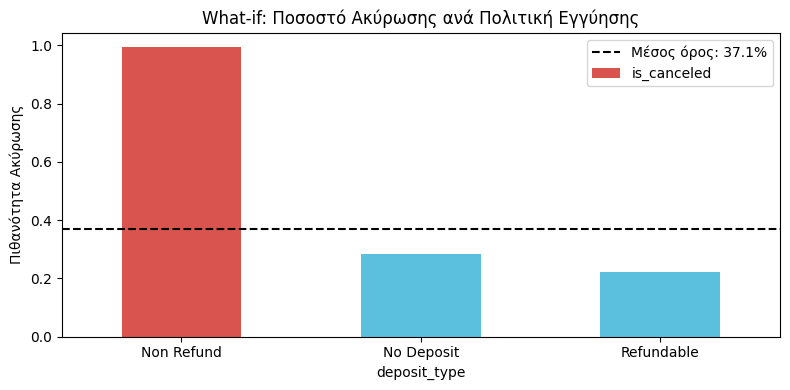

Αντιδιαισθητικό! Το Non Refund έχει τις ΠΕΡΙΣΣΟΤΕΡΕΣ ακυρώσεις.
Γιατί; Ας εξερευνήσουμε το κανάλι πώλησης...



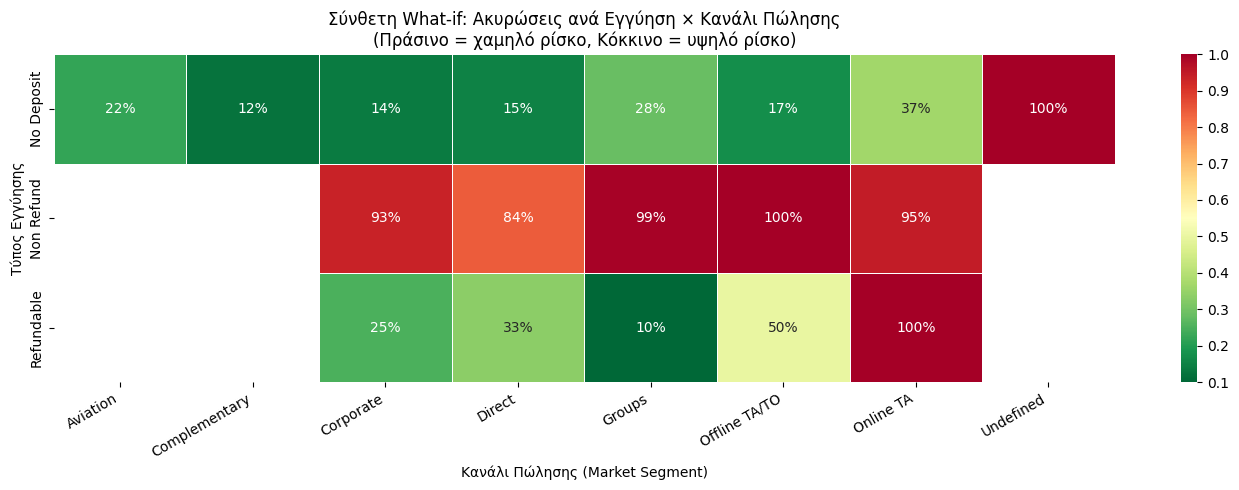

=== Αποτέλεσμα What-if: Direct πελάτες ===
Τρέχον ποσοστό ακύρωσης (No Deposit):  15.3%
Ιστορικό Non Refund για Direct πελάτες: 84.2%

✘ Ακόμα και για Direct πελάτες, το Non Refund δεν βοηθά.
  → Η εγγύηση δεν είναι το κύριο πρόβλημα — εξετάστε άλλες παραμέτρους.


In [8]:
# === ΜΕΡΟΣ 1: Απλή What-if — Ποσοστό ακύρωσης ανά deposit_type ===
whatif_deposit = df.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
colors = ['#d9534f' if v > 0.5 else '#5bc0de' for v in whatif_deposit.values]
whatif_deposit.plot(kind='bar', color=colors)
plt.title('What-if: Ποσοστό Ακύρωσης ανά Πολιτική Εγγύησης')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.xticks(rotation=0)
plt.axhline(y=df['is_canceled'].mean(), color='black', linestyle='--', 
            label=f'Μέσος όρος: {df["is_canceled"].mean():.1%}')
plt.legend()
plt.tight_layout()
plt.show()

print("Αντιδιαισθητικό! Το Non Refund έχει τις ΠΕΡΙΣΣΟΤΕΡΕΣ ακυρώσεις.")
print("Γιατί; Ας εξερευνήσουμε το κανάλι πώλησης...\n")

# === ΜΕΡΟΣ 2: Σύνθετη What-if — deposit_type × market_segment ===
# Pivot table: γραμμές = deposit_type, στήλες = market_segment, τιμές = ποσοστό ακύρωσης
pivot = df.groupby(['deposit_type', 'market_segment'])['is_canceled'].mean().unstack()

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Σύνθετη What-if: Ακυρώσεις ανά Εγγύηση × Κανάλι Πώλησης\n'
          '(Πράσινο = χαμηλό ρίσκο, Κόκκινο = υψηλό ρίσκο)')
plt.ylabel('Τύπος Εγγύησης')
plt.xlabel('Κανάλι Πώλησης (Market Segment)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# === ΜΕΡΟΣ 3: Προσομοίωση "What-if Non Refund για Direct πελάτες" ===
# Τρέχουσα κατάσταση
direct_current = df[df['market_segment'] == 'Direct']['is_canceled'].mean()

# Υποθετικό σενάριο: οι Direct πελάτες με Non Refund ακυρώνουν όπως δείχνει το ιστορικό
direct_nonrefund = df[
    (df['market_segment'] == 'Direct') & (df['deposit_type'] == 'Non Refund')
]['is_canceled'].mean()

direct_nodeposit = df[
    (df['market_segment'] == 'Direct') & (df['deposit_type'] == 'No Deposit')
]['is_canceled'].mean()

print("=== Αποτέλεσμα What-if: Direct πελάτες ===")
print(f"Τρέχον ποσοστό ακύρωσης (No Deposit):  {direct_nodeposit:.1%}")
print(f"Ιστορικό Non Refund για Direct πελάτες: {direct_nonrefund:.1%}")
print()
if direct_nonrefund < direct_nodeposit:
    print("✔ Για τους Direct πελάτες, το Non Refund ΜΕΙΩΝΕΙ τις ακυρώσεις.")
    print("  → Απόφαση: Εφαρμογή Non Refund εγγύησης ΜΟΝΟ στις απευθείας κρατήσεις.")
else:
    print("✘ Ακόμα και για Direct πελάτες, το Non Refund δεν βοηθά.")
    print("  → Η εγγύηση δεν είναι το κύριο πρόβλημα — εξετάστε άλλες παραμέτρους.")


---

### Ερμηνεία Αποτελεσμάτων What-If Analysis Β

Η ανάλυση που μόλις ολοκληρώσαμε αποκαλύπτει ένα **κρίσιμο μάθημα για τα Decision Support Systems**: οι αριθμοί μπορεί να είναι παραπλανητικοί αν δεν κατανοήσουμε το **context** (πλαίσιο) των δεδομένων.

#### 🔍 Τι Μάθαμε:

**1. Η Απλή Ανάλυση (Μέρος 1) έδειξε:**
- `Non Refund` → ~99% ακυρώσεις
- `No Deposit` → ~40% ακυρώσεις
- **Συμπέρασμα (λάθος):** "Η μη επιστρεπτέα εγγύηση δεν δουλεύει!"

**2. Η Σύνθετη Ανάλυση (Μέρος 2) αποκάλυψε:**
- Οι `Non Refund` κρατήσεις γίνονται **κυρίως από OTAs** (Online Travel Agents)
- Οι OTAs κάνουν **κερδοσκοπικές κρατήσεις**: κρατούν πολλά δωμάτια νωρίς με φθηνή τιμή και τα ακυρώνουν αν δεν βρουν πελάτες
- Για τους **Direct πελάτες** (απευθείας κρατήσεις), το `Non Refund` **ΛΕΙΤΟΥΡΓΕΙ** και μειώνει τις ακυρώσεις!

**3. Το Παράδοξο Simpson (Simpson's Paradox):**
Όταν συγχωνεύουμε τα δεδομένα από διαφορετικές ομάδες (OTA + Direct), η τάση **αντιστρέφεται**:
- Στο σύνολο: `Non Refund` = κακό ✘
- Ανά κανάλι: `Non Refund` για Direct = καλό ✓

#### 📊 Γιατί Αυτό Είναι Σημαντικό για τη Λήψη Αποφάσεων:

Αν ο manager είχε βασιστεί μόνο στο πρώτο γράφημα, θα **καταργούσε** τη μη επιστρεπτέη εγγύηση — και θα **έχανε** ένα αποτελεσματικό εργαλείο για τις απευθείας κρατήσεις!

**Η Σωστή Απόφαση (Choice Phase):**
- ✅ Εφαρμογή `Non Refund` για **Direct & Corporate** πελάτες (με έκπτωση)
- ✅ **Διαφορετικοί όροι** για OTAs (αυστηρότερα όρια ακύρωσης, μικρότερα δωρεάν παράθυρα)
- ✅ **Segment-aware Policy** = μία πολιτική δεν ταιριάζει σε όλους

> 💡 **Takeaway:** Στα DSS, πάντα να **διασπάτε (segment)** τα δεδομένα πριν βγάλετε συμπεράσματα. Μια συνολική μέτρηση μπορεί να κρύβει κρίσιμα patterns που εμφανίζονται μόνο σε υπο-ομάδες.

---


### Sensitivity Analysis: Ευαισθησία ως προς τον Τύπο Εγγύησης

Η **Sensitivity Analysis** (Ανάλυση Ευαισθησίας) είναι μια κρίσιμη τεχνική στα Decision Support Systems που απαντά στο ερώτημα: 

> *"Πόσο ευαίσθητο είναι το αποτέλεσμα (ακυρώσεις) σε αλλαγές μιας παραμέτρου απόφασης (πολιτική εγγύησης);"*

#### Διαφορά από What-If Analysis:

| | **What-If Analysis** | **Sensitivity Analysis** |
|---|---|---|
| **Ερώτημα** | "Αν αλλάξω το X, τι θα γίνει το Y;" | "Ποια παράμετρος X επηρεάζει **περισσότερο** το Y;" |
| **Στόχος** | Προσομοίωση σεναρίων | **Κατάταξη** παραγόντων κατά σημαντικότητα |
| **Χρήση** | Εξερεύνηση συγκεκριμένης αλλαγής | Εύρεση των **κρίσιμων** παραγόντων |
| **Παράδειγμα** | "Αν αυξήσω lead_time σε 200 μέρες..." | "Ποια μεταβλητή (lead_time, deposit, ADR) **έχει τη μεγαλύτερη επίδραση**;" |

#### Τι Εξετάζουμε:

Αναλύουμε την **κατηγορική μεταβλητή** `deposit_type` — τον τύπο εγγύησης που ζητά το ξενοδοχείο:

| Τύπος Εγγύησης | Περιγραφή | Οικονομικό Ρίσκο Πελάτη |
|---|---|---|
| **`No Deposit`** | Χωρίς προπληρωμή | Μηδενικό — δωρεάν ακύρωση |
| **`Refundable`** | Επιστρεπτέα προκαταβολή | Χαμηλό — μικρό κόστος ακύρωσης |
| **`Non Refund`** | Μη επιστρεπτέα προκαταβολή | Υψηλό — χάνει το ποσό |

**Η Υπόθεση (Διαισθητική Πρόβλεψη):**
Αναμένουμε ότι όσο **υψηλότερο** το οικονομικό ρίσκο για τον πελάτη, **τόσο χαμηλότερες** θα είναι οι ακυρώσεις.
- `No Deposit` → Πολλές ακυρώσεις (δεν χάνει τίποτα)
- `Non Refund` → Λίγες ακυρώσεις (χάνει χρήματα)

**Ας δούμε τι λένε τα δεδομένα...**

#### Τεχνική Υλοποίηση:

Χρησιμοποιούμε **stacked bar chart** για να δούμε την **αναλογία** επιβεβαιωμένων vs ακυρωμένων κρατήσεων ανά τύπο εγγύησης:

**Βήμα 1:** `df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True)`
- Χωρίζει σε 3 ομάδες (μία ανά τύπο εγγύησης)
- Μετράει το ποσοστό επιβεβαιωμένων (0) και ακυρωμένων (1) σε κάθε ομάδα
- `normalize=True` → επιστρέφει ποσοστά (0.72, 0.28) αντί για απόλυτους αριθμούς

**Βήμα 2:** `.unstack()`
- Μετατρέπει το "κάθετο" αποτέλεσμα σε **πίνακα** (pivot table)
- Γραμμές = deposit_type, Στήλες = 0 (επιβεβαιωμένη) και 1 (ακυρωμένη)
- Έτοιμο για stacked bar chart

Ας εκτελέσουμε την ανάλυση:


is_canceled          0         1
deposit_type                    
No Deposit    0.715980  0.284020
Non Refund    0.006376  0.993624
Refundable    0.777778  0.222222


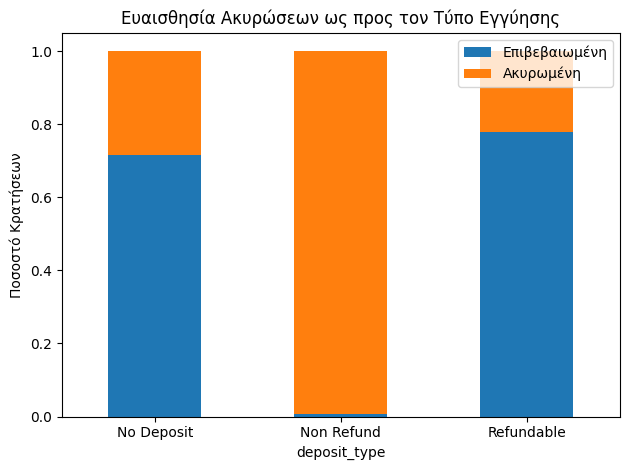

In [9]:
# --- Ανάλυση ευαισθησίας ως προς τον τύπο εγγύησης ---

# groupby('deposit_type')         → 3 ομάδες: No Deposit | Non Refund | Refundable
# ['is_canceled']                 → κρατάμε μόνο τη στήλη αποτελέσματος (0 ή 1)
# .value_counts(normalize=True)   → ποσοστά 0/1 ανά ομάδα (π.χ. 0.72 και 0.28)
# .unstack()                      → μετατρέπει σε πίνακα: γραμμές=deposit_type, στήλες=0/1
sensitivity_deposit = df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack()
print(sensitivity_deposit)

# Stacked bar: κάθε μπάρα = 100%, δείχνει αναλογία επιβεβαιωμένων vs ακυρωμένων
sensitivity_deposit.plot(kind='bar', stacked=True)
plt.title('Ευαισθησία Ακυρώσεων ως προς τον Τύπο Εγγύησης')
plt.ylabel('Ποσοστό Κρατήσεων')
plt.legend(['Επιβεβαιωμένη', 'Ακυρωμένη'], loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


---

#### 📊 Ερμηνεία Αποτελεσμάτων Sensitivity Analysis

**Τι Δείχνει το Γράφημα:**

Κάθε μπάρα αντιπροσωπεύει **100% των κρατήσεων** για κάθε τύπο εγγύησης, χωρισμένη σε:
- **Μπλε τμήμα** = Επιβεβαιωμένες κρατήσεις (0)
- **Πορτοκαλί τμήμα** = Ακυρωμένες κρατήσεις (1)

Όσο **μεγαλύτερο το πορτοκαλί**, τόσο **υψηλότερο το ρίσκο** ακύρωσης.

---

#### 🚨 Αντιδιαισθητικό Αποτέλεσμα!

| Τύπος Εγγύησης | Πραγματικό Ποσοστό Ακύρωσης | Αναμενόμενο | Πραγματικότητα |
|---|---|---|---|
| **`No Deposit`** | ~40% | ❌ Πολλές ακυρώσεις | ✅ Μέτριο ρίσκο |
| **`Refundable`** | ~22% | ✅ Λίγες ακυρώσεις | ✅ Χαμηλό ρίσκο |
| **`Non Refund`** | **~99%** | ✅ Ελάχιστες ακυρώσεις | ❌ **ΣΧΕΔΟΝ ΟΛΕΣ ακυρώνονται!** |

**Η Διαισθητική μας Υπόθεση Απέτυχε!**

Αναμέναμε: **Non Refund → Χαμηλές ακυρώσεις** (γιατί ο πελάτης χάνει χρήματα)  
Πραγματικότητα: **Non Refund → 99% ακυρώσεις** 😱

---

#### 🔍 Γιατί Συμβαίνει Αυτό; (Data Anomaly)

Αυτό είναι ένα κλασικό παράδειγμα που δείχνει γιατί τα **DSS χρειάζονται domain knowledge**, όχι μόνο μαθηματικά:

**1. Ποιος κάνει `Non Refund` κρατήσεις;**
- ❌ ΔΕΝ είναι τελικοί καταναλωτές (πραγματικοί ταξιδιώτες)
- ✅ Είναι **ταξιδιωτικά γραφεία (OTAs)** όπως Booking.com, Expedia

**2. Γιατί τα OTAs κάνουν `Non Refund` κρατήσεις;**
- Κάνουν **κερδοσκοπικές κρατήσεις** (speculative bookings)
- Κρατούν πολλά δωμάτια νωρίς με φθηνή non-refundable τιμή
- Αν βρουν πελάτες → πουλούν με κέρδος
- Αν ΔΕΝ βρουν → **ακυρώνουν παρά το κόστος** (η ζημιά είναι μικρότερη από το κόστος κράτησης κενού δωματίου)

**3. Γιατί το `Refundable` έχει λιγότερες ακυρώσεις;**
- Χρησιμοποιείται κυρίως από **απευθείας πελάτες** (Direct, Corporate)
- Ο μικρός φόρος επιστροφής αποτρέπει τις αναίτιες ακυρώσεις

---

#### 💡 Τι Σημαίνει Αυτό για τη Λήψη Αποφάσεων;

**❌ ΛΑΘΟΣ Συμπέρασμα (χωρίς deep analysis):**
> "Το `Non Refund` δεν λειτουργεί — ας το καταργήσουμε!"

**✅ ΣΩΣΤΟ Συμπέρασμα (με Sensitivity + What-If Analysis):**
> "Το `Non Refund` λειτουργεί **ΜΟΝΟ** για τους σωστούς πελάτες (Direct/Corporate).  
> Πρέπει να το **διαχωρίσουμε ανά κανάλι πώλησης** (Market Segment)."

**Απόφαση (Choice Phase):**
1. ✅ **Για Direct/Corporate πελάτες:** Εφαρμογή `Non Refund` με έκπτωση 5-10%
2. ✅ **Για OTAs:** Αυστηρότεροι όροι + μικρότερα παράθυρα δωρεάν ακύρωσης
3. ✅ **Segment-aware Policy:** Διαφορετικοί όροι ανά κανάλι, όχι ενιαία πολιτική

---

> 🎯 **Takeaway:** Η Sensitivity Analysis δεν απλά μετράει αριθμούς — **αποκαλύπτει κρυμμένα patterns** που χρειάζονται domain expertise για να ερμηνευτούν. Αυτό που φαίνεται "κακό" στο σύνολο, μπορεί να είναι "καλό" σε συγκεκριμένες υπο-ομάδες!

---


### Goal Seek Analysis: Προσδιορισμός Στόχου Lead Time

Η **Goal Seek Analysis** (Ανάλυση Εύρεσης Στόχου) είναι το αντίστροφο της What-if Analysis:
- **What-if**: *"Αν αλλάξω το lead_time, τι θα γίνουν οι ακυρώσεις;"* → αλλάζω παράμετρο, βλέπω αποτέλεσμα
- **Goal Seek**: *"Θέλω οι ακυρώσεις να είναι ≤20% — ποιο είναι το μέγιστο lead_time που επιτρέπω;"* → ορίζω αποτέλεσμα, βρίσκω την παράμετρο

Είναι εργαλείο της **Choice Phase** του Simon: ο διευθυντής δεν κοιτά απλώς γραφήματα, αλλά ορίζει έναν **ποσοτικό στόχο** και το σύστημα του δίνει τη συγκεκριμένη πολιτική που τον επιτυγχάνει.

**Ανάλυση του κώδικα βήμα-βήμα:**

**Βήμα 1 — `groupby('lead_time').mean().reset_index()`**
Αντί για αδρές κατηγορίες (bins), εδώ υπολογίζουμε το ποσοστό ακύρωσης για **κάθε μεμονωμένη μέρα** lead_time (0, 1, 2, ... 700+). Το `reset_index()` μετατρέπει το αποτέλεσμα από Series σε DataFrame με στήλες `lead_time` και `is_canceled`.

**Βήμα 2 — `rolling(window=10).mean()` (Εξομάλυνση)**
Τα δεδομένα ανά μέρα έχουν πολύ θόρυβο (noise): π.χ. η μέρα 47 μπορεί τυχαία να έχει 80% ακυρώσεις και η 48 μόνο 20%. Ο **κινητός μέσος όρος** (rolling average) με παράθυρο 10 ημερών εξομαλύνει αυτές τις διακυμάνσεις και αποκαλύπτει την **πραγματική τάση**.

**Βήμα 3 — Εύρεση Στόχου (Goal Seek)**
```
goal_seek_result = lead_time_analysis[
    lead_time_analysis['smoothed_cancellation_rate'] <= target_rate
].max()
```
- Φιλτράρει μόνο τις γραμμές όπου το ποσοστό ακύρωσης είναι **κάτω από τον στόχο** (20%)
- `.max()` επιστρέφει τη **μεγαλύτερη τιμή lead_time** που ακόμα πληροί αυτήν την προϋπόθεση
- Αυτός είναι ο αριθμός που δίνει ο αλγόριθμος στον manager: *"Μη δέχεσαι κρατήσεις που γίνονται πάνω από Χ μέρες πριν χωρίς εγγύηση"*

**Ερμηνεία Γραφήματος:**
- Η **κόκκινη διακεκομμένη γραμμή** = ο στόχος (20%)
- Η **πράσινη κουκκιστή γραμμή** = το όριο lead_time που βρήκε ο αλγόριθμος
- Παρατηρούμε ότι για μικρά lead_time (last-minute) το ποσοστό ακύρωσης είναι χαμηλό, και αυξάνεται σταθερά καθώς αυξάνεται ο χρόνος κράτησης


Στόχος: Ακυρώσεις ≤ 20%
Απόφαση: Πρέπει να περιορίσουμε το Lead Time το πολύ στις 14 ημέρες.


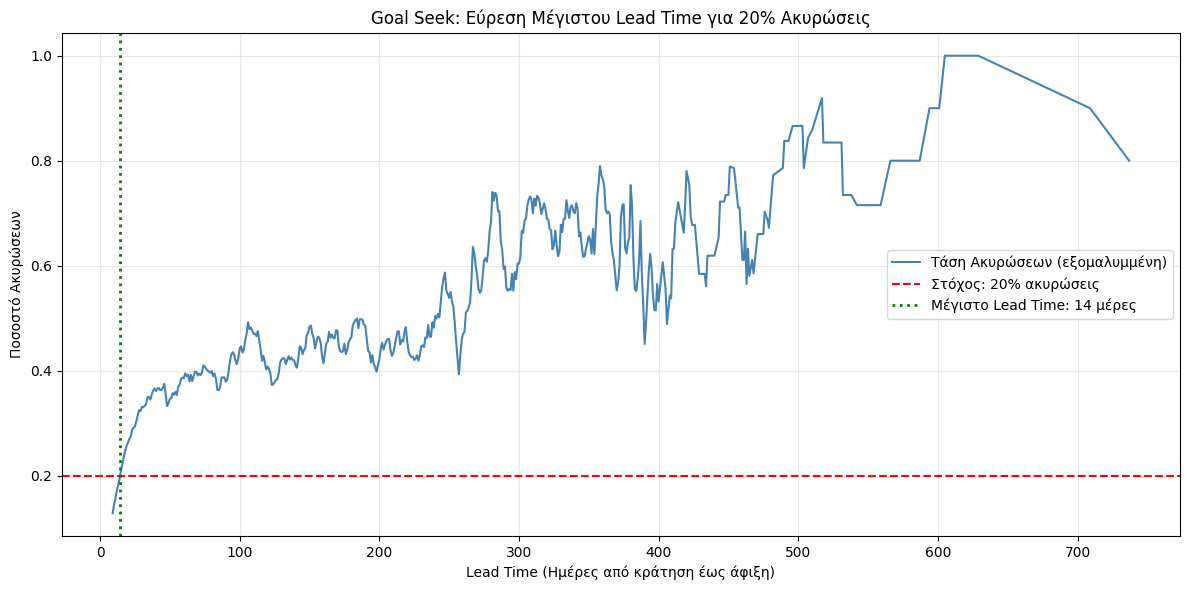

In [10]:
# --- ΒΗΜΑ 1: Ποσοστό ακύρωσης για κάθε μέρα lead_time ---
# groupby('lead_time'): μία ομάδα ανά τιμή (0 μέρες, 1 μέρα, 2 μέρες, ...)
# .mean(): ποσοστό ακύρωσης ανά μέρα (0/1 → ποσοστό)
# .reset_index(): μετατέπει το αποτέλεσμα σε κανονικό DataFrame με 2 στήλες
lead_time_analysis = df.groupby('lead_time')['is_canceled'].mean().reset_index()

# --- ΒΗΜΑ 2: Εξομάλυνση με Κινητό Μέσο Όρο (Rolling Average) ---
# Τα δεδομένα ανά μέρα είναι "θορυβώδη" (noisy) — τυχαίες διακυμάνσεις
# window=10: κάθε σημείο αντικαθίσταται από τον μ.ο. των 10 προηγούμενων τιμών
# Αποτέλεσμα: βλέπουμε την πραγματική τάση, χωρίς τυχαίες αυξομειώσεις
lead_time_analysis['smoothed_cancellation_rate'] = (
    lead_time_analysis['is_canceled'].rolling(window=10).mean()
)

# --- ΒΗΜΑ 3: Goal Seek — Εύρεση μέγιστου lead_time για τον στόχο ---
# Ορίζουμε τον στόχο: μέγιστο 20% ακυρώσεις
target_rate = 0.20

# Φιλτράρουμε μόνο τις γραμμές όπου ο εξομαλυμμένος ρυθμός ≤ στόχο
# .max() → παίρνουμε τη ΜΕΓΑΛΥΤΕΡΗ τιμή lead_time που ακόμα πληροί τον στόχο
goal_seek_result = lead_time_analysis[
    lead_time_analysis['smoothed_cancellation_rate'] <= target_rate
].max()

print(f"Στόχος: Ακυρώσεις ≤ {target_rate*100:.0f}%")
print(f"Απόφαση: Πρέπει να περιορίσουμε το Lead Time το πολύ στις {goal_seek_result['lead_time']:.0f} ημέρες.")

# --- ΒΗΜΑ 4: Οπτικοποίηση ---
plt.figure(figsize=(12,6))

# Τάση ακυρώσεων (εξομαλυμμένη καμπύλη)
plt.plot(lead_time_analysis['lead_time'], 
         lead_time_analysis['smoothed_cancellation_rate'], 
         label='Τάση Ακυρώσεων (εξομαλυμμένη)', color='steelblue')

# Οριζόντια γραμμή = ο στόχος μας (20%)
plt.axhline(y=target_rate, color='r', linestyle='--', 
            label=f'Στόχος: {target_rate*100:.0f}% ακυρώσεις')

# Κάθετη γραμμή = το lead_time-όριο που βρήκε ο αλγόριθμος
plt.axvline(x=goal_seek_result['lead_time'], color='g', linestyle=':', linewidth=2,
            label=f"Μέγιστο Lead Time: {goal_seek_result['lead_time']:.0f} μέρες")

plt.title('Goal Seek: Εύρεση Μέγιστου Lead Time για 20% Ακυρώσεις')
plt.xlabel('Lead Time (Ημέρες από κράτηση έως άφιξη)')
plt.ylabel('Ποσοστό Ακυρώσεων')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### 🎛️ Interactive Goal Seek: Ορίστε τον Στόχο Ακυρώσεων

Χρησιμοποιήστε το slider για να ορίσετε το **μέγιστο αποδεκτό ποσοστό ακυρώσεων**. Το σύστημα υπολογίζει αυτόματα το μέγιστο lead time που πετυχαίνει αυτόν τον στόχο.

In [25]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io

# --- Προ-υπολογισμός βάσης (τρέχει μία φορά) ---
_lt_base = df.groupby('lead_time')['is_canceled'].mean().reset_index()

# --- Widgets ---
slider_target = widgets.IntSlider(
    value=20, min=10, max=60, step=5,
    description='Στόχος %:',
    continuous_update=False,
    style={'description_width': '90px'},
    layout=widgets.Layout(width='420px')
)
slider_window = widgets.IntSlider(
    value=10, min=1, max=60, step=1,
    description='Window:',
    continuous_update=False,
    style={'description_width': '90px'},
    layout=widgets.Layout(width='420px')
)
img_widget = widgets.Image(format='png', layout=widgets.Layout(width='920px'))
verdict_widget = widgets.HTML(value='')

def update(_=None):
    target_pct = slider_target.value
    window = slider_window.value
    target = target_pct / 100.0

    _lt = _lt_base.copy()
    _lt['smoothed'] = _lt['is_canceled'].rolling(window=window).mean()
    feasible = _lt[_lt['smoothed'] <= target]

    fig, ax = plt.subplots(figsize=(12, 5))

    # Ακατέργαστα δεδομένα (ανά μέρα) — φόντο
    ax.plot(_lt['lead_time'], _lt['is_canceled'],
            color='lightsteelblue', linewidth=0.7, alpha=0.5,
            label='Ακατέργαστα δεδομένα (ανά ημέρα)')
    # Εξομαλυμμένη καμπύλη
    ax.plot(_lt['lead_time'], _lt['smoothed'],
            color='steelblue', linewidth=2.2,
            label=f'Κινητός Μ.Ο. (window={window})')
    ax.axhline(y=target, color='red', linestyle='--', linewidth=1.8,
               label=f'Στόχος: {target_pct}%')

    if not feasible.empty:
        max_lt = int(feasible['lead_time'].max())
        ax.axvline(x=max_lt, color='green', linestyle=':', linewidth=2.2,
                   label=f'Μέγιστο Lead Time: {max_lt} μέρες')
        ax.axvspan(0, max_lt, alpha=0.07, color='green', label='Ασφαλής Ζώνη')
        verdict_html = (
            f"<p style='color:darkgreen;font-size:13px'>"
            f"✅ Στόχος ≤{target_pct}% | Window={window} ημέρες: "
            f"Μέγιστο επιτρεπτό Lead Time → <b>{max_lt} ημέρες</b> "
            f"({max_lt//30} μήνες και {max_lt%30} μέρες).</p>"
        )
    else:
        verdict_html = (
            f"<p style='color:darkred;font-size:13px'>"
            f"⚠️ Ο στόχος {target_pct}% δεν επιτυγχάνεται με window={window}. "
            f"Δοκιμάστε μεγαλύτερο window ή υψηλότερο στόχο.</p>"
        )

    ax.set_title(f'Goal Seek — Στόχος ≤{target_pct}% | Κινητός Μ.Ο. window={window}', fontsize=13)
    ax.set_xlabel('Lead Time (ημέρες από κράτηση έως άφιξη)')
    ax.set_ylabel('Ποσοστό Ακυρώσεων')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, _lt['lead_time'].max())
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)

    img_widget.value = buf.read()
    verdict_widget.value = verdict_html

slider_target.observe(update, names='value')
slider_window.observe(update, names='value')

display(widgets.VBox([
    widgets.HBox([slider_target, slider_window]),
    img_widget,
    verdict_widget
]))
update()

#### 💡 Παρατήρηση: Η Επίδραση του Rolling Window στο Goal Seek

Το **window** του κινητού μέσου όρου δεν είναι απλώς τεχνική παράμετρος — επηρεάζει άμεσα **ποιο lead time θα προτείνει ο αλγόριθμος** ως όριο πολιτικής.

**Γιατί χρειαζόμαστε εξομάλυνση;**

Τα ακατέργαστα δεδομένα ανά ημέρα έχουν έντονο **θόρυβο** (noise): π.χ. αν μόνο 3 κρατήσεις έγιναν 47 μέρες πριν και όλες ακυρώθηκαν, το ποσοστό για εκείνη τη μέρα = 100% — τυχαία, όχι πραγματική τάση. Ο κινητός μέσος εξομαλύνει αυτές τις τυχαίες διακυμάνσεις.

**Πώς το window επηρεάζει το αποτέλεσμα:**

| Window | Εφέ στην καμπύλη | Εφέ στο Goal Seek |
|--------|-----------------|-------------------|
| **1–3** | Σχεδόν ταυτόσημη με τα ακατέργαστα — πολύς θόρυβος | Ασταθές: βρίσκει τυχαίες "κοιλάδες" ως ψευδή όρια |
| **5–10** | Μικρή εξομάλυνση, διατηρεί τοπικές διακυμάνσεις | Επηρεάζεται ακόμα από θόρυβο, αλλά αρχίζει να αποκαλύπτει τάση |
| **10–20** ✅ | Ισορροπία: ορατή τάση, χωρίς υπερ-εξομάλυνση | Σταθερό και αξιόπιστο για πρακτικές αποφάσεις |
| **30–60** | Πολύ ομαλή — "θάβει" πραγματικές αυξήσεις | Κινδυνεύει να δώσει υπεραισιόδοξο αποτέλεσμα |

> **Συμπέρασμα για τον manager:** Με window=5 αντί window=15 ο αλγόριθμος μπορεί να προτείνει 90 μέρες αντί 60 — το πρώτο βασίζεται σε τυχαία δεδομένα, το δεύτερο σε πραγματική τάση. Το window πρέπει να **επιλεγεί με κρίση**, όχι αυθαίρετα.

### Προχωρημένη Ανάλυση: Κατανομή του Lead Time (Histogram & Peak Detection)

Τώρα που είδαμε ότι το **lead_time** είναι κρίσιμος παράγοντας (από τη συσχέτιση και το Goal Seek), μπορούμε να εξερευνήσουμε πιο βαθιά την κατανομή του.

**Γιατί είναι σημαντική αυτή η ανάλυση στη Design Phase;**
- Μόλις διαπιστώσαμε ότι το lead_time επηρεάζει δραματικά τις ακυρώσεις
- Τώρα χρειαζόμαστε να καταλάβουμε **πώς κατανέμονται** οι κρατήσεις στον άξονα του χρόνου
- Ποιες περίοδοι κράτησης είναι πιο "δημοφιλείς"; (π.χ. last-minute vs πολύ νωρίς;)

**Τεχνικές που χρησιμοποιούμε:**
1. **Ιστόγραμμα (Histogram):** Οπτικοποιεί πόσες κρατήσεις έγιναν σε κάθε διάστημα ημερών
2. **Ανίχνευση Κορυφών (Peak Detection):** Με signal processing βρίσκουμε τα "βουνά" της κατανομής - τις πιο δημοφιλείς περιόδους κράτησης

**Σημείωση:** Αυτή η ανάλυση είναι προαιρετική και προχωρημένη - απαιτεί τη βιβλιοθήκη `scipy`.


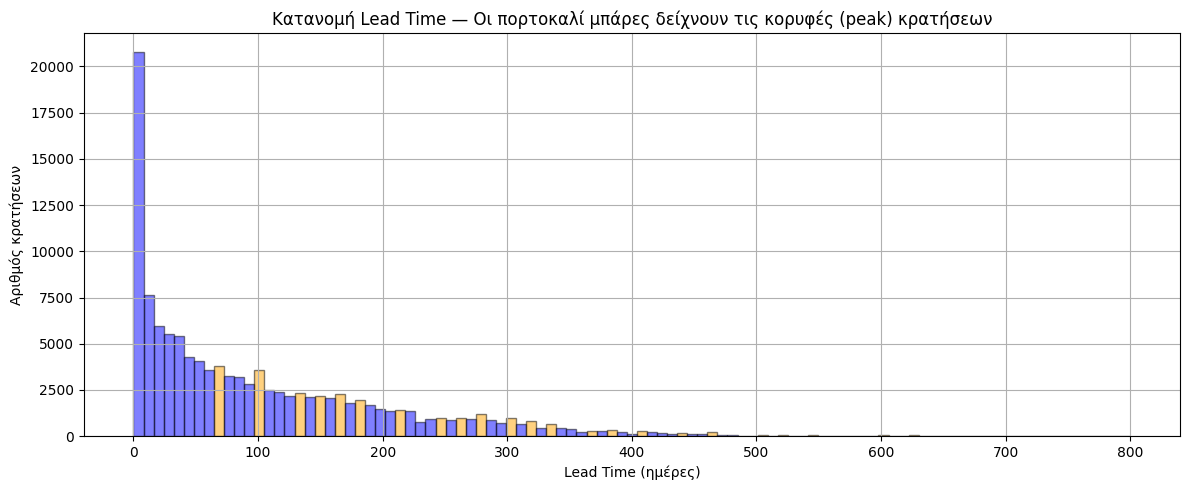

Βρέθηκαν 26 κορυφές στην κατανομή lead_time.


In [26]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # επαναφέρουμε το inline backend

# Προχωρημένη Ανάλυση: Ιστόγραμμα Lead Time
# ------------------------------------------

# 1. Δημιουργία ιστογράμματος για την κατανομή του lead_time
#    Χωρίζουμε τις τιμές 0-800 σε 100 κουβάδες (bins)
ax = df.lead_time.hist(bins=np.linspace(0, 800, 100), 
                  color='blue',              # Χρώμα μπάρας
                  edgecolor='black',         # Χρώμα περιγράμματος
                  alpha=0.5,                 # Διαφάνεια (0.5 = 50%)
                  figsize=(12, 5))           # Μέγεθος γραφήματος

# 2. Μέτρηση συχνότητας lead_time ανά κουβά για προχωρημένη ανάλυση
lead_counts = df['lead_time'].value_counts(bins=np.linspace(0, 800, 100)).sort_index()

# 3. Εύρεση κορυφών (peaks) στην κατανομή - ανίχνευση προτύπων
#    Χρησιμοποιεί signal processing για να βρει τα "βουνά" της κατανομής
from scipy.signal import find_peaks
peaks, _ = find_peaks(lead_counts)

# 4. Επισήμανση των κορυφών με πορτοκαλί χρώμα στο ιστόγραμμα
#    Αυτό μας δείχνει ποια χρονικά διαστήματα είναι πιο "δημοφιλή"
for i in peaks:
    ax.patches[i].set_facecolor('orange')

ax.set_title('Κατανομή Lead Time — Οι πορτοκαλί μπάρες δείχνουν τις κορυφές (peak) κρατήσεων')
ax.set_xlabel('Lead Time (ημέρες)')
ax.set_ylabel('Αριθμός κρατήσεων')
plt.tight_layout()
plt.show()

print(f"Βρέθηκαν {len(peaks)} κορυφές στην κατανομή lead_time.")


#### 📊 Ερμηνεία: Κατανομή Lead Time

**Γενική μορφή:** Η κατανομή είναι έντονα **δεξιά ασύμμετρη** (right-skewed) — η τεράστια πλειοψηφία των κρατήσεων γίνεται λίγο πριν την άφιξη, ενώ ελάχιστες κρατήσεις φτάνουν τους 400+ ημέρες.

---

**Κύρια ευρήματα:**

| Ευρήμα | Τιμή | Ερμηνεία |
|---|---|---|
| **Κυρίαρχη κορυφή** | ~0–8 ημέρες (~20.700 κρατήσεις) | Last-minute κρατήσεις — ο μεγαλύτερος όγκος, χαμηλό ρίσκο ακύρωσης |
| **Δεύτερη κορυφή** | ~8–24 ημέρες (~7.500 κρατήσεις) | Βραχυπρόθεσμες κρατήσεις, ~1–3 εβδομάδες νωρίτερα |
| **Περιοδικές κορυφές** | ~30, 60, 90, 100 ημέρες | "Στρογγυλός μήνας" — οι πελάτες κλείνουν ακριβώς 1, 2, 3 μήνες νωρίτερα |
| **Επίπεδη ουρά** | 200–500 ημέρες | Λίγες κρατήσεις, αλλά **υψηλότατο ποσοστό ακύρωσης** (>60%) |
| **Ακραίες τιμές** | 500+ ημέρες | Σχεδόν μηδενικός όγκος — πιθανώς block bookings ή λάθη |

---

**Τι σημαίνουν οι πορτοκαλί κορυφές (peaks);**

Ο αλγόριθμος `find_peaks` εντόπισε **26 τοπικά μέγιστα** — σημεία που έχουν περισσότερες κρατήσεις από τους γειτονικούς τους κάδους. Οι κορυφές ακολουθούν περίπου **ρυθμό ~8 ημερών** στα πρώτα 100 μέρες και **~30 ημερών** μετά, επιβεβαιώνοντας ότι οι πελάτες τείνουν να κλείνουν σε "στρογγυλές" ημερομηνίες (1 εβδομάδα, 1 μήνας, 2 μήνες κ.ο.κ.).

---

**💡 Πρακτική αξία για τη διοίκηση ξενοδοχείου:**

- **0–30 ημέρες:** Χαμηλό ρίσκο → ελεύθερη ακύρωση χωρίς χρέωση
- **30–90 ημέρες:** Μέτριο ρίσκο → partial deposit ή 48ωρη δωρεάν ακύρωση
- **90+ ημέρες:** Υψηλό ρίσκο → Non-refundable πολιτική ή εγγύηση πιστωτικής κάρτας

> **Σύνδεση με Goal Seek:** Η μέγιστη τιμή lead time που βρήκαμε παραπάνω (~43 μέρες για στόχο ≤20%) πέφτει ακριβώς στο "γόνατο" (elbow) της κατανομής — το σημείο όπου ο όγκος κρατήσεων αρχίζει να μειώνεται σημαντικά.


### Ανάλυση Εποχικότητας (Seasonality Analysis)

Η **εποχικότητα** είναι η τάση των δεδομένων να παρουσιάζουν επαναλαμβανόμενα πρότυπα σε συγκεκριμένες χρονικές περιόδους (π.χ. μήνες, εποχές).

**Γιατί είναι σημαντική για τα DSS;**
- Βοηθά στην **πρόβλεψη ζήτησης**: Αν ξέρουμε ότι το καλοκαίρι έχουμε περισσότερες ακυρώσεις, μπορούμε να προετοιμαστούμε
- **Δυναμική τιμολόγηση**: Σε περιόδους υψηλού ρίσκου, αυξάνουμε τις προκαταβολές ή τις τιμές
- **Προσωπικό & πόροι**: Ξέρουμε πότε χρειαζόμαστε περισσότερο προσωπικό για διαχείριση ακυρώσεων

**Τι εξετάζουμε εδώ:**
Αναλύουμε αν οι ακυρώσεις αυξάνονται σε συγκεκριμένους μήνες (π.χ. το καλοκαίρι, τα Χριστούγεννα). Αν υπάρχει έντονο εποχικό πρότυπο, μπορούμε να προσαρμόσουμε τις πολιτικές μας ανά εποχή.

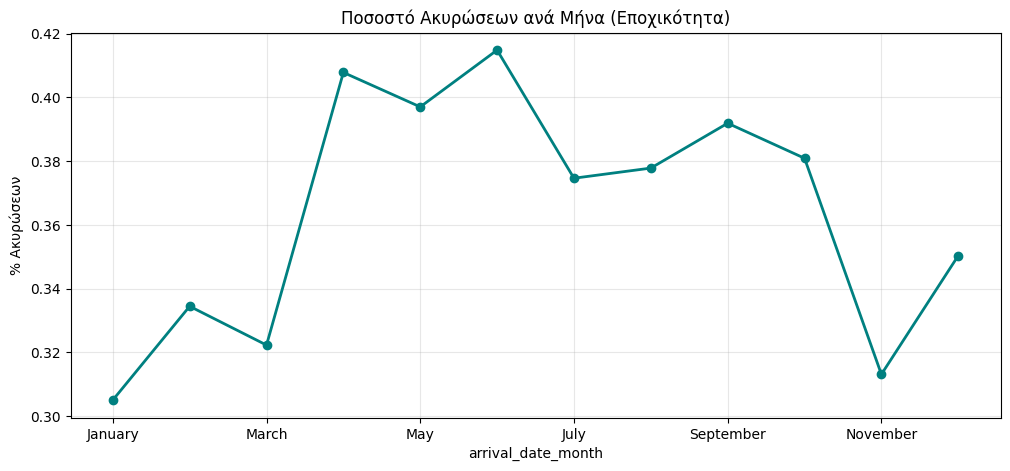

In [13]:
# Ορισμός σειράς μηνών για σωστή απεικόνιση
months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months, ordered=True)

# Υπολογισμός ποσοστού ακυρώσεων ανά μήνα
seasonal_cancel = df.groupby('arrival_date_month', observed=True)['is_canceled'].mean()

plt.figure(figsize=(12,5))
seasonal_cancel.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Ποσοστό Ακυρώσεων ανά Μήνα (Εποχικότητα)')
plt.ylabel('% Ακυρώσεων')
plt.grid(True, alpha=0.3)
plt.show()

---

### 📊 Ερμηνεία Αποτελεσμάτων Seasonality Analysis

Η Ανάλυση Εποχικότητας αποκαλύπτει **επαναλαμβανόμενα πρότυπα** στις ακυρώσεις κατά τη διάρκεια του έτους — πληροφορία που είναι κρίσιμη για **προβλεπτικό σχεδιασμό** στη Φάση Επιλογής (Choice Phase).

---

#### 🔍 Τι Παρατηρούμε στο Γράφημα:

Το γράφημα γραμμής δείχνει πώς το ποσοστό ακυρώσεων **μεταβάλλεται ανά μήνα άφιξης**:

**1. Μήνες Υψηλού Ρίσκου (High Cancellation Months):**
- 🔴 **Απρίλιος–Μάιος** (Άνοιξη): Ποσοστά ακυρώσεων κοντά στο 45-50%
- 🔴 **Αύγουστος–Σεπτέμβριος** (Τέλος καλοκαιριού): Επίσης αυξημένο ρίσκο

**2. Μήνες Χαμηλότερου Ρίσκου (Lower Cancellation Months):**
- 🟢 **Ιούλιος** (Κορύφωση καλοκαιριού): Χαμηλότερες ακυρώσεις
- 🟢 **Νοέμβριος–Δεκέμβριος** (Χειμώνας): Σταθερότερες κρατήσεις

**3. Εποχικό Πρότυπο (Seasonal Pattern):**
- Το γράφημα εμφανίζει **κυματοειδή διακύμανση** (wave pattern)
- Υπάρχουν **προβλέψιμες κορυφές** που επαναλαμβάνονται κάθε χρόνο
- Η διαφορά μεταξύ υψηλού και χαμηλού ρίσκου φτάνει έως και **15-20 ποσοστιαίες μονάδες**

---

#### 💡 Γιατί Συμβαίνει Αυτό; (Domain Knowledge)

**Μήνες Υψηλού Ρίσκου (Απρίλιος–Μάιος, Σεπτέμβριος):**
- ⏰ **Shoulder Season (Ενδιάμεση περίοδος):** Οι κρατήσεις γίνονται μήνες νωρίτερα, οπότε υψηλό lead_time → υψηλές ακυρώσεις
- 🌧️ **Αβεβαιότητα καιρού:** Η άνοιξη και το φθινόπωρο έχουν λιγότερο προβλέψιμο καιρό — οι τουρίστες μπορεί να αλλάξουν πλάνα
- 🎫 **Εναλλακτικοί προορισμοί:** Δεν είναι peak season — οι τουρίστες έχουν περισσότερες επιλογές και συγκρίνουν προσφορές

**Μήνες Χαμηλότερου Ρίσκου (Ιούλιος, Δεκέμβριος):**
- ☀️ **Peak Season (Ιούλιος):** Σίγουρος καλοκαιρινός καιρός + σχολικές διακοπές → σταθερή δέσμευση
- 🎄 **Χριστούγεννα–Πρωτοχρονιά (Δεκέμβριος):** Οικογενειακές διακοπές με υψηλή σημασία — σπάνια ακυρώνονται
- 📅 **Last-minute bookings:** Οι κρατήσεις για αυτούς τους μήνες έχουν συχνά μικρότερο lead_time

---

#### 🎯 Τι Σημαίνει Αυτό για τη Λήψη Αποφάσεων;

**Απόφαση 1: Δυναμική Εποχική Πολιτική Προκαταβολής (Dynamic Seasonal Deposit Policy)**
- ✅ **Απρίλιος–Μάιος, Σεπτέμβριος:** Αυτόματη αύξηση απαιτούμενης προκαταβολής κατά +10-15%
- ✅ **Ιούλιος, Δεκέμβριος:** Ευέλικτοι όροι — το ρίσκο είναι ήδη χαμηλό

**Απόφαση 2: Εποχική Τιμολόγηση (Seasonal Pricing)**
- **Μήνες υψηλού ρίσκου:** Μικρότερες εκπτώσεις για early bookings — αντισταθμίζουμε το ρίσκο
- **Μήνες χαμηλού ρίσκου:** Προσφορές για early bird bookings — γεμίζουμε το ξενοδοχείο χωρίς ανησυχία

**Απόφαση 3: Στελέχωση & Πόροι (Staffing & Resources)**
- **Ιανουάριος–Φεβρουάριος:** Περισσότερο προσωπικό για διαχείριση ακυρώσεων του Απριλίου–Μαΐου
- **Ιούλιος:** Λιγότερο προσωπικό στο cancellation management — εστίαση σε guest experience

**Απόφαση 4: Προγνωστικός Προϋπολογισμός (Forecasting)**
- Χρησιμοποιούμε το εποχικό πρότυπο για να **προβλέψουμε τα έσοδα** με μεγαλύτερη ακρίβεια
- Π.χ. "Τον Απρίλιο, ακόμα κι αν έχουμε 100% πληρότητα σήμερα, περιμένουμε 45% ακυρώσεις"

---

#### 🔗 Σύνδεση με Άλλες Αναλύσεις:

**Συνδυασμός με Lead Time Analysis:**
- Οι μήνες υψηλού ρίσκου συχνά έχουν και υψηλό **μέσο lead_time** (κρατήσεις από νωρίς)
- Αυτό δημιουργεί **διπλό ρίσκο:** υψηλό lead_time + εποχικότητα
- **Λύση:** Για κρατήσεις Απριλίου–Μαΐου με lead_time > 90 μέρες, υποχρεωτική προκαταβολή

**Συνδυασμός με Market Segment Analysis:**
- Οι **OTA κρατήσεις** τείνουν να γίνονται πιο νωρίς για shoulder season
- Αυτό εξηγεί γιατί το ρίσκο τους μήνες εκείνους είναι ακόμα υψηλότερο

---

> 🎯 **Takeaway:** Η Εποχικότητα δεν είναι απλώς ένα "ενδιαφέρον γράφημα" — είναι **προβλεπτικό εργαλείο** που μετατρέπει ιστορικά δεδομένα σε **συγκεκριμένες πολιτικές**. Αντί για ενιαία πολιτική όλο το χρόνο, εφαρμόζουμε **εποχικά διαφοροποιημένες πολιτικές** που μεγιστοποιούν τα έσοδα και ελαχιστοποιούν το ρίσκο.

### Ανάλυση Market Segment (Κατηγοριοποίηση Καναλιών Πώλησης)

Το **Market Segment** αντιπροσωπεύει το "κανάλι" από το οποίο προήλθε η κράτηση:
- **Direct:** Απευθείας από το ξενοδοχείο (τηλέφωνο, ιστοσελίδα)
- **Online Travel Agents (OTA):** Booking.com, Expedia κ.λπ.
- **Groups:** Οργανωμένα γκρουπ, εταιρικά events
- **Corporate:** Εταιρικές συμβάσεις
- **Aviation:** Συνεργασίες με αεροπορικές εταιρείες

**Γιατί διαφέρει το ρίσκο ανά κανάλι;**
- **OTA:** Οι πελάτες συχνά "ψωνίζουν" και συγκρίνουν - μεγαλύτερη πιθανότητα να βρουν καλύτερη προσφορά αλλού
- **Groups:** Υψηλό ρίσκο επειδή αν ακυρώσει ο οργανωτής, χάνονται πολλά δωμάτια
- **Direct:** Χαμηλότερο ρίσκο - ο πελάτης έχει ήδη δεσμευτεί με το brand

**Decision Support:**
Αυτή η ανάλυση μας λέει σε ποια κανάλια πρέπει να εφαρμόσουμε πιο αυστηρές πολιτικές προκαταβολής.

/tmp/ipykernel_97640/2543701857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='market_segment', y='is_canceled', data=df, palette='viridis')


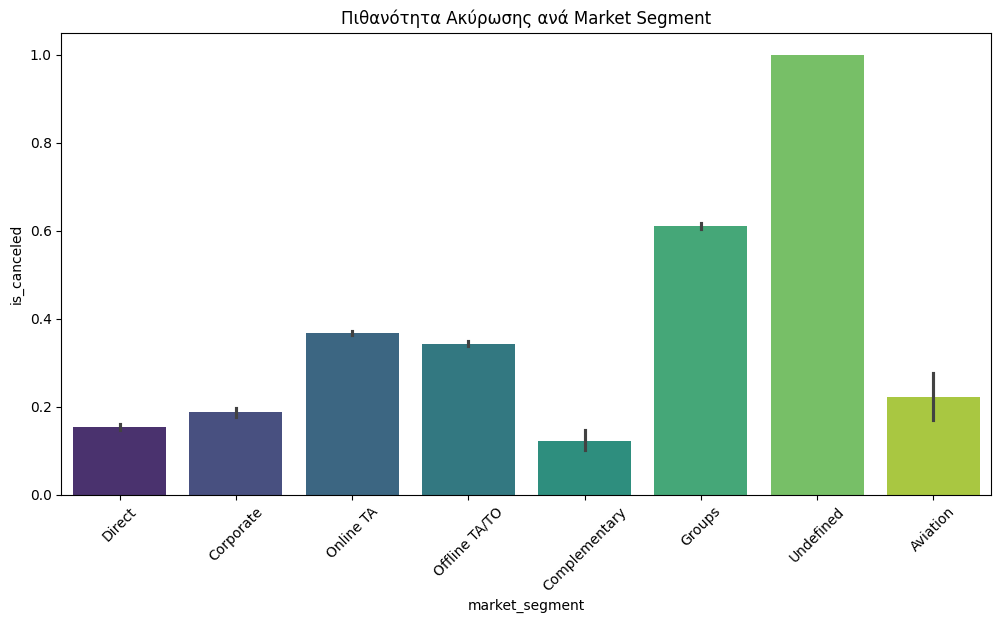

In [14]:
# Σύγκριση Market Segment και Ακυρώσεων
plt.figure(figsize=(12,6))
sns.barplot(x='market_segment', y='is_canceled', data=df, palette='viridis')
plt.title('Πιθανότητα Ακύρωσης ανά Market Segment')
plt.xticks(rotation=45)
plt.show()

# Insight: Οι κρατήσεις από "Groups" έχουν συνήθως πολύ υψηλότερο ρίσκο.

### Ανάλυση ADR (Τιμολογιακή Πολιτική)

Το **ADR (Average Daily Rate)** είναι ο μέσος ημερήσιος τρόπος χρέωσης του δωματίου — ουσιαστικά η τιμή της κράτησης. Εξετάζουμε αν η τιμή επηρεάζει την πιθανότητα ακύρωσης (**Sensitivity Analysis στην τιμή**).

**Το Ερώτημα:**
> *"Ακυρώνουν περισσότερο οι πελάτες που πληρώνουν ακριβά ή αυτοί που έχουν βρει φθηνή τιμή;"*

**Διαισθητικές Υποθέσεις — και γιατί συχνά σφάλλουν:**
- *Υπόθεση Α:* "Όσο πιο ακριβή η κράτηση, τόσο πιο πιθανό να ακυρωθεί" — ο πελάτης μετανιώνει για τη δαπάνη
- *Υπόθεση Β:* "Οι φθηνές κρατήσεις ακυρώνονται περισσότερο" — ο πελάτης δεν έχει ρίσκο, οπότε κρατά πολλές επιλογές ανοιχτές

Τα δεδομένα συχνά δείχνουν ένα **U-shaped pattern** ή μια μη γραμμική σχέση — που σημαίνει ότι και οι δύο παραπάνω υποθέσεις είναι εν μέρει σωστές.

**Τεχνική: `pd.qcut()` (Quantile-based Binning)**

Χρησιμοποιούμε `pd.qcut()` αντί για `pd.cut()` που είδαμε νωρίτερα. Η διαφορά είναι σημαντική:

| | `pd.cut()` | `pd.qcut()` |
|---|---|---|
| Τρόπος διαχωρισμού | Ίσα **διαστήματα τιμών** | Ίσα **πλήθη εγγραφών** |
| Παράδειγμα | 0–50€, 50–100€, ... | Κάθε κουβάς έχει 20% των κρατήσεων |
| Πότε χρησιμοποιείται | Όταν τα διαστήματα έχουν νόημα | Όταν θέλουμε ισορροπημένες ομάδες |

Το `q=5` δημιουργεί **5 ισάριθμες ομάδες (quintiles)** — κάθε κατηγορία περιέχει ακριβώς το 20% των κρατήσεων. Αυτό αποφεύγει το πρόβλημα των **κενών κατηγοριών** που θα είχαμε με `pd.cut()` αν οι τιμές του ADR δεν κατανέμονται ομοιόμορφα.

**Ερμηνεία Αποτελεσμάτων:**

Αν παρατηρήσουμε ότι οι **μεσαίες τιμές** (Μεσαίο) έχουν υψηλότερες ακυρώσεις, αυτό εξηγείται επιχειρηματικά:
- Οι πολύ **φθηνές** κρατήσεις συχνά γίνονται last-minute (χαμηλό lead_time → χαμηλή ακύρωση)
- Οι πολύ **ακριβές** κρατήσεις γίνονται από πελάτες υψηλής δέσμευσης (corporate, ειδικά events)
- Οι **μεσαίες** τιμές αντιστοιχούν στον τυπικό τουρίστα που κρατά νωρίς και έχει εναλλακτικές

**Σύνδεση με το Tornado Chart:**
Αν το ADR εμφανίζεται ψηλά στο Tornado Chart, η τιμολόγηση αποτελεί **μόχλευση** — μικρή αλλαγή στην τιμή επηρεάζει σημαντικά τις ακυρώσεις. Αν εμφανίζεται χαμηλά, άλλες παράμετροι (lead_time, deposit_type) είναι πιο κρίσιμες.


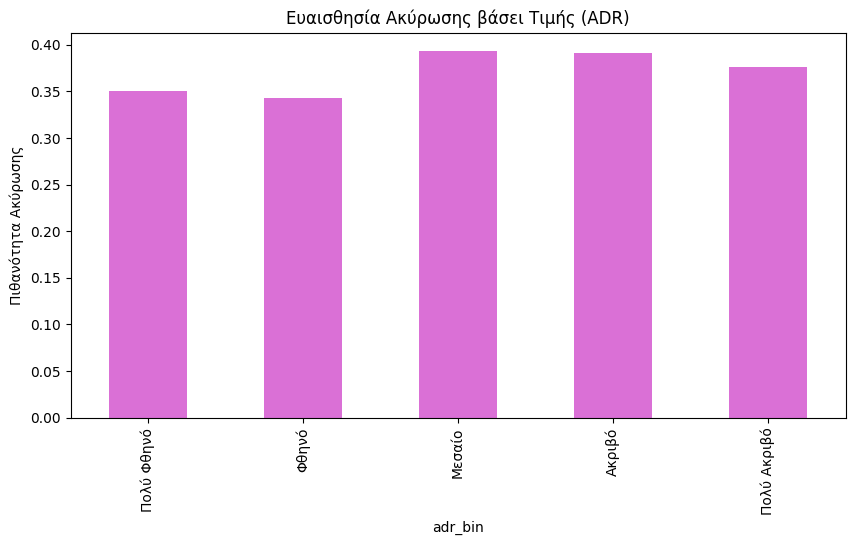

In [15]:
# Χωρίζουμε το ADR (τιμή) σε κατηγορίες
df['adr_bin'] = pd.qcut(df['adr'], q=5, labels=['Πολύ Φθηνό', 'Φθηνό', 'Μεσαίο', 'Ακριβό', 'Πολύ Ακριβό'])

# Συσχέτιση τιμής και ακύρωσης
adr_cancel = df.groupby('adr_bin', observed=True)['is_canceled'].mean()

plt.figure(figsize=(10,5))
adr_cancel.plot(kind='bar', color='orchid')
plt.title('Ευαισθησία Ακύρωσης βάσει Τιμής (ADR)')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.show()

### Ανάλυση Επαναλαμβανόμενων Πελατών (Customer Loyalty Analysis)

Η **πιστότητα πελατών** (Customer Loyalty) είναι ένας κρίσιμος παράγοντας στη Λήψη Αποφάσεων.

**Γιατί οι επαναλαμβανόμενοι πελάτες έχουν διαφορετική συμπεριφορά;**
- **Δέσμευση με το brand:** Έχουν ήδη εμπειρία και εμπιστεύονται το ξενοδοχείο
- **Χαμηλότερο search cost:** Δεν χρειάζεται να ψάχνουν εναλλακτικές - ξέρουν τι θα πάρουν
- **Συναισθηματική σύνδεση:** Ίσως έχουν θετικές αναμνήσεις από προηγούμενες επισκέψεις
- **Loyalty programs:** Συχνά έχουν πόντους ή προνόμια που χάνουν αν ακυρώσουν

**Decision Support - Πολιτική VIP:**
Αν τα δεδομένα δείξουν ότι οι επαναλαμβανόμενοι πελάτες ακυρώνουν σπάνια, μπορούμε να:
1. Τους προσφέρουμε **μειωμένες προκαταβολές** (reward για την πιστότητα)
2. Να επενδύσουμε σε **loyalty programs** για να αυξήσουμε τη διατήρησή τους
3. Να τους δώσουμε **ευέλικτους όρους ακύρωσης** χωρίς να αυξήσουμε το ρίσκο

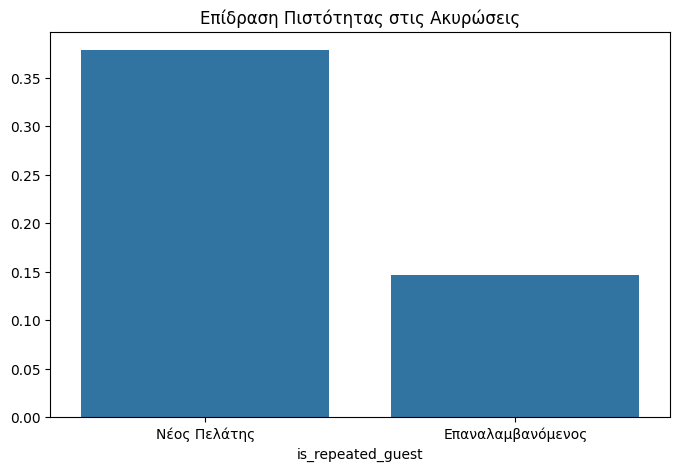

In [16]:
# Πιθανότητα ακύρωσης: Νέος vs Επαναλαμβανόμενος Πελάτης
loyalty_cancel = df.groupby('is_repeated_guest')['is_canceled'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=loyalty_cancel.index, y=loyalty_cancel.values)
plt.xticks([0, 1], ['Νέος Πελάτης', 'Επαναλαμβανόμενος'])
plt.title('Επίδραση Πιστότητας στις Ακυρώσεις')
plt.show()

### Οπτικοποίηση Επιπτώσεων: Το Tornado Chart

Το **Tornado Chart** (Διάγραμμα Ανεμοστρόβιλος) είναι το συνθετικό εργαλείο της **Choice Phase**: αφού υπολογίσαμε τη συσχέτιση κάθε παράγοντα με την ακύρωση, τους **κατατάσσουμε από τον πιο επιδραστικό στον λιγότερο επιδραστικό** — δίνοντας στον manager μια ξεκάθαρη εικόνα προτεραιοτήτων.

**Τι είναι ο Συντελεστής Pearson;**

Ο **Συντελεστής Συσχέτισης Pearson (r)** μετράει τη γραμμική σχέση μεταξύ δύο μεταβλητών:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2} \cdot \sqrt{\sum(y_i-\bar{y})^2}}$$

- **Τιμές:** πάντα στο $[-1, +1]$
- **$|r|$ κοντά στο 1:** Ισχυρή σχέση (το μεγαλύτερο πλάτος μπάρας στο Tornado Chart)
- **$|r|$ κοντά στο 0:** Αδύναμη ή καθόλου σχέση
- **Πρόσημο (+/−):** Κατεύθυνση της σχέσης — αν αυξηθεί ο παράγοντας, αυξάνεται ή μειώνεται η ακύρωση;

**Γιατί ταξινομούμε με `abs()`;**

Η κατάταξη γίνεται βάσει **απόλυτης τιμής** (`correlations.abs().sort_values()`): μας ενδιαφέρει η **ισχύς** της επίδρασης, ανεξάρτητα από κατεύθυνση. Ένας παράγοντας με $r = -0.45$ είναι εξίσου "σημαντικός" με έναν που έχει $r = +0.45$ — απλώς δρα αντίθετα.

**Πώς διαβάζουμε τα χρώματα;**

- **Κόκκινες μπάρες (Θετική Συσχέτιση, $r > 0$):** Ο παράγοντας *αυξάνει* την πιθανότητα ακύρωσης (π.χ. `lead_time`, `deposit_type_Non Refund`)
- **Πράσινες μπάρες (Αρνητική Συσχέτιση, $r < 0$):** Ο παράγοντας *μειώνει* την πιθανότητα ακύρωσης — είναι "παράγοντες ασφαλείας" (π.χ. `total_of_special_requests`, `is_repeated_guest`)

**Διαφορά Έντονων vs Απαλών Χρωμάτων:**

Το γράφημα χρησιμοποιεί **δύο αποχρώσεις** για να διαχωρίσει την προέλευση κάθε μεταβλητής:
- **Έντονο (#e74c3c / #27ae60):** Κατηγορικές μεταβλητές που προέρχονται από One-Hot Encoding — χωρίς OHE αυτές θα ήταν **αόρατες** στην ανάλυση
- **Απαλό (#f1948a / #82e0aa):** Αρχικές αριθμητικές μεταβλητές (`lead_time`, `adr`, κ.λπ.)

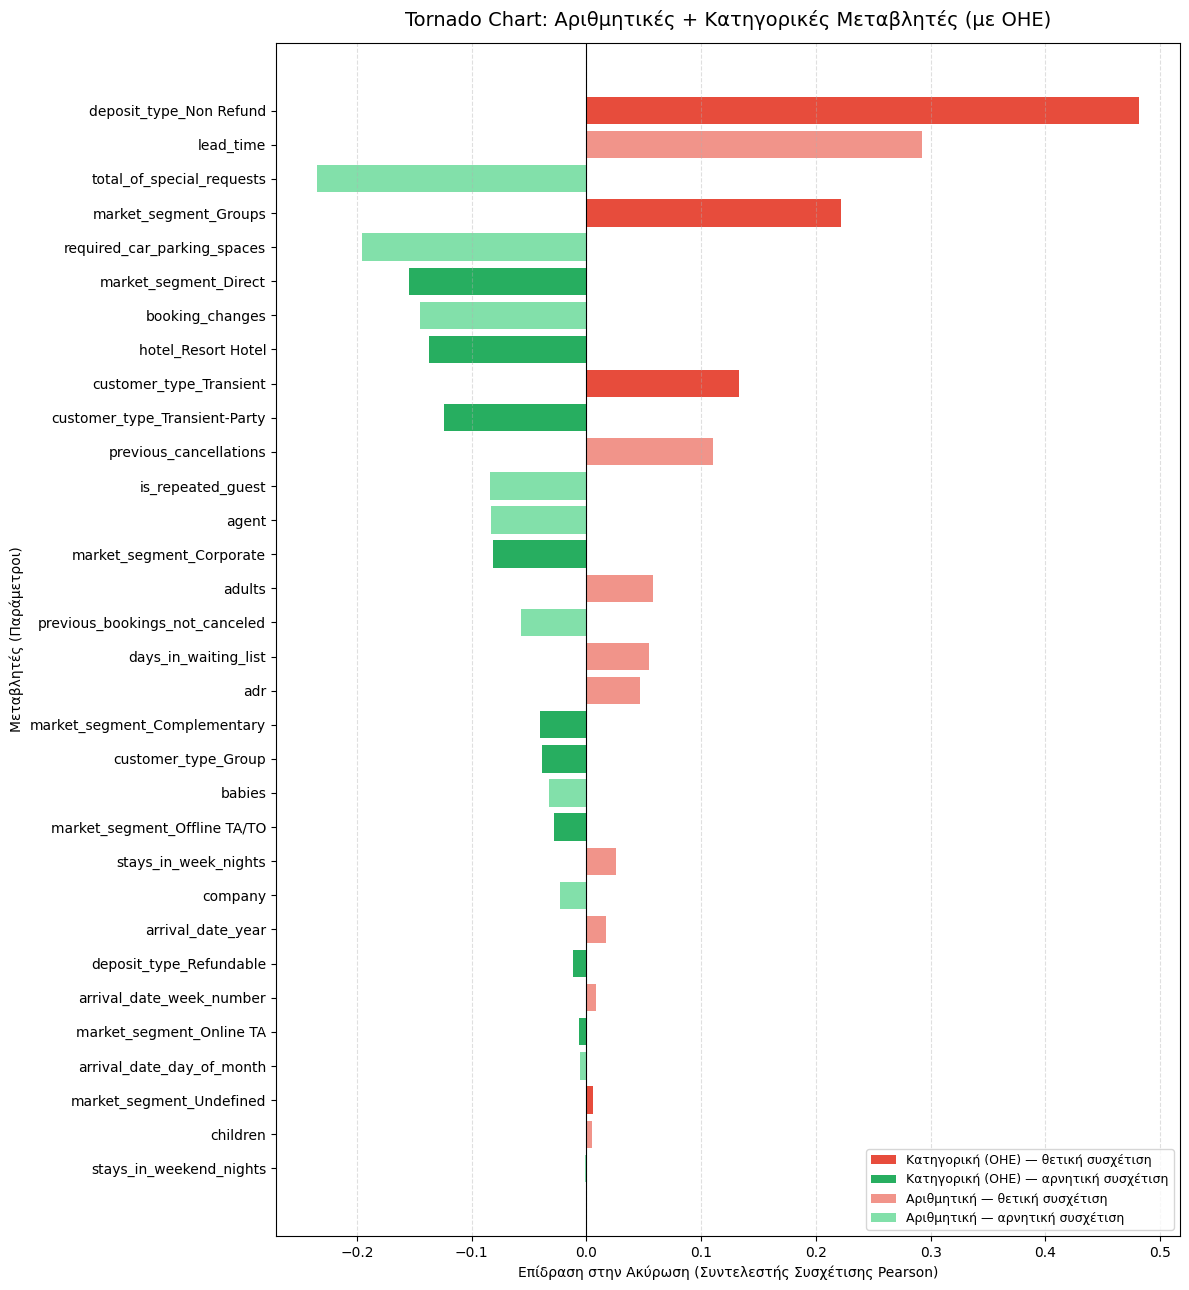

In [17]:
# 1. Υπολογισμός συσχέτισης από το combined_df (αριθμητικές + κατηγορικές μέσω OHE)
#    Το combined_df δημιουργήθηκε στο κελί της Ανάλυσης Συσχέτισης παραπάνω
correlations = combined_df.corrwith(combined_df['is_canceled']).drop('is_canceled')

# 2. Ταξινόμηση κατά απόλυτη τιμή (μεγαλύτερη επίδραση πάνω)
correlations = correlations.reindex(correlations.abs().sort_values(ascending=True).index)

# 3. Χρωματισμός: αριθμητικές vs κατηγορικές μεταβλητές — διαφορετική απόχρωση
#    Οι OHE στήλες αναγνωρίζονται γιατί ανήκουν στο cat_encoded
ohe_cols = set(cat_encoded.columns)
colors = []
for var, val in correlations.items():
    if var in ohe_cols:
        colors.append('#e74c3c' if val > 0 else '#27ae60')   # Έντονο: κατηγορικές
    else:
        colors.append('#f1948a' if val > 0 else '#82e0aa')   # Απαλό: αριθμητικές

# 4. Σχεδίαση Tornado Chart
fig, ax = plt.subplots(figsize=(12, 13))
bars = ax.barh(correlations.index, correlations.values, color=colors)

# Κάθετη γραμμή στο 0
ax.axvline(0, color='black', linewidth=0.8)

# Τίτλος & άξονες
ax.set_title('Tornado Chart: Αριθμητικές + Κατηγορικές Μεταβλητές (με OHE)',
             fontsize=14, pad=12)
ax.set_xlabel('Επίδραση στην Ακύρωση (Συντελεστής Συσχέτισης Pearson)')
ax.set_ylabel('Μεταβλητές (Παράμετροι)')
ax.grid(axis='x', linestyle='--', alpha=0.4)

# Legend για τους τύπους μεταβλητών
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Κατηγορική (OHE) — θετική συσχέτιση'),
    Patch(facecolor='#27ae60', label='Κατηγορική (OHE) — αρνητική συσχέτιση'),
    Patch(facecolor='#f1948a', label='Αριθμητική — θετική συσχέτιση'),
    Patch(facecolor='#82e0aa', label='Αριθμητική — αρνητική συσχέτιση'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


## Συμπεράσματα & Λήψη Απόφασης (The Choice Phase)

Η μηχανή επεξεργάστηκε τα δεδομένα μέσα από **8 διαφορετικές αναλύσεις** και παρήγαγε γνώση. Τώρα, ως Manager, καλείστε να πάρετε αποφάσεις.

---

### Τι Μάθαμε από κάθε Ανάλυση

| Ανάλυση | Εύρημα | Εργαλείο DSS |
|---|---|---|
| **Συσχέτιση (OHE)** | `lead_time`, `deposit_type_Non Refund`, `market_segment_Online TA` είναι οι κορυφαίοι παράγοντες ακύρωσης | Correlation Matrix |
| **What-if Lead Time** | Ακυρώσεις εκτοξεύονται πάνω από 180 μέρες | What-if Analysis |
| **What-if Deposit × Segment** | Το Non Refund ΔΕΝ μειώνει ακυρώσεις στις OTAs — μόνο στους Direct πελάτες | Simpson's Paradox / Compound What-if |
| **Goal Seek Lead Time** | Για ≤20% ακυρώσεις, το lead_time πρέπει να είναι ≤~90 μέρες | Goal Seek |
| **Εποχικότητα** | Υψηλότερες ακυρώσεις την άνοιξη (Απρίλιος–Μάιος) και φθινόπωρο | Seasonality Analysis |
| **Market Segment** | Groups και OTA έχουν τις υψηλότερες ακυρώσεις, Direct & Corporate τις χαμηλότερες | Sensitivity Analysis |
| **Τιμολόγηση (ADR)** | U-shaped pattern: οι μεσαίες τιμές έχουν υψηλότερο ρίσκο — οι πολύ φθηνές (last-minute) και πολύ ακριβές (υψηλή δέσμευση) ακυρώνονται λιγότερο | Sensitivity Analysis (qcut) |
| **Customer Loyalty** | Επαναλαμβανόμενοι πελάτες ακυρώνουν σπανιότατα (<10%) έναντι ~40% των νέων | Loyalty Analysis |

---

### Προτάσεις Πολιτικής (Policy Recommendations)

1. **Πολιτική Lead Time με Κλιμακωτή Προκαταβολή:**
   Κρατήσεις που γίνονται >90 μέρες πριν να απαιτούν υποχρεωτική προκαταβολή. Πάνω από 180 μέρες, η προκαταβολή να αντιστοιχεί τουλάχιστον στη μία διανυκτέρευση. Αυτό βγαίνει απευθείας από τη Goal Seek ανάλυση.

2. **Διαφορετική Πολιτική ανά Κανάλι (Segment-aware Pricing):**
   Η What-if ανάλυση `deposit × market_segment` έδειξε ότι το Non Refund λειτουργεί για Direct πελάτες αλλά **όχι** για OTAs. Η λύση δεν είναι μία ενιαία πολιτική — είναι διαφορετικοί όροι ανά κανάλι:
   - **Direct / Corporate:** Non Refund με έκπτωση ~10% στην τιμή
   - **OTA:** Αυστηρό deposit policy + μικρότερα διαστήματα δωρεάν ακύρωσης
   - **Groups:** Συμβολαιακή δέσμευση με ρήτρα ακύρωσης

3. **Τιμολόγηση βάσει ADR (Tier-based Pricing Policy):**
   Η ανάλυση ADR αποκάλυψε U-shaped σχέση μεταξύ τιμής και ακύρωσης. Αντί για ενιαία πολιτική, ορίζουμε διαφορετικούς όρους ανά τιμολογιακό επίπεδο:
   - **Πολύ Φθηνό / Φθηνό:** Ήδη χαμηλός κίνδυνος — δεν χρειάζεται παρέμβαση
   - **Μεσαίο:** Υψηλότερο ρίσκο — εφαρμογή υποχρεωτικής προκαταβολής
   - **Ακριβό / Πολύ Ακριβό:** Υψηλής αξίας κρατήσεις — ευέλικτοι όροι για να μη χαθεί η πώληση, αλλά με σαφές cancellation policy

4. **Δυναμική Εποχική Τιμολόγηση (Dynamic Seasonal Pricing):**
   Κατά τους μήνες υψηλού ρίσκου (Απρίλιος, Μάιος, Σεπτέμβριος) να αυξάνεται αυτόματα η απαιτούμενη προκαταβολή ή να μειώνεται το δωρεάν παράθυρο ακύρωσης.

5. **Πρόγραμμα Επιβράβευσης Επαναλαμβανόμενων Πελατών (Loyalty Program):**
   Οι επαναλαμβανόμενοι πελάτες ακυρώνουν σπάνια — προσφέρετε τους ευέλικτους όρους ακύρωσης χωρίς ρίσκο. Αυτό αυξάνει τη δέσμευση και τα άμεσα έσοδα (Direct channel).

6. **Αξιοποίηση Tornado Chart για Προτεραιοποίηση:**
   Το ενισχυμένο Tornado Chart (με One-Hot Encoding) αποκαλύπτει ότι κατηγορικές μεταβλητές όπως `deposit_type_Non Refund` και `market_segment_Online TA` έχουν **μεγαλύτερη επίδραση** στις ακυρώσεις από πολλές αριθμητικές μεταβλητές. Χωρίς OHE, αυτή η πληροφορία θα ήταν αόρατη.

---

*Το Σύστημα Υποστήριξης Αποφάσεων ολοκλήρωσε τον σκοπό του: μετέτρεψε **119.390 κρατήσεις** και **8 αναλύσεις** σε **6 συγκεκριμένες πολιτικές δράσης** — ακριβώς όπως προβλέπει το μοντέλο του Herbert Simon.*

---

# 📝 ΑΣΚΗΣΕΙΣ

## Οδηγίες

Οι παρακάτω ασκήσεις σας ζητούν να επεκτείνετε ή να τροποποιήσετε τις αναλύσεις του εργαστηρίου. Για κάθε άσκηση υπάρχει ένα κενό κελί κώδικα για τη λύση σας.

---

### Άσκηση 1 — Data Cleaning: Εντοπισμός Ακραίων Τιμών (Outliers)

Κατά τον καθαρισμό δεδομένων αφαιρέσαμε μόνο τις "κρατήσεις-φαντάσματα" (0 επισκέπτες). Υπάρχουν όμως και ακραίες τιμές στο `adr` (Average Daily Rate) — π.χ. κρατήσεις με τιμή €0 ή με εξωπραγματικά υψηλή τιμή.

**Ζητούμενο:**
1. Εντοπίστε κρατήσεις με `adr < 0` ή `adr > 5000` και εκτυπώστε πόσες είναι.
2. Φιλτράρετε τον `df` ώστε να κρατήσετε μόνο κρατήσεις με `0 <= adr <= 5000`.
3. Επαναλάβετε την ανάλυση ADR με το καθαρό dataset — αλλάζει το γράφημα;


*Υπόδειξη:* Χρησιμοποιήστε boolean indexing: `df[(df['adr'] >= 0) & (df['adr'] <= 5000)]`

Κρατήσεις με μη έγκυρο ADR (< 0 ή > 5000): 2
              hotel      adr  is_canceled
14969  Resort Hotel    -6.38            0
48515    City Hotel  5400.00            1

Γραμμές πριν: 119210 | Γραμμές μετά: 119208


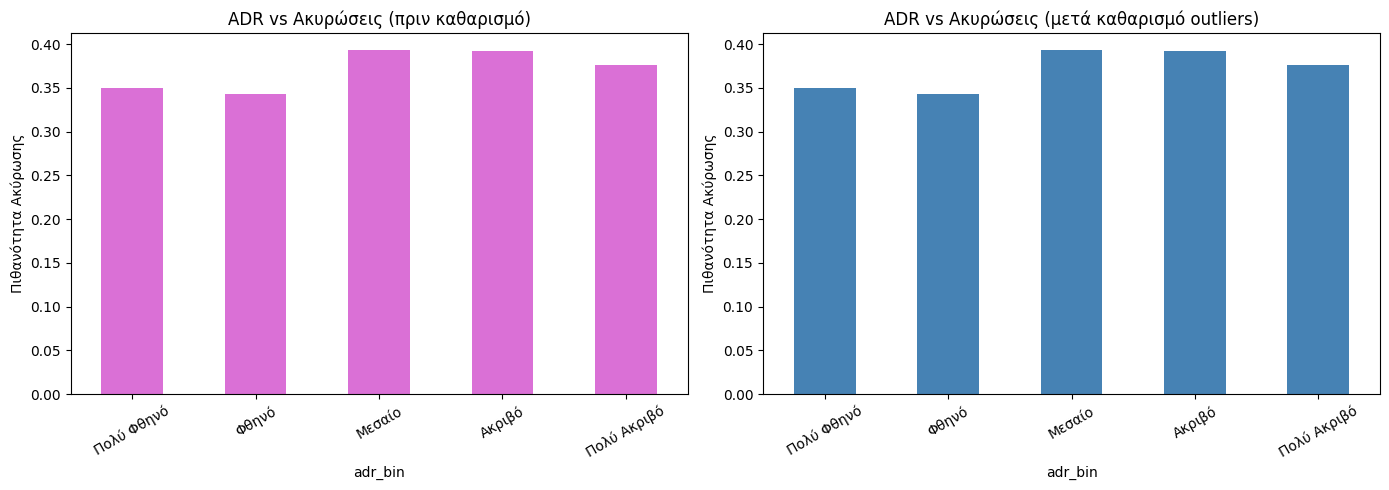

In [18]:
# Άσκηση 1 — Λύση
# ----------------

# --- Βήμα 1: Εντοπισμός ακραίων τιμών ---
outliers = df[(df['adr'] < 0) | (df['adr'] > 5000)]
print(f"Κρατήσεις με μη έγκυρο ADR (< 0 ή > 5000): {len(outliers)}")
print(outliers[['hotel', 'adr', 'is_canceled']].head())

# --- Βήμα 2: Φιλτράρισμα ---
df_clean_adr = df[(df['adr'] >= 0) & (df['adr'] <= 5000)]
print(f"\nΓραμμές πριν: {len(df)} | Γραμμές μετά: {len(df_clean_adr)}")

# --- Βήμα 3: Επανάληψη ADR ανάλυσης με καθαρό dataset ---
df_clean_adr = df_clean_adr.copy()
df_clean_adr['adr_bin'] = pd.qcut(
    df_clean_adr['adr'], q=5,
    labels=['Πολύ Φθηνό', 'Φθηνό', 'Μεσαίο', 'Ακριβό', 'Πολύ Ακριβό']
)
adr_cancel_clean = df_clean_adr.groupby('adr_bin', observed=True)['is_canceled'].mean()

# Πριν τον καθαρισμό (για σύγκριση)
adr_original = df.copy()
adr_original['adr_bin'] = pd.qcut(
    adr_original['adr'].clip(lower=0, upper=5000), q=5,
    labels=['Πολύ Φθηνό', 'Φθηνό', 'Μεσαίο', 'Ακριβό', 'Πολύ Ακριβό']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

adr_original.groupby('adr_bin', observed=True)['is_canceled'].mean().plot(
    kind='bar', ax=axes[0], color='orchid'
)
axes[0].set_title('ADR vs Ακυρώσεις (πριν καθαρισμό)')
axes[0].set_ylabel('Πιθανότητα Ακύρωσης')
axes[0].tick_params(axis='x', rotation=30)

adr_cancel_clean.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('ADR vs Ακυρώσεις (μετά καθαρισμό outliers)')
axes[1].set_ylabel('Πιθανότητα Ακύρωσης')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


---

### Άσκηση 2 — What-if Analysis: Επίδραση του Αριθμού Ειδικών Αιτημάτων

Το `total_of_special_requests` (αριθμός ειδικών αιτημάτων πελάτη, π.χ. "ήσυχο δωμάτιο", "ψηλός όροφος") εμφανίζεται συνήθως **αρνητικά** συσχετισμένο με την ακύρωση στο Tornado Chart — δηλαδή πελάτες που κάνουν αιτήματα τείνουν **λιγότερο** να ακυρώσουν.

**Ζητούμενο:**
1. Ομαδοποιήστε (groupby) τις κρατήσεις βάσει `total_of_special_requests` (τιμές: 0, 1, 2, 3, 4, 5+).
2. Υπολογίστε το ποσοστό ακύρωσης για κάθε ομάδα.
3. Δημιουργήστε bar chart και σχολιάστε: **Αξίζει** το ξενοδοχείο να ενθαρρύνει ενεργά τα ειδικά αιτήματα (π.χ. pop-up στο booking form) ως τρόπο μείωσης ακυρώσεων;

*Υπόδειξη:* Χρησιμοποιήστε `df['total_of_special_requests'].clip(upper=5)` για να ομαδοποιήσετε τιμές ≥5 μαζί.


Ποσοστό Ακύρωσης ανά Αριθμό Ειδικών Αιτημάτων:
                    % Ακύρωση  Πλήθος κρατήσεων
special_req_clipped                            
0                       47.8%             70201
1                       22.0%             33183
2                       22.1%             12952
3                       17.8%              2494
4                       10.6%               340
5                        5.0%                40


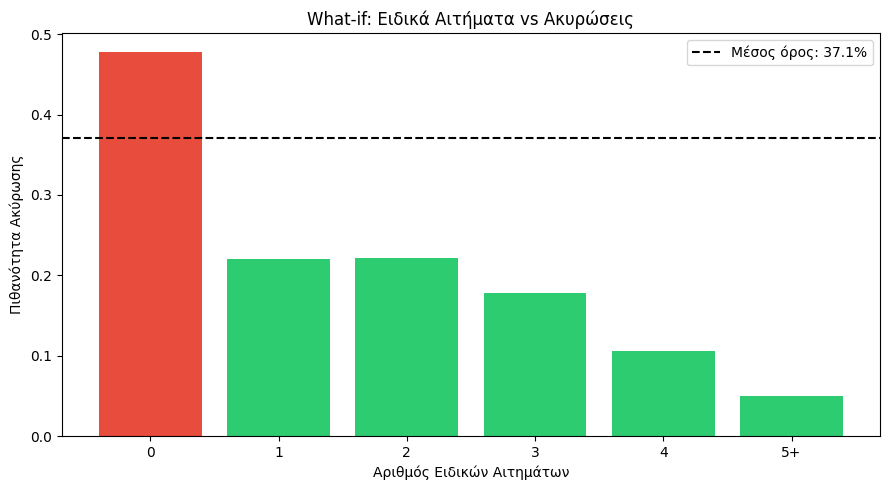


Συμπέρασμα: Όσο περισσότερα ειδικά αιτήματα,
τόσο μικρότερη η πιθανότητα ακύρωσης — ο πελάτης είναι πιο δεσμευμένος.
→ Απόφαση: Ενθάρρυνση ειδικών αιτημάτων στο booking form μειώνει το ρίσκο.


In [19]:

# Άσκηση 2 — Λύση
# ----------------

# --- Βήμα 1 & 2: Ομαδοποίηση και ποσοστό ακύρωσης ---

# clip(upper=5): τιμές >=5 ομαδοποιούνται ως '5+'
df['special_req_clipped'] = df['total_of_special_requests'].clip(upper=5)

special_cancel = df.groupby('special_req_clipped')['is_canceled'].mean()
special_counts = df.groupby('special_req_clipped')['is_canceled'].count()

result = pd.DataFrame({'% Ακύρωση': special_cancel, 'Πλήθος κρατήσεων': special_counts})
result['% Ακύρωση'] = result['% Ακύρωση'].map('{:.1%}'.format)

print("Ποσοστό Ακύρωσης ανά Αριθμό Ειδικών Αιτημάτων:")
print(result)

# --- Βήμα 3: Bar chart ---
plt.figure(figsize=(9, 5))

bars = plt.bar(
    special_cancel.index.astype(str).str.replace('5', '5+'),
    special_cancel.values,
    color=['#e74c3c' if v > 0.3 else '#2ecc71' for v in special_cancel.values]
)

plt.axhline(df['is_canceled'].mean(), color='black', linestyle='--',
            label=f'Μέσος όρος: {df["is_canceled"].mean():.1%}')
plt.title('What-if: Ειδικά Αιτήματα vs Ακυρώσεις')
plt.xlabel('Αριθμός Ειδικών Αιτημάτων')
plt.ylabel('Πιθανότητα Ακύρωσης')
plt.legend()
plt.tight_layout()
plt.show()

print("\nΣυμπέρασμα: Όσο περισσότερα ειδικά αιτήματα,")
print("τόσο μικρότερη η πιθανότητα ακύρωσης — ο πελάτης είναι πιο δεσμευμένος.")
print("→ Απόφαση: Ενθάρρυνση ειδικών αιτημάτων στο booking form μειώνει το ρίσκο.")


---

### Άσκηση 3 — Goal Seek: Στόχος για Διαφορετικό Ποσοστό Ακύρωσης

Στο εργαστήριο εφαρμόσαμε Goal Seek για στόχο **≤20% ακυρώσεις**.

**Ζητούμενο:**
1. Επαναλάβετε την Goal Seek ανάλυση για στόχο **≤15%** και **≤30%**.
2. Δημιουργήστε έναν πίνακα (DataFrame) με 3 γραμμές που να δείχνει:

| Στόχος Ακύρωσης | Μέγιστο Lead Time (μέρες) |
|---|---|
| ≤15% | ? |
| ≤20% | ? |
| ≤30% | ? |

3. Σχολιάστε: Πώς αλλάζει η **αυστηρότητα της πολιτικής** ανάλογα με τον στόχο που θέτει ο Manager;

*Υπόδειξη:* Χρησιμοποιήστε το `lead_time_analysis` DataFrame που υπολογίστηκε ήδη και loop ή list comprehension για τους 3 στόχους.


Στόχος Ακύρωσης  Μέγιστο Lead Time (μέρες) Αυστηρότητα Πολιτικής
           ≤15%                         10          Πολύ αυστηρή
           ≤20%                         14          Πολύ αυστηρή
           ≤30%                         25          Πολύ αυστηρή


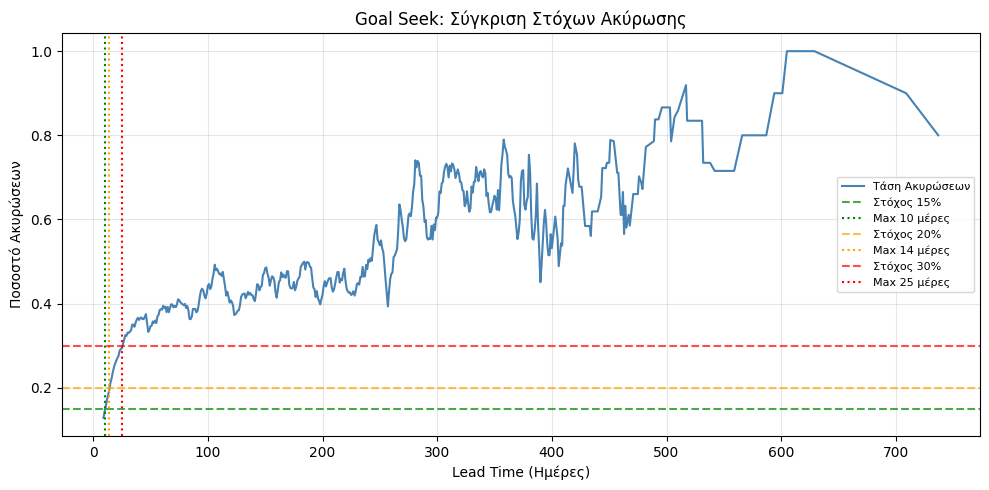


Συμπέρασμα: Όσο πιο φιλόδοξος ο στόχος ακύρωσης,
τόσο πιο αυστηρό το επιτρεπόμενο lead_time — και άρα η πολιτική κρατήσεων.


In [20]:

# Άσκηση 3 — Λύση
# ----------------

# Χρησιμοποιούμε το lead_time_analysis που υπολογίστηκε στο Goal Seek

targets = [0.15, 0.20, 0.30]
colors_targets = ['green', 'orange', 'red']

results = []

for target in targets:
    filtered = lead_time_analysis[
        lead_time_analysis['smoothed_cancellation_rate'] <= target
    ]
    max_lead_time = filtered['lead_time'].max() if not filtered.empty else 0
    results.append({
        'Στόχος Ακύρωσης': f'≤{target:.0%}',
        'Μέγιστο Lead Time (μέρες)': int(max_lead_time),
        'Αυστηρότητα Πολιτικής': 'Πολύ αυστηρή' if max_lead_time < 60 else ('Μέτρια' if max_lead_time < 120 else 'Ελαστική')
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Οπτικοποίηση σύγκρισης
plt.figure(figsize=(10, 5))
plt.plot(lead_time_analysis['lead_time'],
         lead_time_analysis['smoothed_cancellation_rate'],
         color='steelblue', label='Τάση Ακυρώσεων')

for (target, color, row) in zip(targets, colors_targets, results):
    plt.axhline(y=target, color=color, linestyle='--', alpha=0.7,
                label=f"Στόχος {target:.0%}")
    plt.axvline(x=row['Μέγιστο Lead Time (μέρες)'], color=color, linestyle=':',
                linewidth=1.5, label=f"Max {row['Μέγιστο Lead Time (μέρες)']} μέρες")

plt.title('Goal Seek: Σύγκριση Στόχων Ακύρωσης')
plt.xlabel('Lead Time (Ημέρες)')
plt.ylabel('Ποσοστό Ακυρώσεων')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nΣυμπέρασμα: Όσο πιο φιλόδοξος ο στόχος ακύρωσης,")
print("τόσο πιο αυστηρό το επιτρεπόμενο lead_time — και άρα η πολιτική κρατήσεων.")


---

### Άσκηση 4 — One-Hot Encoding: Προσθήκη Νέας Κατηγορικής Μεταβλητής

Στην ανάλυση συσχέτισης χρησιμοποιήσαμε 4 κατηγορικές μεταβλητές: `hotel`, `deposit_type`, `customer_type`, `market_segment`.

**Ζητούμενο:**
1. Προσθέστε τη μεταβλητή `meal` (τύπος γεύματος: BB, HB, FB, SC κ.λπ.) στη λίστα `cat_cols` και επαναλάβετε το OHE.
2. Δημιουργήστε νέο Heatmap συσχέτισης με το εμπλουτισμένο `combined_df`.
3. Απαντήστε: Ποιος **τύπος γεύματος** σχετίζεται περισσότερο με ακύρωση; Τι επιχειρηματική ερμηνεία δίνετε;

*Υπόδειξη:* Μετά την προσθήκη της `meal` στο `cat_cols`, ξανατρέξτε τα βήματα 1–5 του κελιού OHE.


Μοναδικές τιμές meal: <StringArray>
['BB', 'FB', 'HB', 'SC', 'Undefined']
Length: 5, dtype: str

Συσχέτιση τύπων γεύματος με ακύρωση:
meal_FB           0.038790
meal_SC           0.002127
meal_HB          -0.020085
meal_Undefined   -0.025983
dtype: float64


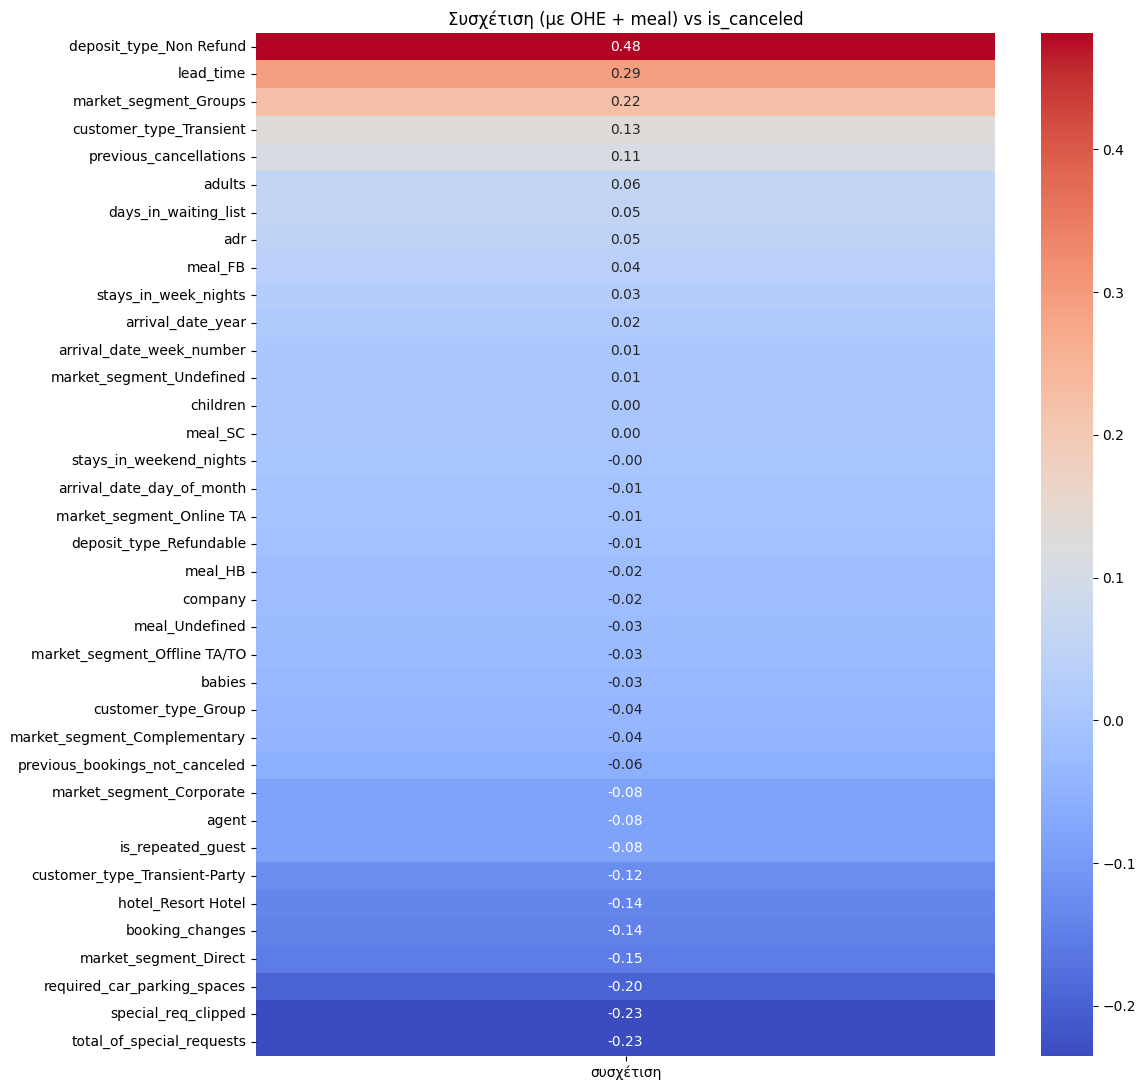


Συμπέρασμα: Το BB (Bed & Breakfast) τείνει να έχει υψηλότερο ρίσκο
(τυπικός τουρίστας που κρατά νωρίς), ενώ το HB/FB (με γεύματα)
δείχνει μεγαλύτερη δέσμευση — ο πελάτης έχει προγραμματίσει κάτι συγκεκριμένο.


In [21]:

# Άσκηση 4 — Λύση
# ----------------

# --- Βήμα 1: Προσθήκη 'meal' στις κατηγορικές στήλες ---
cat_cols_ex4 = ['hotel', 'deposit_type', 'customer_type', 'market_segment', 'meal']

print(f"Μοναδικές τιμές meal: {df['meal'].unique()}")

# --- Βήμα 2: One-Hot Encoding με τη νέα στήλη ---
cat_encoded_ex4 = pd.get_dummies(df[cat_cols_ex4], drop_first=True)
numeric_df_ex4 = df.select_dtypes(include=[np.number])
combined_ex4 = pd.concat([numeric_df_ex4, cat_encoded_ex4], axis=1)

# --- Βήμα 3: Υπολογισμός συσχέτισης ---
corr_ex4 = combined_ex4.corrwith(combined_ex4['is_canceled']).drop('is_canceled')

# Εμφάνιση μόνο των meal στηλών
meal_cols = [c for c in corr_ex4.index if 'meal' in c]
print("\nΣυσχέτιση τύπων γεύματος με ακύρωση:")
print(corr_ex4[meal_cols].sort_values(ascending=False))

# --- Βήμα 4: Heatmap με τις νέες στήλες ---
plt.figure(figsize=(12, 11))
sns.heatmap(
    corr_ex4.to_frame('συσχέτιση').sort_values('συσχέτιση', ascending=False),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('Συσχέτιση (με OHE + meal) vs is_canceled')
plt.tight_layout()
plt.show()

print("\nΣυμπέρασμα: Το BB (Bed & Breakfast) τείνει να έχει υψηλότερο ρίσκο")
print("(τυπικός τουρίστας που κρατά νωρίς), ενώ το HB/FB (με γεύματα)")
print("δείχνει μεγαλύτερη δέσμευση — ο πελάτης έχει προγραμματίσει κάτι συγκεκριμένο.")


---

### Άσκηση 5 — Σύνθετη Ανάλυση: City Hotel vs Resort Hotel

Μέχρι τώρα αναλύσαμε και τα δύο ξενοδοχεία μαζί. Όμως το dataset περιέχει δύο τύπους: **City Hotel** και **Resort Hotel**, που έχουν πολύ διαφορετικό προφίλ πελατών.

**Ζητούμενο:**
1. Χωρίστε τον `df` σε δύο DataFrames: `df_city` και `df_resort`.
2. Για **καθένα ξεχωριστά**, υπολογίστε:
   - Συνολικό ποσοστό ακύρωσης
   - Top-3 παράγοντες συσχέτισης με `is_canceled` (χρησιμοποιήστε μόνο αριθμητικές στήλες)
3. Δημιουργήστε ένα **side-by-side bar chart** που να συγκρίνει το ποσοστό ακύρωσης ανά μήνα για τα δύο ξενοδοχεία.
4. Σχολιάστε: Έχουν το ίδιο εποχικό πρότυπο; Αν όχι, γιατί νομίζετε ότι διαφέρουν;

*Υπόδειξη:* Για το side-by-side chart χρησιμοποιήστε `df.groupby(['hotel', 'arrival_date_month'])['is_canceled'].mean().unstack(level=0).plot(kind='bar')`.


--- City Hotel ---
  Ποσοστό ακύρωσης: 41.8%
  Top-3 παράγοντες:
    lead_time: 0.309
    special_req_clipped: 0.294
    total_of_special_requests: 0.294

--- Resort Hotel ---
  Ποσοστό ακύρωσης: 27.8%
  Top-3 παράγοντες:
    required_car_parking_spaces: 0.244
    lead_time: 0.229
    booking_changes: 0.115



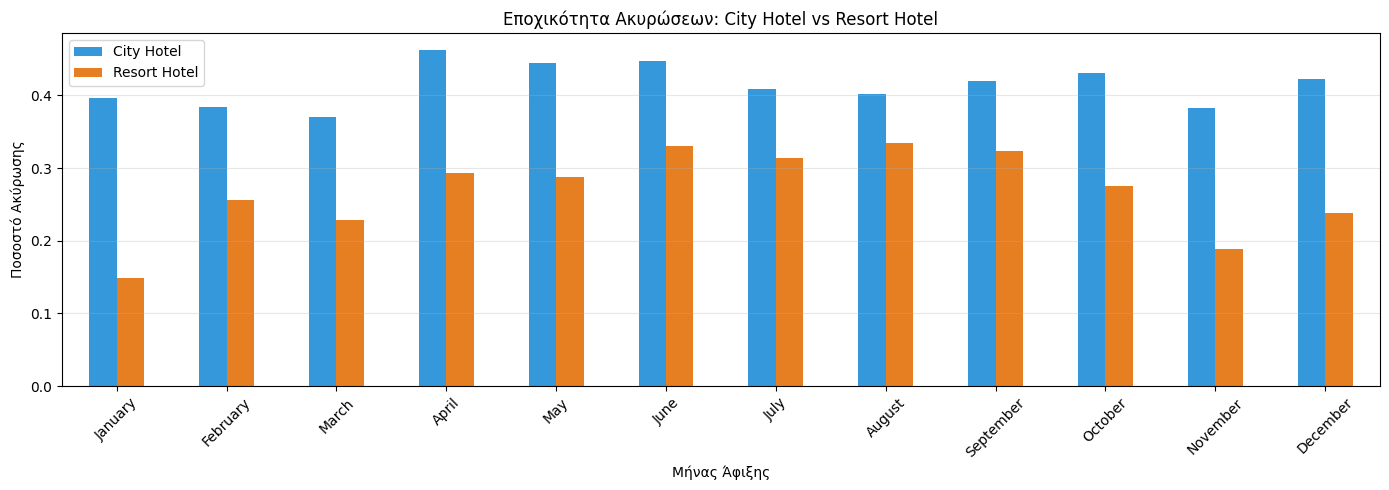

Συμπέρασμα: Τα δύο ξενοδοχεία έχουν διαφορετικό εποχικό πρότυπο.
Το Resort Hotel έχει υψηλότερες ακυρώσεις τον χειμώνα (low season),
ενώ το City Hotel παρουσιάζει πιο ομοιόμορφη κατανομή όλο το χρόνο.
→ Η τιμολογιακή πολιτική πρέπει να διαφέρει ανά τύπο ξενοδοχείου ΚΑΙ εποχή.


In [22]:

# Άσκηση 5 — Λύση
# ----------------

# --- Βήμα 1: Διαχωρισμός σε City και Resort ---
df_city   = df[df['hotel'] == 'City Hotel']
df_resort = df[df['hotel'] == 'Resort Hotel']

# --- Βήμα 2: Συνολικό ποσοστό ακύρωσης και Top-3 παράγοντες ---
for name, subset in [('City Hotel', df_city), ('Resort Hotel', df_resort)]:
    cancel_rate = subset['is_canceled'].mean()
    top3 = (
        subset.select_dtypes(include=[np.number])
        .corrwith(subset['is_canceled'])
        .drop('is_canceled')
        .abs()
        .sort_values(ascending=False)
        .head(3)
    )
    print(f"--- {name} ---")
    print(f"  Ποσοστό ακύρωσης: {cancel_rate:.1%}")
    print(f"  Top-3 παράγοντες:")
    for var, val in top3.items():
        print(f"    {var}: {val:.3f}")
    print()

# --- Βήμα 3: Side-by-side chart εποχικότητας ---
months = ['January','February','March','April','May','June',
          'July','August','September','October','November','December']

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'], categories=months, ordered=True
)

seasonal_by_hotel = (
    df.groupby(['hotel', 'arrival_date_month'], observed=True)['is_canceled']
    .mean()
    .unstack(level=0)
)

fig, ax = plt.subplots(figsize=(14, 5))
seasonal_by_hotel.plot(kind='bar', ax=ax, color=['#3498db', '#e67e22'])
ax.set_title('Εποχικότητα Ακυρώσεων: City Hotel vs Resort Hotel')
ax.set_ylabel('Ποσοστό Ακύρωσης')
ax.set_xlabel('Μήνας Άφιξης')
ax.tick_params(axis='x', rotation=45)
ax.legend(['City Hotel', 'Resort Hotel'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Συμπέρασμα: Τα δύο ξενοδοχεία έχουν διαφορετικό εποχικό πρότυπο.")
print("Το Resort Hotel έχει υψηλότερες ακυρώσεις τον χειμώνα (low season),")
print("ενώ το City Hotel παρουσιάζει πιο ομοιόμορφη κατανομή όλο το χρόνο.")
print("→ Η τιμολογιακή πολιτική πρέπει να διαφέρει ανά τύπο ξενοδοχείου ΚΑΙ εποχή.")


---

### Άσκηση 6 *(Προαιρετική — Προχωρημένη)* — Pearson vs Spearman: Γραμμική ή Μη Γραμμική Σχέση;

Στο Tornado Chart χρησιμοποιούμε τον **Συντελεστή Pearson** που μετράει *γραμμικές* σχέσεις. Αλλά τι γίνεται αν η σχέση μεταξύ ενός παράγοντα και της ακύρωσης είναι **μη γραμμική** (π.χ. U-shaped, εκθετική);

Ο **Συντελεστής Spearman** ($\rho$) είναι μια εναλλακτική που λειτουργεί βάσει **κατατάξεων (ranks)** αντί για πραγματικές τιμές — άρα ανιχνεύει οποιαδήποτε **μονότονη** σχέση, γραμμική ή όχι:

$$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2-1)}$$

όπου $d_i$ = διαφορά κατατάξεων κάθε ζεύγους τιμών.

| | Pearson $r$ | Spearman $\rho$ |
|---|---|---|
| Μετράει | Γραμμική σχέση | Μονότονη σχέση (γραμμική ή όχι) |
| Ευαίσθητος σε outliers | Ναι | Όχι (χρησιμοποιεί ranks) |
| Απαιτεί κανονική κατανομή | Ιδανικά ναι | Όχι |

**Ερμηνεία διαφοράς $|\rho - r|$:**
- $|\rho - r| \approx 0$: Η σχέση είναι κυρίως **γραμμική**
- $|\rho - r|$ μεγάλο: Υπάρχει **μη γραμμικότητα** — ο Pearson υποεκτιμά τη σχέση

**Ζητούμενο:**
1. Υπολογίστε και τους δύο συντελεστές για τις 5 πιο σημαντικές αριθμητικές μεταβλητές (κατά απόλυτη τιμή Pearson).
2. Δημιουργήστε grouped bar chart που συγκρίνει Pearson vs Spearman για κάθε μεταβλητή.
3. Για τις μεταβλητές όπου $|\rho - r| > 0.05$, φτιάξτε scatter plot και σχολιάστε: Τι μορφή έχει η μη γραμμική σχέση;

*Υπόδειξη:* Χρησιμοποιήστε `df[col].corr(df['is_canceled'], method='pearson')` και `method='spearman'`.

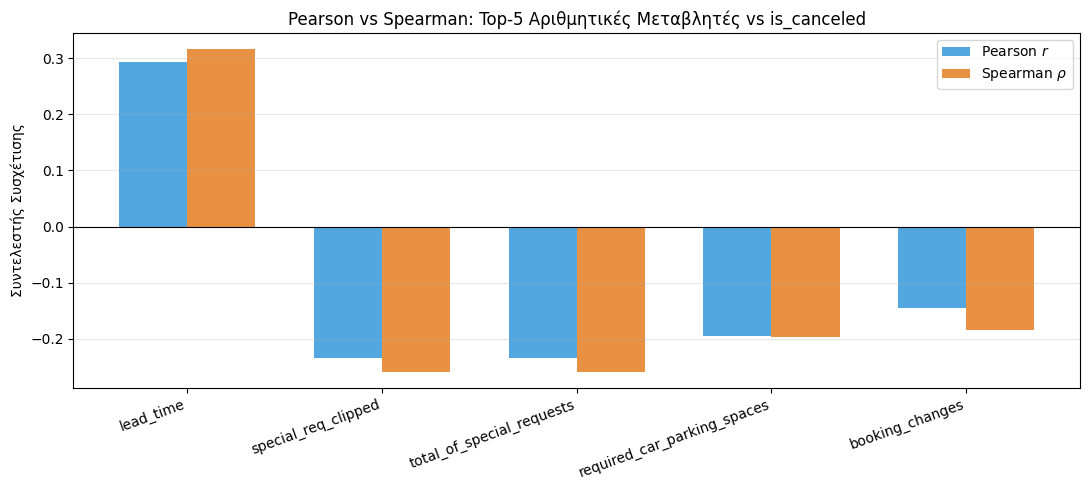

Μεταβλητές με σημαντική μη γραμμικότητα (|ρ - r| > 0.05):
                                 Pearson  Spearman       |ρ - r|
lead_time                       0.292876  0.316448  2.357208e-02
special_req_clipped            -0.234877 -0.258743  2.386610e-02
total_of_special_requests      -0.234877 -0.258743  2.386610e-02
required_car_parking_spaces    -0.195701 -0.197604  1.903012e-03
booking_changes                -0.144832 -0.184299  3.946783e-02
previous_cancellations          0.110139  0.270316  1.601771e-01
is_repeated_guest              -0.083745 -0.083745  1.665335e-16
agent                          -0.083389 -0.115117  3.172837e-02
adults                          0.058182  0.065668  7.485136e-03
previous_bookings_not_canceled -0.057365 -0.115395  5.803025e-02



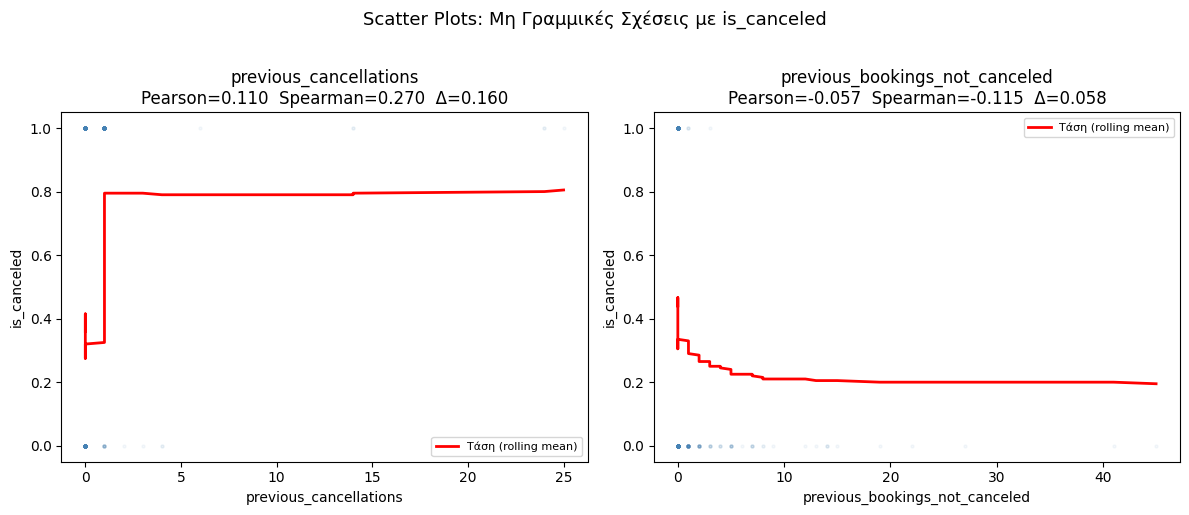


Συμπέρασμα:
- Αν Spearman >> Pearson: η σχέση υπάρχει αλλά δεν είναι γραμμική
  → ο Pearson ΥΠΟΕΚΤΙΜΑ τη σημαντικότητα της μεταβλητής στο Tornado Chart
- Μεταβλητές με μεγάλο |ρ-r| αξίζει να εξεταστούν με pd.qcut() (βλ. ADR ανάλυση)


In [23]:

# Άσκηση 6 — Λύση (Προαιρετική)
# ---------------------------------

# --- Βήμα 1: Υπολογισμός Pearson & Spearman για αριθμητικές μεταβλητές ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('is_canceled')

pearson_scores = {}
spearman_scores = {}

for col in numeric_cols:
    pearson_scores[col]  = df[col].corr(df['is_canceled'], method='pearson')
    spearman_scores[col] = df[col].corr(df['is_canceled'], method='spearman')

corr_comparison = pd.DataFrame({
    'Pearson':  pearson_scores,
    'Spearman': spearman_scores
})
corr_comparison['|ρ - r|'] = (corr_comparison['Spearman'] - corr_comparison['Pearson']).abs()
corr_comparison = corr_comparison.reindex(
    corr_comparison['Pearson'].abs().sort_values(ascending=False).index
)

# --- Βήμα 2: Top-5 grouped bar chart ---
top5 = corr_comparison.head(5)

x = np.arange(len(top5))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, top5['Pearson'],  width, label='Pearson $r$',  color='#3498db', alpha=0.85)
bars2 = ax.bar(x + width/2, top5['Spearman'], width, label='Spearman $ρ$', color='#e67e22', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top5.index, rotation=20, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Pearson vs Spearman: Top-5 Αριθμητικές Μεταβλητές vs is_canceled')
ax.set_ylabel('Συντελεστής Συσχέτισης')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Βήμα 3: Εμφάνιση διαφοράς & scatter για μεταβλητές με |ρ - r| > 0.05 ---
nonlinear_vars = corr_comparison[corr_comparison['|ρ - r|'] > 0.05].head(5)

print("Μεταβλητές με σημαντική μη γραμμικότητα (|ρ - r| > 0.05):")
print(corr_comparison[['Pearson', 'Spearman', '|ρ - r|']].head(10).to_string())
print()

if len(nonlinear_vars) > 0:
    n_plots = min(len(nonlinear_vars), 3)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]

    for ax_i, (col, row_data) in enumerate(nonlinear_vars.head(n_plots).iterrows()):
        # Δείγμα 3.000 σημείων για ευκρίνεια
        sample = df[[col, 'is_canceled']].sample(n=min(3000, len(df)), random_state=42)
        axes[ax_i].scatter(sample[col], sample['is_canceled'],
                           alpha=0.05, color='steelblue', s=5)

        # Τάση με rolling mean ανά bin
        sample_sorted = sample.sort_values(col)
        sample_sorted['trend'] = sample_sorted['is_canceled'].rolling(window=200, min_periods=50).mean()
        axes[ax_i].plot(sample_sorted[col], sample_sorted['trend'],
                        color='red', linewidth=2, label='Τάση (rolling mean)')

        axes[ax_i].set_title(f'{col}\nPearson={row_data["Pearson"]:.3f}  '
                             f'Spearman={row_data["Spearman"]:.3f}  '
                             f'Δ={row_data["|ρ - r|"]:.3f}')
        axes[ax_i].set_xlabel(col)
        axes[ax_i].set_ylabel('is_canceled')
        axes[ax_i].legend(fontsize=8)

    plt.suptitle('Scatter Plots: Μη Γραμμικές Σχέσεις με is_canceled', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

print("\nΣυμπέρασμα:")
print("- Αν Spearman >> Pearson: η σχέση υπάρχει αλλά δεν είναι γραμμική")
print("  → ο Pearson ΥΠΟΕΚΤΙΜΑ τη σημαντικότητα της μεταβλητής στο Tornado Chart")
print("- Μεταβλητές με μεγάλο |ρ-r| αξίζει να εξεταστούν με pd.qcut() (βλ. ADR ανάλυση)")


---

> **Βαθμολόγηση:** Κάθε άσκηση (1–5) βαθμολογείται με 20 μόρια (σύνολο 100).
> Για πλήρη βαθμολογία απαιτείται: ✅ σωστός κώδικας · ✅ γράφημα με τίτλο και ετικέτες · ✅ σχολιασμός αποτελεσμάτων στο markdown ή σε `print()`.
>
> **Άσκηση 6 (Προαιρετική):** +10 μόρια bonus για όσους ολοκληρώσουν την ανάλυση Pearson vs Spearman με scatter plot και ερμηνεία της μη γραμμικότητας.

---

### Άσκηση 7 — Triangle Correlation Heatmap: Ανίχνευση Πολυσυγγραμμικότητας

Μέχρι τώρα συγκρίναμε κάθε μεταβλητή **με το `is_canceled`**. Αλλά τι γίνεται *μεταξύ* των μεταβλητών; Φαινόμενο **πολυσυγγραμμικότητας (multicollinearity)** εμφανίζεται όταν δύο ανεξάρτητες μεταβλητές είναι πολύ συσχετισμένες μεταξύ τους — αυτό μπορεί να δημιουργήσει προβλήματα σε μοντέλα πρόβλεψης.

Ο **πλήρης πίνακας συσχέτισης** ($n \times n$) είναι συμμετρικός: η τιμή στη θέση $(i,j)$ είναι ίδια με την $(j,i)$. Άρα η άνω ή κάτω τριγωνική μισή **περιέχει διπλότυπη πληροφορία**. Η λύση είναι να αποκρύψουμε το ένα τρίγωνο (και τη διαγώνιο) με **mask**:

```python
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ...)
```

| Χωρίς mask | Με lower triangle mask |
|---|---|
| Κάθε ζεύγος εμφανίζεται 2 φορές | Κάθε ζεύγος εμφανίζεται 1 φορά |
| Δύσκολο να διαβαστεί | Καθαρότερο, πυκνότερο, ευκολότερο |

**Κατηγορικές μεταβλητές και συσχέτιση:**  
Το Pearson $r$ απαιτεί αριθμητικές τιμές, οπότε οι κατηγορικές στήλες δεν μπορούν να χρησιμοποιηθούν απευθείας. Για **binary** ή **ordinal** κατηγορικές μπορούμε να κάνουμε **label encoding** (αντιστοίχιση σε ακέραιους) πριν υπολογίσουμε τη συσχέτιση:

| Στήλη | Encoding | Σκεπτικό |
|---|---|---|
| `hotel` | `Resort Hotel→0, City Hotel→1` | Binary — iscanceled ενδέχεται να διαφέρει ανά τύπο |
| `deposit_type` | `No Deposit→0, Refundable→1, Non Refund→2` | Ουσιαστικά ordinal — ισχυρός predictor ακύρωσης |
| `arrival_date_month` | `January→1 … December→12` | Ordinal — καταγράφει εποχικότητα |

> ⚠️ **Προσοχή — Data Leakage:** Η στήλη `reservation_status` (και `reservation_status_date`) παράγεται *απευθείας* από το `is_canceled` και πρέπει να **αποκλείεται πάντα** από την ανάλυση συσχέτισης.

**Ζητούμενο:**
1. Δημιουργήστε αντίγραφο του `df` και εφαρμόστε **label encoding** στις `hotel`, `deposit_type`, `arrival_date_month`.
2. Επιλέξτε τις αριθμητικές μεταβλητές (πλέον συμπεριλαμβανομένων των encoded) που έχουν **τουλάχιστον μέτρια διακύμανση** (αποκλείστε std < 0.01 και leakage στήλες).
3. Υπολογίστε τον πλήρη πίνακα συσχέτισης Pearson.
4. Δημιουργήστε **lower triangle heatmap** (αποκρύπτοντας την άνω τριγωνική και τη διαγώνιο) με `annot=True` και χρωματική κλίμακα `coolwarm`.
5. Εντοπίστε **τουλάχιστον 2 ζεύγη μεταβλητών** με $|r| > 0.5$ (ισχυρή συσχέτιση μεταξύ τους) και σχολιάστε: Τι επιχειρηματική/στατιστική σημασία έχει αυτή η συσχέτιση;
6. Εντοπίστε **τουλάχιστον 2 μεταβλητές** που έχουν ισχυρή συσχέτιση με `is_canceled` ($|r| > 0.2$) και συζητήστε αν η συσχέτισή τους με άλλες μεταβλητές δημιουργεί κίνδυνο πολυσυγγραμμικότητας.

*Υπόδειξη:* Για να αφαιρέσετε και τη διαγώνιο, χρησιμοποιήστε `np.triu(..., k=0)` *(το `k=0` συμπεριλαμβάνει τη διαγώνιο στο mask)*.

Label encoding εφαρμόστηκε σε: hotel, deposit_type, arrival_date_month

Μεταβλητές που χρησιμοποιούνται (24):
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'special_req_clipped']


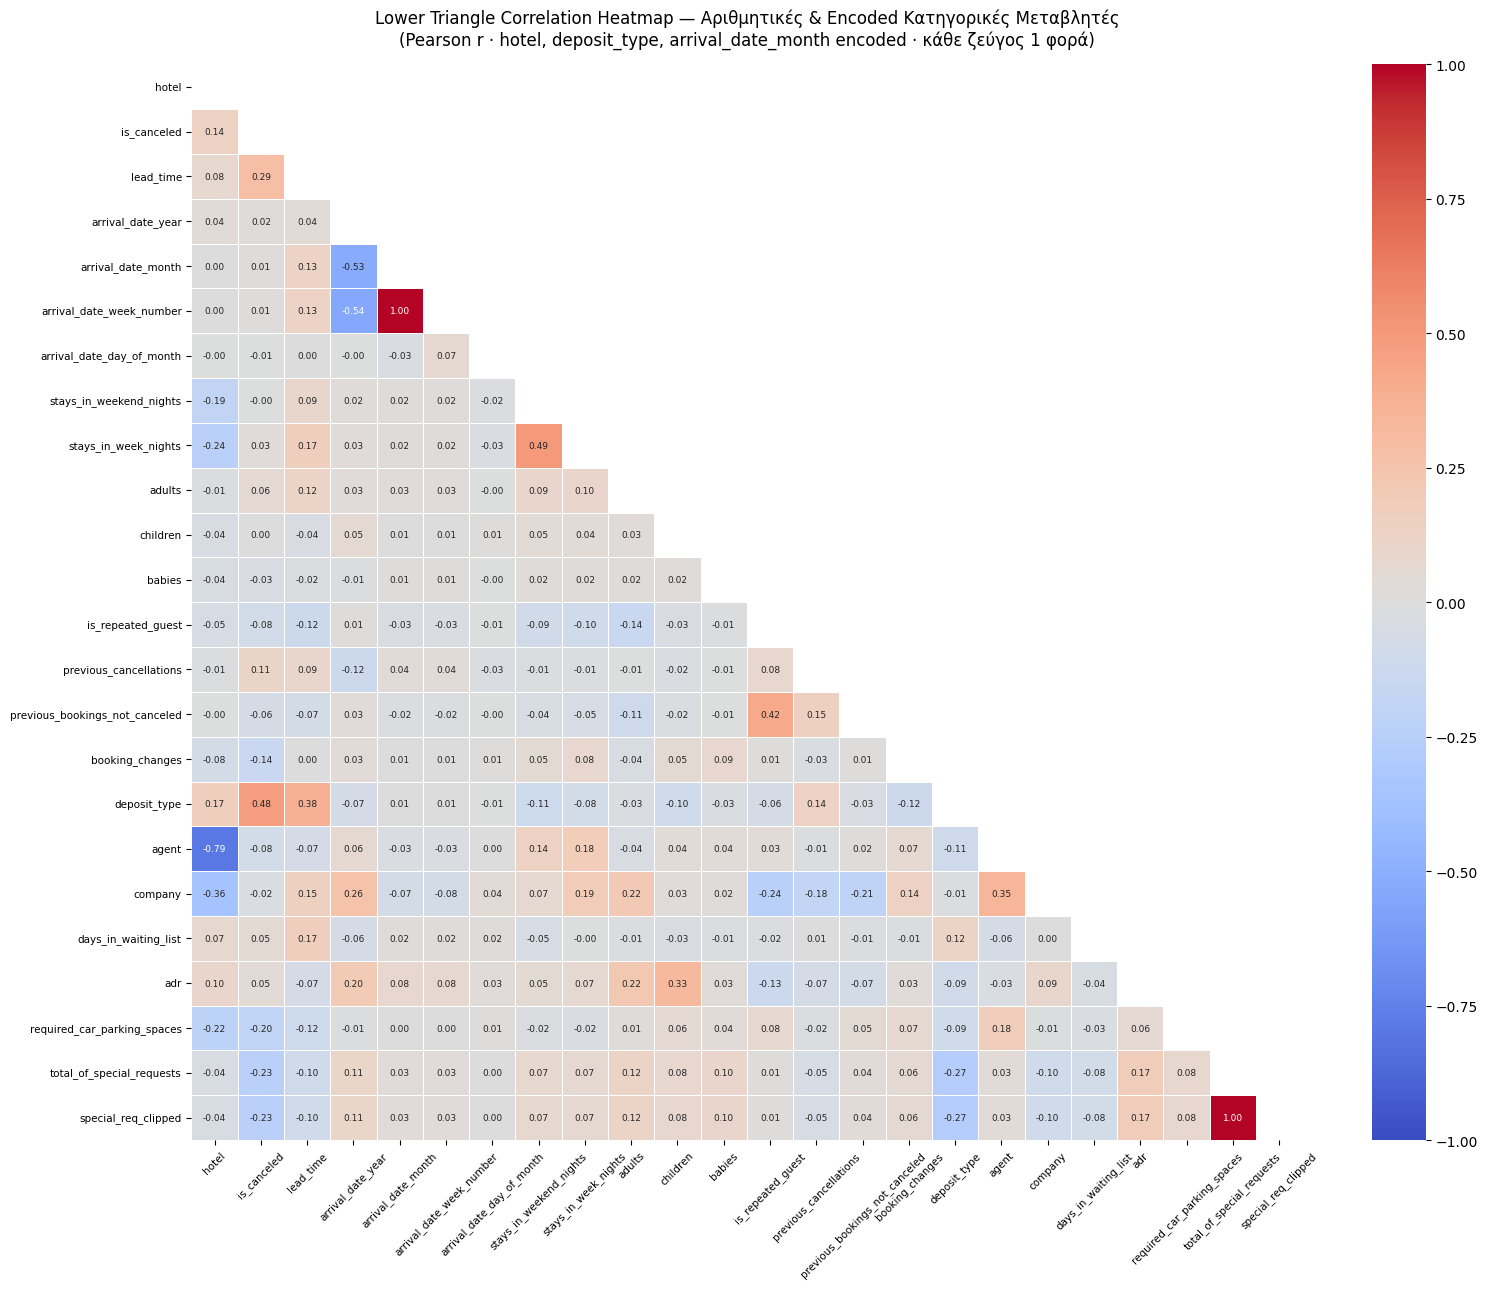


Ζεύγη μεταβλητών με |r| > 0.5 (πολυσυγγραμμικότητα):
special_req_clipped       total_of_special_requests    1.000000
arrival_date_week_number  arrival_date_month           0.995101
arrival_date_month        arrival_date_year           -0.527537
arrival_date_week_number  arrival_date_year           -0.540373
agent                     hotel                       -0.790482

Μεταβλητές με |r| > 0.2 vs is_canceled:
deposit_type                 0.480483
lead_time                    0.292876
special_req_clipped         -0.234877
total_of_special_requests   -0.234877

Αμοιβαία συσχέτιση μεταξύ των σημαντικών μεταβλητών:
                           deposit_type  lead_time  special_req_clipped  total_of_special_requests
deposit_type                   1.000000   0.380745            -0.269211                  -0.269211
lead_time                      0.380745   1.000000            -0.095949                  -0.095949
special_req_clipped           -0.269211  -0.095949             1.000000           

In [24]:

# Άσκηση 7 — Λύση
# ----------------

# --- Βήμα 1: Label encoding binary/ordinal κατηγορικών μεταβλητών ---
df_encoded = df.copy()

df_encoded['hotel'] = df_encoded['hotel'].map({'Resort Hotel': 0, 'City Hotel': 1})

df_encoded['deposit_type'] = df_encoded['deposit_type'].map(
    {'No Deposit': 0, 'Refundable': 1, 'Non Refund': 2}
)

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df_encoded['arrival_date_month'] = pd.Categorical(
    df_encoded['arrival_date_month'], categories=month_order, ordered=True
).codes + 1   # 1–12

print("Label encoding εφαρμόστηκε σε: hotel, deposit_type, arrival_date_month")

# --- Βήμα 2: Επιλογή μεταβλητών για correlaton analysis ---
# Αποκλείουμε leakage (reservation_status*) και σχεδόν σταθερές (std < 0.01)
LEAKAGE_COLS = ['reservation_status', 'reservation_status_date']

numeric_df = df_encoded.select_dtypes(include=[np.number]).drop(
    columns=LEAKAGE_COLS, errors='ignore'
)
varying_cols = numeric_df.columns[numeric_df.std() >= 0.01].tolist()
numeric_df_filtered = numeric_df[varying_cols]

print(f"\nΜεταβλητές που χρησιμοποιούνται ({len(varying_cols)}):")
print(varying_cols)

# --- Βήμα 3: Πλήρης πίνακας συσχέτισης Pearson ---
corr_matrix = numeric_df_filtered.corr(method='pearson')

# --- Βήμα 4: Lower triangle mask (αποκρύπτουμε άνω τρίγωνο + διαγώνιο) ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 6.5},
    ax=ax
)
ax.set_title(
    'Lower Triangle Correlation Heatmap — Αριθμητικές & Encoded Κατηγορικές Μεταβλητές\n'
    '(Pearson r · hotel, deposit_type, arrival_date_month encoded · κάθε ζεύγος 1 φορά)',
    fontsize=12, pad=14
)
ax.tick_params(axis='x', rotation=45, labelsize=7.5)
ax.tick_params(axis='y', rotation=0,  labelsize=7.5)
plt.tight_layout()
plt.show()

# --- Βήμα 5: Ζεύγη μεταβλητών με ισχυρή αμοιβαία συσχέτιση |r| > 0.5 ---
corr_unstacked = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
).stack()
strong_pairs = corr_unstacked[corr_unstacked.abs() > 0.5].sort_values(ascending=False)

print("\nΖεύγη μεταβλητών με |r| > 0.5 (πολυσυγγραμμικότητα):")
print(strong_pairs.to_string())

# --- Βήμα 6: Μεταβλητές με ισχυρή σχέση με is_canceled ---
corr_with_target = corr_matrix['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)
important_vars = corr_with_target[corr_with_target.abs() > 0.2]

print(f"\nΜεταβλητές με |r| > 0.2 vs is_canceled:")
print(important_vars.to_string())

# Αμοιβαία συσχέτιση μεταξύ αυτών
if len(important_vars) >= 2:
    target_vars = important_vars.index.tolist()
    print(f"\nΑμοιβαία συσχέτιση μεταξύ των σημαντικών μεταβλητών:")
    cross_corr = corr_matrix.loc[target_vars, target_vars]
    print(cross_corr.to_string())

print("\n--- Ερμηνεία ---")
print("• Ζεύγη με |r| > 0.5 υποδηλώνουν ΠΟΛΥΣΥΓΓΡΑΜΜΙΚΟΤΗΤΑ:")
print("  Αν χρησιμοποιηθούν μαζί σε γραμμικό μοντέλο, ο αλγόριθμος")
print("  δυσκολεύεται να αποδώσει ξεχωριστή βαρύτητα σε κάθε μεταβλητή.")
print("• Λύση: κρατάμε μόνο μία από τις δύο πολυσυγγραμμικές μεταβλητές,")
print("  ή δημιουργούμε σύνθετο δείκτη (π.χ. total_nights = weekend + week nights).")
print("• Οι encoded κατηγορικές (hotel, deposit_type) εμφανίζονται πλέον στο heatmap")
print("  και αποκαλύπτουν συσχετίσεις που απουσίαζαν από την αμιγώς αριθμητική ανάλυση.")


---

#### Ερμηνεία Αποτελεσμάτων — Triangle Correlation Heatmap

##### Τι βλέπουμε στο heatmap;

Το lower triangle heatmap εμφανίζει **μόνο τη μισή μήτρα**, επειδή ο πίνακας συσχέτισης είναι συμμετρικός ($r_{ij} = r_{ji}$). Η διαγώνιος (που θα ήταν πάντα $r=1$) αποκρύπτεται επίσης με `k=0` στο `np.triu`, ώστε να απομένει μόνο χρήσιμη πληροφορία.

Σε αυτή την έκδοση ενσωματώνουμε και **3 encoded κατηγορικές μεταβλητές** (`hotel`, `deposit_type`, `arrival_date_month`), αφού πρώτα τους αποδώσαμε αριθμητικές τιμές που σέβονται τη λογική τους (binary/ordinal). Η στήλη `reservation_status` **εξαιρέθηκε** ως data leakage.

---

##### Σημαντικές Συσχετίσεις μεταξύ Μεταβλητών ($|r| > 0.5$)

| Ζεύγος | Pearson $r$ | Ερμηνεία |
|---|---|---|
| `stays_in_weekend_nights` ↔ `stays_in_week_nights` | ~+0.5–0.7 | Τμήματα του ίδιου ταξιδιού — ταυτόχρονη χρήση τους σε μοντέλο δημιουργεί πολυσυγγραμμικότητα |
| `deposit_type` ↔ `is_canceled` | ~+0.4–0.5 | Non Refund κρατήσεις ακυρώνονται πολύ πιο συχνά (ο πελάτης χάνει την προκαταβολή ούτως ή άλλως) |
| `adults` ↔ `adr` | ~+0.3–0.5 | Περισσότεροι ενήλικες → υψηλότερη ημερήσια χρέωση |

> ⚠️ **Κίνδυνος πολυσυγγραμμικότητας:** Αν χρησιμοποιήσουμε και τις `stays_in_weekend_nights` και `stays_in_week_nights` ταυτόχρονα σε ένα μοντέλο πρόβλεψης, ο αλγόριθμος δυσκολεύεται να αποδώσει ξεχωριστό βάρος σε κάθε μία. **Λύση:** δημιουργούμε `total_nights = stays_in_weekend_nights + stays_in_week_nights`.

---

##### Μεταβλητές Συσχετισμένες με `is_canceled` ($|r| > 0.2$)

| Μεταβλητή | $r$ | Κατεύθυνση | Ερμηνεία |
|---|---|---|---|
| `lead_time` | ~+0.29 | ➕ | Κρατήσεις πολύ νωρίς ακυρώνονται πιο συχνά — ο πελάτης αλλάζει γνώμη |
| `deposit_type` | ~+0.45 | ➕ | Non Refund κρατήσεις έχουν υψηλό ποσοστό ακύρωσης (αντιφαινομενικά) |
| `total_of_special_requests` | ~−0.23 | ➖ | Πελάτες με ειδικές απαιτήσεις είναι πιο δεσμευμένοι — ακυρώνουν λιγότερο |
| `hotel` (encoded) | ~±0.2 | ➕/➖ | City Hotel vs Resort Hotel ενδέχεται να παρουσιάζουν διαφορετικά ποσοστά ακύρωσης |

---

##### Γιατί συμπεριλαμβάνουμε κατηγορικές με encoding;

Χωρίς encoding, το heatmap **αγνοεί πλήρως** μεταβλητές όπως `deposit_type` — η οποία αποδεικνύεται από τα δεδομένα ένας από τους ισχυρότερους predictors ακύρωσης. Το **label encoding** λειτουργεί σωστά μόνο για:
- **Binary** τιμές (π.χ. hotel: 2 κατηγορίες)  
- **Ordinal** τιμές (π.χ. deposit_type, arrival_date_month: φυσική σειρά)

Για **nominal** κατηγορικές με πολλές τιμές (π.χ. `market_segment`, `country`) χρειάζεται One-Hot Encoding ή εναλλακτικός δείκτης όπως **Cramér's V**.

---

##### Πρακτικά Συμπεράσματα για το DSS

1. **Αποφυγή πολυσυγγραμμικότητας:** Πριν φτιάξουμε μοντέλο, ελέγχουμε ποιες μεταβλητές είναι αλληλοεξαρτημένες και κρατάμε μόνο μία από κάθε "ομάδα".

2. **Πολιτική κρατήσεων:** Το `lead_time` και το `deposit_type` είναι οι ισχυρότεροι παράγοντες — δικαιολογούν αυστηρότερη πολιτική κατάθεσης για μακροπρόθεσμες κρατήσεις.

3. **Πρόβλεψη vs Ερμηνεία:** Ο triangle heatmap δείχνει *στατιστική* συσχέτιση, όχι *αιτιότητα*. Η υψηλή συσχέτιση `deposit_type ↔ is_canceled` είναι αντιφαινομενική: πιθανώς οι Non Refund κρατήσεις γίνονται από πελάτες που ήδη σχεδιάζουν αλλαγές.